In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import h5py
from collections import Counter
import scipy.sparse as sp
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patheffects as path_effects
import yaml
import time
from itertools import combinations
import gget
from scipy.stats import zscore
import matplotlib.patches as patches

from pycirclize import Circos
from pycirclize.parser import Matrix
from pycirclize.utils import ColorCycler

from matplotlib_venn import venn3_unweighted
from matplotlib_venn import venn2_unweighted
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
import matplotlib.ticker as mtick

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc

# import scvi
# from scvi.external import SysVI

import cupy as cp
import cudf
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator

from cuml.manifold.umap import simplicial_set_embedding
from scanpy.tools._utils import get_init_pos_from_paga 
from cuml.manifold.umap import find_ab_params

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 2

In [2]:
import plotly.io as pio
pio.renderers.default = 'notebook'

# Load in data

In [2]:
%%time 
# === Load and filter GTF ===
gpath = "/scratch/indikar_root/indikar1/shared_data/HYB/resources/refdata-gex-GRCh38-2024-A_genes.csv.gz"

gtf = pd.read_csv(gpath)

exons = gtf[gtf['Feature'] == 'exon']
print(f"{exons.shape=}")
exons.head()

exons.shape=(1586950, 27)
CPU times: user 7.75 s, sys: 1.28 s, total: 9.03 s
Wall time: 9.14 s


,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_version,...,transcript_name,transcript_support_level,havana_transcript,exon_number,exon_id,exon_version,hgnc_id,havana_gene,protein_id,ccdsid
2,GL000009.2,ENSEMBL,exon,56139,58376,.,-,.,ENSG00000278704,1,...,ENST00000618686,NaN,NaN,1.0,ENSE00003753029,1.0,NaN,NaN,ENSP00000484918.1,NaN
10,GL000194.1,ENSEMBL,exon,114985,115018,.,-,.,ENSG00000277400,1,...,ENST00000613230,1.0,NaN,1.0,ENSE00002299440,2.0,NaN,NaN,ENSP00000483280.1,NaN
11,GL000194.1,ENSEMBL,exon,112791,112850,.,-,.,ENSG00000277400,1,...,ENST00000613230,1.0,NaN,2.0,ENSE00003739295,1.0,NaN,NaN,ENSP00000483280.1,NaN
12,GL000194.1,ENSEMBL,exon,53589,55676,.,-,.,ENSG00000277400,1,...,ENST00000613230,1.0,NaN,3.0,ENSE00003723764,1.0,NaN,NaN,ENSP00000483280.1,NaN
22,GL000194.1,ENSEMBL,exon,114985,115055,.,-,.,ENSG00000274847,1,...,MAFIP-201,1.0,NaN,1.0,ENSE00003736481,1.0,HGNC:31102,NaN,ENSP00000478910.1,NaN


In [3]:
fpath = "../resources/isoform_map.csv.gz"

idf = pd.read_csv(fpath)
print(f"{idf.shape=}")

idf['uniprot'] = np.where(idf['UniProtKB/TrEMBL ID'].isna(), idf['UniProtKB/Swiss-Prot ID'], idf['UniProtKB/TrEMBL ID'])

transcript_2_uniprot = dict(zip(idf['Transcript name'].values, idf['uniprot'].values))

print(f"N unique uniprot IDs: {idf['uniprot'].nunique()}")
idf.head()

idf.shape=(110149, 11)
N unique uniprot IDs: 73747


,Gene stable ID,Gene stable ID version,Transcript stable ID,Transcript stable ID version,Protein stable ID,Protein stable ID version,Transcript length (including UTRs and CDS),Transcript name,Gene name,UniProtKB/Swiss-Prot ID,UniProtKB/TrEMBL ID,uniprot
0,ENSG00000198888,ENSG00000198888.2,ENST00000361390,ENST00000361390.2,ENSP00000354687,ENSP00000354687.2,956,MT-ND1-201,MT-ND1,P03886,U5Z754,U5Z754
1,ENSG00000198763,ENSG00000198763.3,ENST00000361453,ENST00000361453.3,ENSP00000355046,ENSP00000355046.4,1042,MT-ND2-201,MT-ND2,P03891,Q7GXY9,Q7GXY9
2,ENSG00000198804,ENSG00000198804.2,ENST00000361624,ENST00000361624.2,ENSP00000354499,ENSP00000354499.2,1542,MT-CO1-201,MT-CO1,P00395,U5YWV7,U5YWV7
3,ENSG00000198712,ENSG00000198712.1,ENST00000361739,ENST00000361739.1,ENSP00000354876,ENSP00000354876.1,684,MT-CO2-201,MT-CO2,P00403,U5Z487,U5Z487
4,ENSG00000228253,ENSG00000228253.1,ENST00000361851,ENST00000361851.1,ENSP00000355265,ENSP00000355265.1,207,MT-ATP8-201,MT-ATP8,P03928,U5YV54,U5YV54


In [4]:
upath = "/scratch/indikar_root/indikar1/jrcwycy/hsc_temp/HUMAN_9606_idmapping_selected.tab.gz"

columns = [
    'UniProtKB-AC',
    'UniProtKB-ID',
    'GeneID (EntrezGene)',
    'RefSeq',
    'GI',
    'PDB',
    'GO',
    'UniRef100',
    'UniRef90',
    'UniRef50',
    'UniParc',
    'PIR',
    'NCBI-taxon',
    'MIM',
    'UniGene',
    'PubMed',
    'EMBL',
    'EMBL-CDS',
    'Ensembl',
    'Ensembl_TRS',
    'Ensembl_PRO',
    'Additional PubMed',
]

udf = pd.read_csv(
    upath, 
    sep='\t',
    header=None,
    low_memory=False,
    names=columns,
)

keep_columns = [
    'UniProtKB-AC',
    'UniProtKB-ID',
    # 'Ensembl',
    'Ensembl_TRS',
]

udf = udf[keep_columns]
udf = udf.assign(Ensembl_TRS=udf['Ensembl_TRS'].str.split(';')).explode('Ensembl_TRS')
udf['transcript_id'] = udf['Ensembl_TRS'].apply(lambda x: str(x).split(".")[0])
udf = udf.rename(columns={'UniProtKB-AC': 'uniprot'})

transcript_map = dict(zip(udf['transcript_id'].values, udf['uniprot'].values))

print(f"N unique uniprot IDs: {udf['uniprot'].nunique()}")
udf.head()

N unique uniprot IDs: 205003


,uniprot,UniProtKB-ID,Ensembl_TRS,transcript_id
0,P31946,1433B_HUMAN,ENST00000353703.9,ENST00000353703
0,P31946,1433B_HUMAN,ENST00000372839.7,ENST00000372839
1,P62258,1433E_HUMAN,ENST00000264335.13,ENST00000264335
1,P62258,1433E_HUMAN,ENST00000571732.5,ENST00000571732
1,P62258,1433E_HUMAN,ENST00000616643.3,ENST00000616643


In [5]:
gtf_sub = gtf[['transcript_id', 'transcript_name']].drop_duplicates()
gtf_sub = gtf_sub.dropna()
print(gtf_sub.shape)
gtf_sub.head()

udf1 = pd.merge(udf, gtf_sub, how='left', on='transcript_id')
print(udf1.shape)

udf1 = udf1.dropna(subset='transcript_name')

print(udf1.shape)
print(f"N unique uniprot IDs: {udf1['uniprot'].nunique()}")


transcript_map = dict(zip(udf1['transcript_name'].values, udf1['uniprot'].values))

udf1.head()

(226005, 2)
(246523, 5)
(78415, 5)
N unique uniprot IDs: 78415


,uniprot,UniProtKB-ID,Ensembl_TRS,transcript_id,transcript_name
0,P31946,1433B_HUMAN,ENST00000353703.9,ENST00000353703,YWHAB-201
2,P62258,1433E_HUMAN,ENST00000264335.13,ENST00000264335,YWHAE-201
6,Q04917,1433F_HUMAN,ENST00000248975.6,ENST00000248975,YWHAH-201
7,P61981,1433G_HUMAN,ENST00000307630.5,ENST00000307630,YWHAG-201
8,P31947,1433S_HUMAN,ENST00000339276.6,ENST00000339276,SFN-201


In [6]:
fpath = "../resources/allTFs_hg38.txt"
tf_list = [x.strip() for x in open(fpath)]
tf_list[:10]

['ZNF354C',
 'KLF12',
 'ZNF143',
 'ZIC2',
 'ZNF274',
 'SP2',
 'ZBTB7A',
 'BCL6B',
 'ZBTB49',
 'ZIC1']

In [7]:
%%time
fpath = "/scratch/indikar_root/indikar1/shared_data/hematokytos/new_processed/isoforms.h5ad"
adata = sc.read_h5ad(fpath)

# adata.var['uniprot'] = adata.var.index.map(transcript_2_uniprot)
adata.var['uniprot'] = adata.var.index.map(transcript_map)


adata

CPU times: user 1.28 s, sys: 449 ms, total: 1.73 s
Wall time: 4.2 s


AnnData object with n_obs × n_vars = 20754 × 113335
    obs: 'dataset', 'source', 'label', 'cluster_all', 'group', 'subgroup', 'phase', 'S_score', 'G2M_score'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'uniprot'
    uns: 'label_colors', 'label_deg', 'scvi_expression'
    obsm: 'X_umap'

# Sankey

In [7]:
bdata = adata.copy()

sc.pp.filter_genes(bdata, min_counts=30)

bdata

filtered out 43994 genes that are detected in less than 30 counts


AnnData object with n_obs × n_vars = 20754 × 69341
    obs: 'dataset', 'source', 'label', 'cluster_all', 'group', 'subgroup', 'phase', 'S_score', 'G2M_score'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'uniprot', 'n_counts'
    uns: 'label_colors', 'label_deg', 'scvi_expression'
    obsm: 'X_umap'

In [8]:
transcript_read_threshold = 10 # minimum number of counts per cluster

results = []

for group_name, group in bdata.obs.groupby('label', observed=True):
    tmp = bdata[group.index, :].copy()
    var = tmp.var.copy()

    # get the transcripts
    var['reads_per_transcript'] = np.ravel(tmp.X.sum(axis=0))
    var = var[var['gene_type'] == 'protein_coding']
    var = var[var['transcript_type'] == 'protein_coding']
    var['transcript_pass'] = var['reads_per_transcript'] > transcript_read_threshold
    
    var = var.groupby('gene_name')['transcript_pass'].sum()
    var = var.map(lambda x: "NE" if x == 0 else "single" if x == 1 else "multi")
    var.name = group_name
    results.append(var)

# save sankey inputs
# outpath = "/scratch/indikar_root/indikar1/shared_data/for_joshua/sankey_inputs.csv"
results = pd.concat(results, axis=1)
results = results.reset_index()
# results.to_csv(outpath, index=False)
results.head()

,gene_name,CLP,CMP,GMP,HSC,LMPP,MEG-ERY,MPP,R1,R2,R3,initial
0,A1BG,NE,NE,NE,NE,NE,NE,NE,NE,NE,NE,NE
1,A1BG-AS1,NE,NE,NE,NE,NE,NE,NE,NE,NE,NE,NE
2,A2M,NE,NE,NE,NE,NE,NE,NE,single,single,NE,single
3,A2M-AS1,NE,NE,NE,NE,NE,NE,NE,NE,NE,NE,NE
4,A2ML1,NE,NE,NE,single,single,NE,single,NE,NE,NE,NE


pdf.shape=(14255, 5)
          initial      R1      R2      R3     HSC
gene_name                                        
A2M        single  single  single      NE      NE
A2ML1          NE      NE      NE      NE  single
A4GALT      multi   multi   multi      NE      NE
A4GNT      single      NE      NE      NE      NE
AAAS        multi   multi   multi  single  single
AACS       single  single  single  single  single
AADAC          NE  single  single      NE      NE
AADAT       multi  single  single      NE   multi
AAGAB       multi   multi   multi  single   multi
AAK1        multi   multi   multi   multi  single


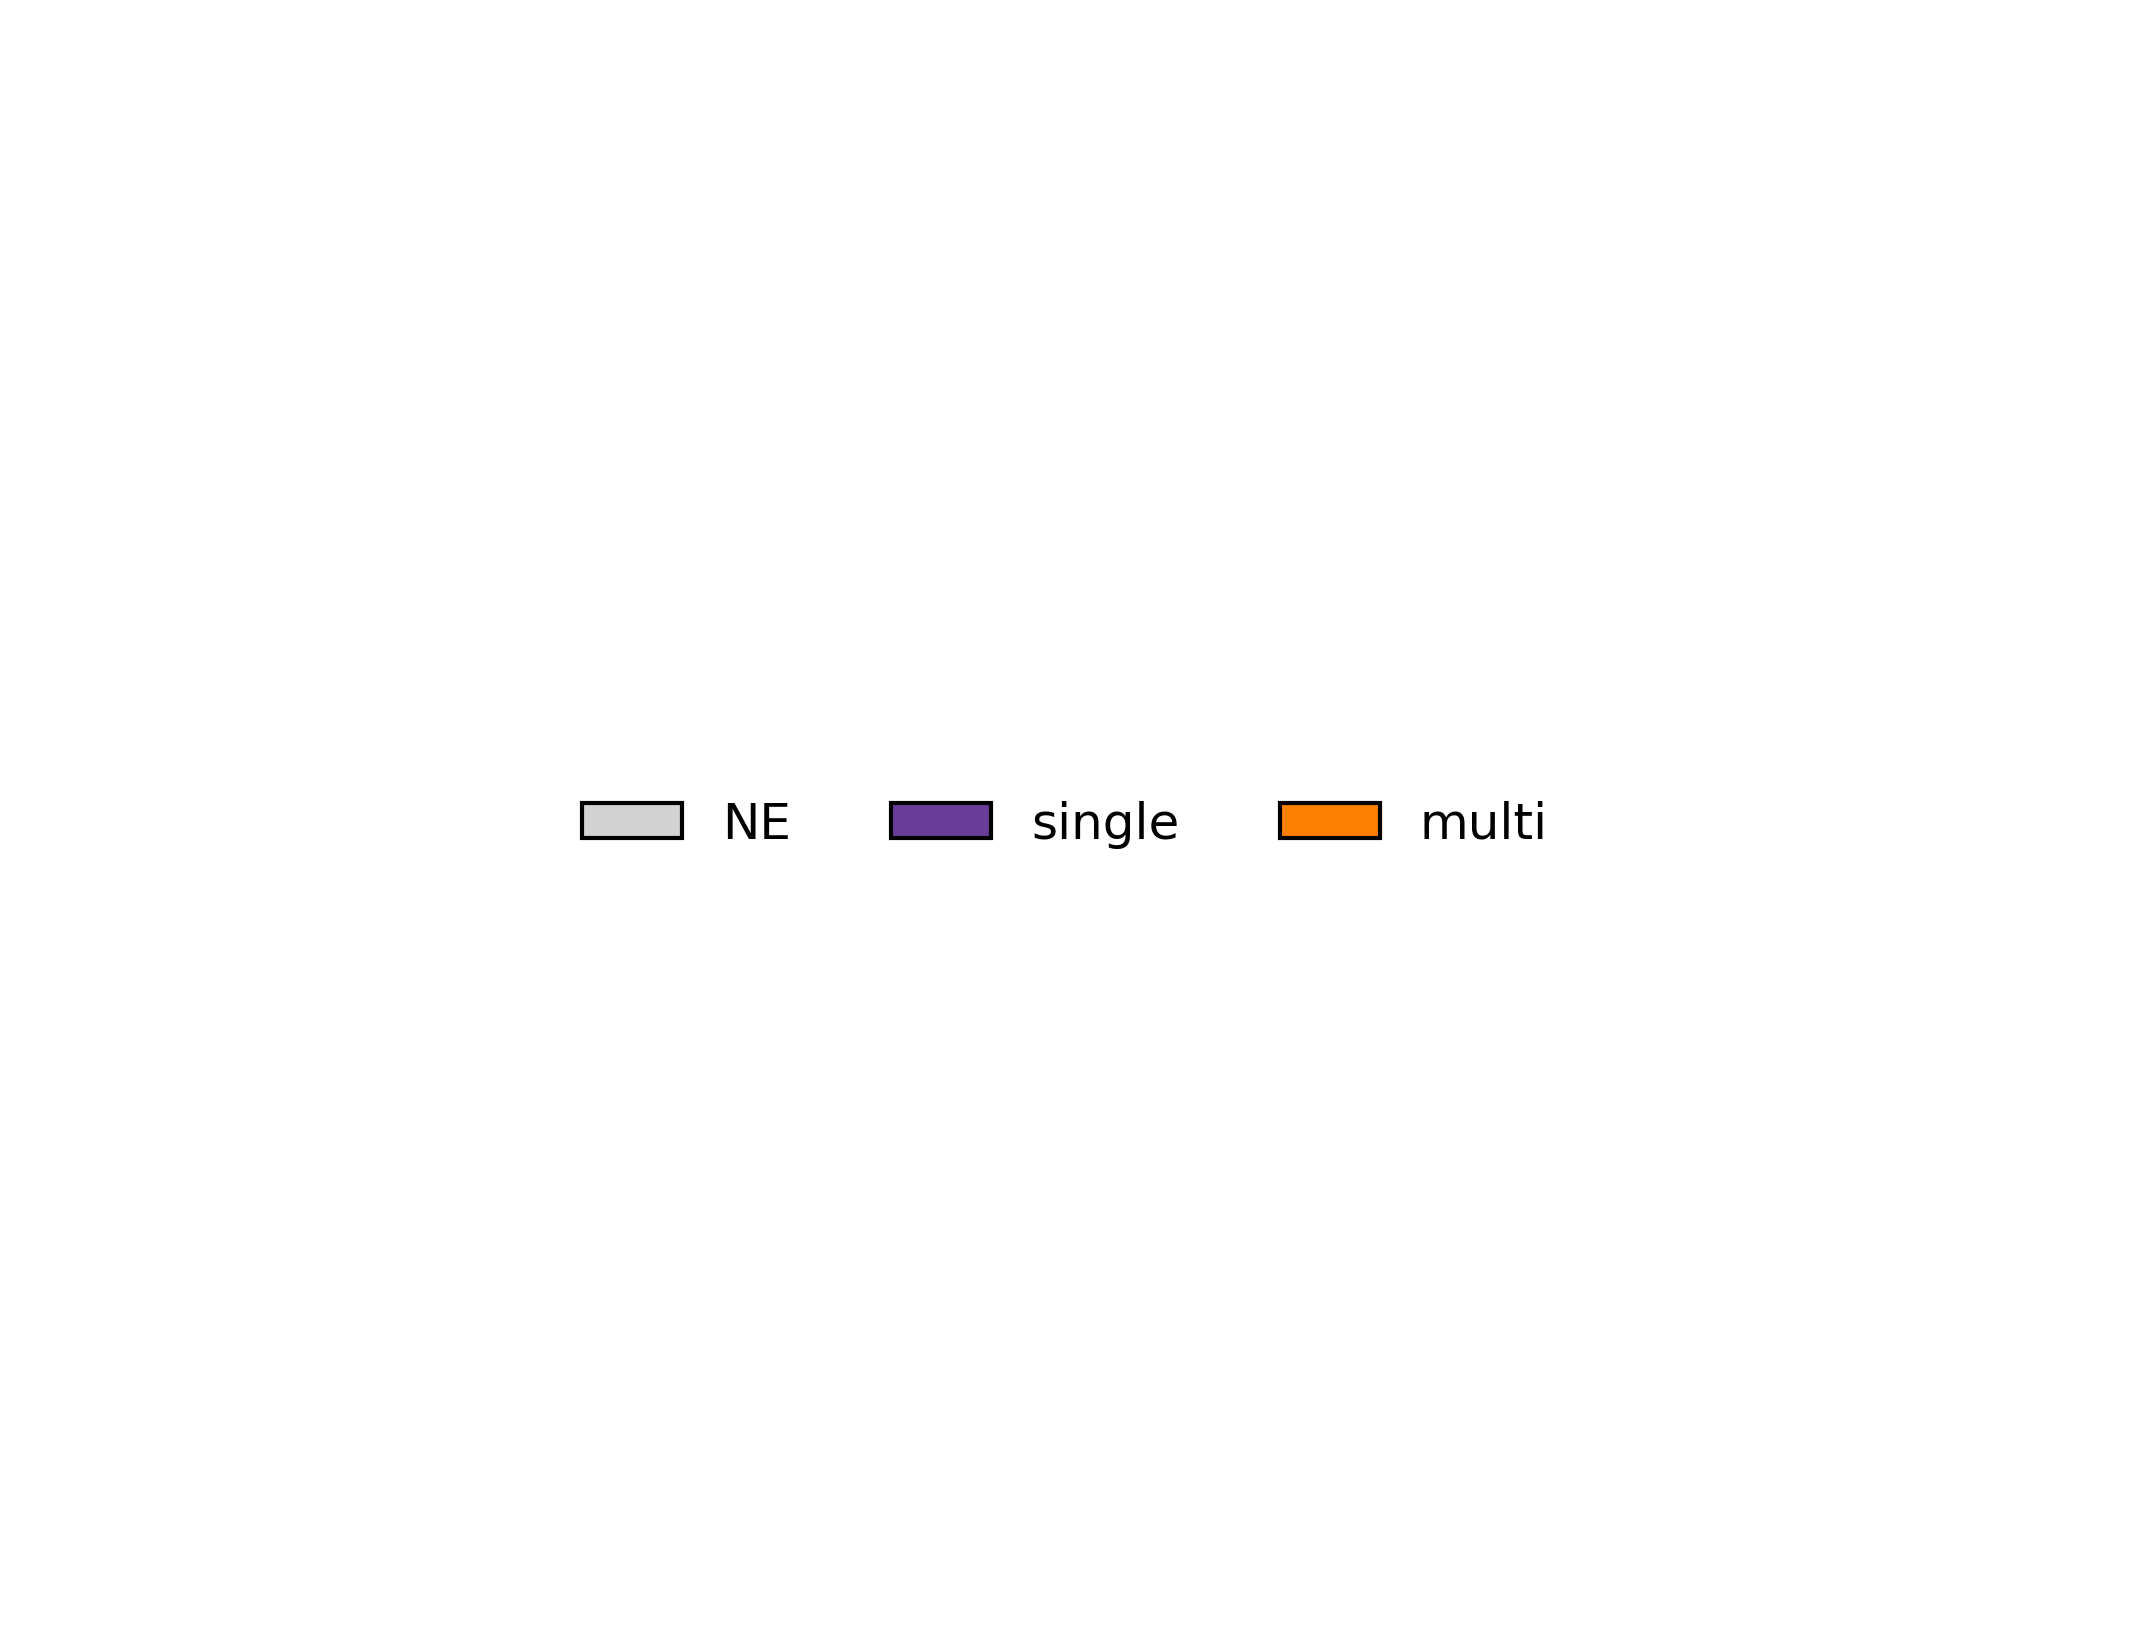

In [9]:
pdf = results.copy()
pdf = pdf.set_index('gene_name')
pdf = pdf[['initial', 'R1', 'R2', 'R3', 'HSC']]

# drop rows with all NE
mask = pdf.ne("NE").any(axis=1)
pdf = pdf[mask]
print(f"{pdf.shape=}")
print(pdf.head(10).to_string())

# Flatten transitions: from one stage to the next
stages = pdf.columns.tolist()
labels = ['NE', 'single', 'multi']
label_indices = {label: i for i, label in enumerate(labels)}
colors = {
    "NE" : '#d3d3d3',
    "single": '#6a3d9a',  # purple
    "multi": '#ff7f00',   # orange
}

def hex_to_rgba(hex_color, alpha=0.4):
    from matplotlib.colors import to_rgba
    rgba = to_rgba(hex_color, alpha)
    return f"rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, {rgba[3]:.2f})"


# Desired vertical sort order (top to bottom)
label_order = ['multi', 'single', 'NE']

# Build nodes in consistent stage-wise order
nodes = []
node_lookup = {}
idx = 0
for stage in stages:
    for label in label_order:
        node_name = f"{stage}_{label}"
        nodes.append(node_name)
        node_lookup[node_name] = idx
        idx += 1

source = []
target = []
value = []
link_color = []

for i in range(len(stages) - 1):
    src_stage = stages[i]
    tgt_stage = stages[i + 1]
    
    transitions = pdf[[src_stage, tgt_stage]].values.tolist()
    counts = Counter(tuple(pair) for pair in transitions)
    
    for (src_val, tgt_val), count in counts.items():
        if src_val in labels and tgt_val in labels:
            src_idx = node_lookup[f"{src_stage}_{src_val}"]
            tgt_idx = node_lookup[f"{tgt_stage}_{tgt_val}"]
            source.append(src_idx)
            target.append(tgt_idx)
            value.append(count)
            link_color.append(hex_to_rgba(colors[src_val], alpha=0.5)),

# Sankey plot
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=30,
        line=dict(color="black", width=1.5),
        # label=[node.split('_')[0] for node in nodes],  # Strip stage
        color=[colors[node.split('_')[1]] for node in nodes]
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color=link_color,
    ))])

fig.update_layout(
    font_size=20,
    height=700,
    width=1000,
)
fig.show()


# Create legend handles
legend_elements = [Patch(facecolor=color, edgecolor='k', label=label)
                   for label, color in colors.items()]

# Create figure with only the legend
plt.rcParams['figure.dpi'] = 300
fig, ax = plt.subplots()
ax.axis('off')
legend = ax.legend(
    handles=legend_elements,
    loc='center',
    frameon=False,
    ncols=3,
    fontsize=12,
)
plt.tight_layout()
plt.show()

# Process adata

In [8]:
rsc.get.anndata_to_GPU(adata)
rsc.pp.filter_genes(adata, min_counts=30)

adata.layers['counts'] = adata.X.copy()

rsc.pp.normalize_total(adata, target_sum=1e4)
adata.layers['norm'] = adata.X.copy()

rsc.pp.log1p(adata)

rsc.get.anndata_to_CPU(adata)

adata.layers['log_norm'] = adata.X.copy()
adata

filtered out 43994 genes that are detected in less than 30 counts


AnnData object with n_obs × n_vars = 20754 × 69341
    obs: 'dataset', 'source', 'label', 'cluster_all', 'group', 'subgroup', 'phase', 'S_score', 'G2M_score'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'uniprot', 'n_counts', 'n_cells'
    uns: 'label_colors', 'label_deg', 'scvi_expression', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', 'norm', 'log_norm'

In [11]:
print(f"{adata.obs['cluster_all'].value_counts()}\n")
print(f"{adata.obs['group'].value_counts()}\n")
print(f"{adata.obs['label'].value_counts()}\n")
print(f"{adata.obs['subgroup'].value_counts()}\n")

cluster_all
C4    4612
R2    4323
C5    3852
B1    2162
R1    1985
B5    1506
R3     524
B7     500
B2     496
B4     440
B3     302
B6      52
Name: count, dtype: int64

group
initial      8464
reprogram    6832
bm_other     3952
target       1506
Name: count, dtype: int64

label
initial    8464
R2         4323
MPP        2162
R1         1985
HSC        1506
R3          524
CLP         500
LMPP        496
MEG-ERY     440
CMP         302
GMP          52
Name: count, dtype: int64

subgroup
initial        8464
R2             4323
progenitors    2956
R1             1985
HSC            1506
R3              524
CLP             500
LMPP            496
Name: count, dtype: int64



In [9]:
# regroup
mapping = {
    'CLP': 'progenitors', 
    'LMPP': 'progenitors', 
}

adata.obs['subgroup'] = adata.obs['subgroup'].astype(str)

adata.obs['subgroup'] = adata.obs['subgroup'].replace(mapping)

adata.obs['subgroup'].value_counts()

subgroup
initial        8464
R2             4323
progenitors    3952
R1             1985
HSC            1506
R3              524
Name: count, dtype: int64

# Get isoform counts

In [10]:
%%time 

adata.X = adata.layers['counts'].copy()
# adata.X = adata.layers['log_norm'].copy()

rsc.get.anndata_to_GPU(adata)
print(f"{type(adata.X)=}")

aggdata = rsc.get.aggregate(
    adata, 
    by='subgroup',
    func='sum',
    axis=0,
)

rsc.get.anndata_to_CPU(aggdata, convert_all=True,)

aggdata.X = aggdata.layers['sum'].copy()

sc.pp.normalize_total(aggdata, target_sum=1e4)
sc.pp.log1p(aggdata)

aggdata.layers['log_norm'] = aggdata.X.copy()

aggdata

# df = aggdata.to_df(layer='sum')
df = aggdata.to_df(layer='log_norm')
df = df.T
df['total_transcript'] = df.sum(axis=1)

df = pd.merge(
    df, adata.var[['gene_name', 'gene_type', 'transcript_type']],
    how='left',
    left_index=True,
    right_index=True,
)
df = df.reset_index()
df = df.sort_values(by=['gene_name', 'transcript_name'])
df = df.reset_index(drop=True)
df['is_tf'] = df['gene_name'].isin(tf_list)
# df['uniprot'] = df['transcript_name'].map(transcript_2_uniprot)
df['uniprot'] = df['transcript_name'].map(transcript_map) # new mapping
print(f"{df.shape=}")
df.head()

type(adata.X)=<class 'cupyx.scipy.sparse._csr.csr_matrix'>
normalizing counts per cell
    finished (0:00:00)
df.shape=(69341, 13)
CPU times: user 134 ms, sys: 28.3 ms, total: 162 ms
Wall time: 191 ms


,transcript_name,HSC,R1,R2,R3,initial,progenitors,total_transcript,gene_name,gene_type,transcript_type,is_tf,uniprot
0,A1BG-202,0.003983,0.006532,0.007675,0.008778,0.001050,0.004470,0.032488,A1BG,protein_coding,retained_intron,False,NaN
1,A1BG-203,0.005307,0.023212,0.020228,0.017481,0.003446,0.005327,0.075000,A1BG,protein_coding,protein_coding_CDS_not_defined,False,NaN
2,A1BG-204,0.349051,1.181680,1.080645,0.814764,0.755470,0.406261,4.587871,A1BG,protein_coding,retained_intron,False,NaN
3,A1BG-AS1-202,0.026906,0.008158,0.002676,0.006591,0.006134,0.026187,0.076654,A1BG-AS1,lncRNA,lncRNA,False,NaN
4,A1BG-AS1-203,0.000000,0.002727,0.003678,0.000000,0.003296,0.000345,0.010046,A1BG-AS1,lncRNA,lncRNA,False,NaN


In [19]:
df['uniprot'].nunique() # old mapping

26105

In [23]:
df['uniprot'].nunique() # new mapping

26669

In [11]:
%%time
pdf = df.copy()

# count the number of isoforms per gene
pdf['n_isoforms'] = pdf.groupby('gene_name')['transcript_name'].transform('nunique')
pdf['n_protiens'] = pdf.groupby('gene_name')['uniprot'].transform('nunique')

groups = ['R1','R2', 'R3', 'initial', 'HSC']

# add grouped expression counts
grouped = pdf.groupby('gene_name')[groups].sum()
sum_columns  = [f'{col}_sum' for col in grouped.columns]
grouped.columns = sum_columns
pdf = pdf.merge(grouped, on='gene_name', how='left')

pdf['total_gene'] = pdf[sum_columns].sum(axis=1)

# add percentages
for col in groups:
    sum_col = f'{col}_sum'
    pct_col = f'{col}_pct'
    pdf[pct_col] = pdf[col] / pdf[sum_col]

print(pdf[['gene_name', 'transcript_name', 'R1_pct', 'R2_pct', 'R3_pct']].head().to_string())

  gene_name transcript_name    R1_pct    R2_pct    R3_pct
0      A1BG        A1BG-202  0.005392  0.006924  0.010438
1      A1BG        A1BG-203  0.019161  0.018247  0.020785
2      A1BG        A1BG-204  0.975447  0.974829  0.968777
3  A1BG-AS1    A1BG-AS1-202  0.138106  0.047931  0.120628
4  A1BG-AS1    A1BG-AS1-203  0.046161  0.065872  0.000000
CPU times: user 50.5 ms, sys: 3.79 ms, total: 54.3 ms
Wall time: 62.6 ms


## splicing events

In [25]:
fpath = "../resources/AS_events.csv.gz"

asdf = pd.read_csv(fpath)
asdf = asdf[asdf['gene_name'].notna()]
asdf = asdf.drop(columns=['gene_id', 'transcript_id', 'gene_name'])
asdf.head()

sedf = pdf.copy()
sedf = pd.merge(
    sedf, asdf,
    how='left',
)
print(f"{sedf.shape=}")
print()

sedf.head()

sedf.shape=(69341, 34)



,transcript_name,HSC,R1,R2,R3,initial,progenitors,total_transcript,gene_name,gene_type,...,initial_pct,HSC_pct,A3,A5,AF,AL,MX,RI,SE,num_events
0,A1BG-202,0.003983,0.006532,0.007675,0.008778,0.001050,0.004470,0.032488,A1BG,protein_coding,...,0.001382,0.011115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A1BG-203,0.005307,0.023212,0.020228,0.017481,0.003446,0.005327,0.075000,A1BG,protein_coding,...,0.004534,0.014810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A1BG-204,0.349051,1.181680,1.080645,0.814764,0.755470,0.406261,4.587871,A1BG,protein_coding,...,0.994084,0.974074,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A1BG-AS1-202,0.026906,0.008158,0.002676,0.006591,0.006134,0.026187,0.076654,A1BG-AS1,lncRNA,...,0.158101,0.545106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A1BG-AS1-203,0.000000,0.002727,0.003678,0.000000,0.003296,0.000345,0.010046,A1BG-AS1,lncRNA,...,0.084955,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


           SE    A5    A3   MX   RI    AF    AL
group                                          
HSC      7648  3016  4105  592  539  3508   962
R1       8382  3250  4464  712  544  3944  1114
R2       8500  3306  4525  716  559  3971  1123
R3       7713  2978  4066  627  485  3564   997
initial  9050  3550  4843  780  588  4245  1219


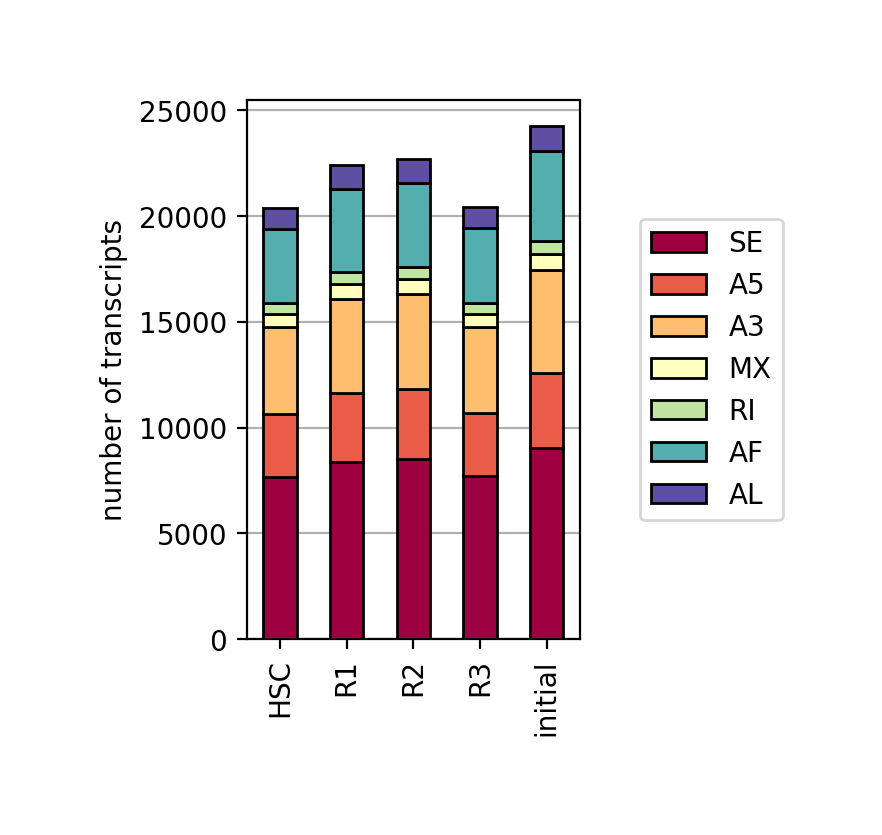

In [26]:
columns = [
    'gene_name', 'transcript_name',
    'transcript_type', 'uniprot',
     'A3', 'A5', 'AF', 'AL', 'MX', 'RI', 'SE',
    'R1','R2', 'R3', 'initial', 'HSC'
]

sedf = sedf[columns]
sedf = pd.melt(
    sedf, id_vars=columns[:-5],
)

event_types = {
    'SE': 'skipping exon',
    'A5': "alternative 5' splice site",
    'A3': "alternative 3' splice site",
    'MX': 'mutually exclusive exon',
    'RI': 'retained intron',
    'AF': 'alternative first exon',
    'AL': 'alternative last exon',
}

results = []
for group_name, group in sedf.groupby('variable'):
    # group = group[group['transcript_type'] == 'protein_coding']
    group = group[group['uniprot'].notna()]

    row = {
        'group' : group_name,
    }

    for event_type, event_label in event_types.items():
        count = group[(group[event_type] == True) & (group['value'] > 0)]['transcript_name'].nunique()
        row[event_type] = count

    results.append(row)
    
results = pd.DataFrame(results)
results = results.set_index('group')
print(results.to_string())

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 2.15, 3.5
results.plot(
    kind='bar',
    stacked=True,
    ec='k',
    zorder=10,
    cmap='Spectral'
)

plt.grid(axis='y', zorder=0)
plt.xlabel("")
plt.ylabel("number of transcripts")
sns.move_legend(
    plt.gca(),
    loc='center right',
    title='',
    bbox_to_anchor=(1.65, 0.5)
)

df1.shape=(69341, 20)


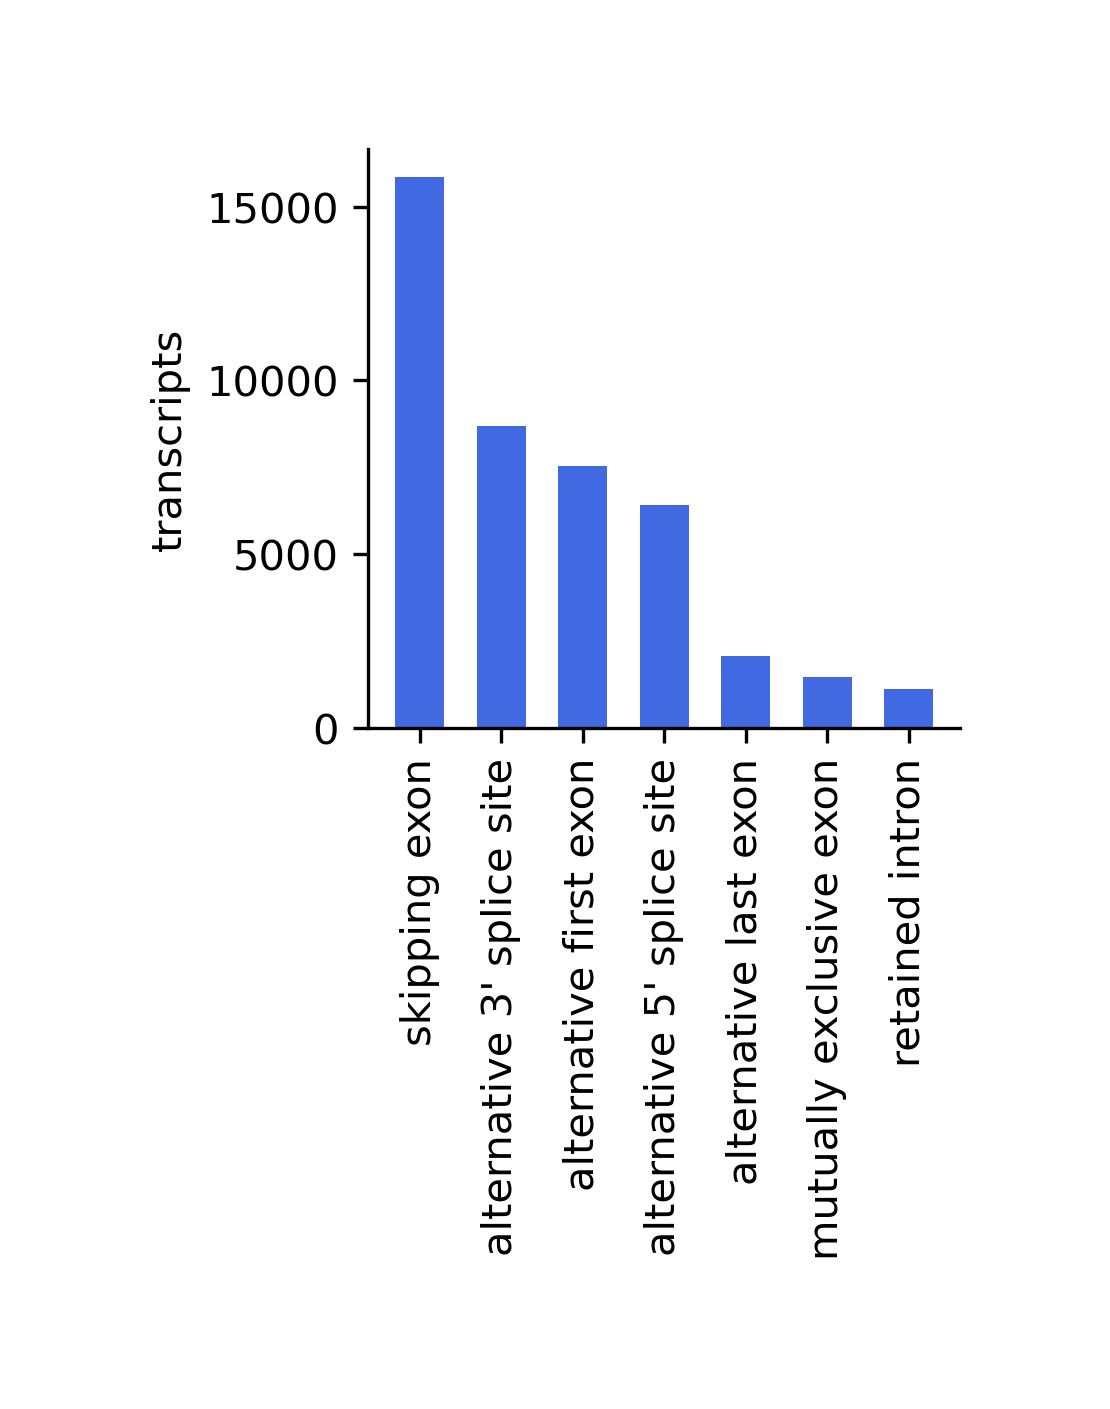

In [27]:
df1 = adata.var.copy()
df1 = df1.reset_index(drop=True)

df1 = pd.merge(
    df1, asdf,
    how='left',
)
print(f"{df1.shape=}")
df1.head()

event_types = {
    'SE': 'skipping exon',
    'A5': "alternative 5' splice site",
    'A3': "alternative 3' splice site",
    'MX': 'mutually exclusive exon',
    'RI': 'retained intron',
    'AF': 'alternative first exon',
    'AL': 'alternative last exon',
}


# compute and sort
plot_df = df1[list(event_types.keys())].sum(axis=0)
pdf_sorted = plot_df.sort_values(ascending=False)

# prepare labels/values
labels = [event_types[code] for code in pdf_sorted.index ]
values = pdf_sorted.values

# plot
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 3, 4 # 4, 2.5
# plt.barh(
#     labels, 
#     values, 
#     height=0.6,
#     color='royalblue',
#     # width=0.7,
#     # ec='k'
# )
# plt.xlabel('transcripts')


plt.bar(
    labels, 
    values, 
    width=0.6,
    color='royalblue',
)
plt.ylabel('transcripts')
plt.xticks(rotation=90)
plt.tight_layout()
sns.despine()
plt.show()

[Text(0, 0.4, '0.0'),
 Text(0, 0.5, '0.5'),
 Text(0, 0.6, '0.6'),
 Text(0, 0.7, '0.7'),
 Text(0, 0.8, '0.8'),
 Text(0, 0.8999999999999999, '0.9'),
 Text(0, 1.0, '1.0')]

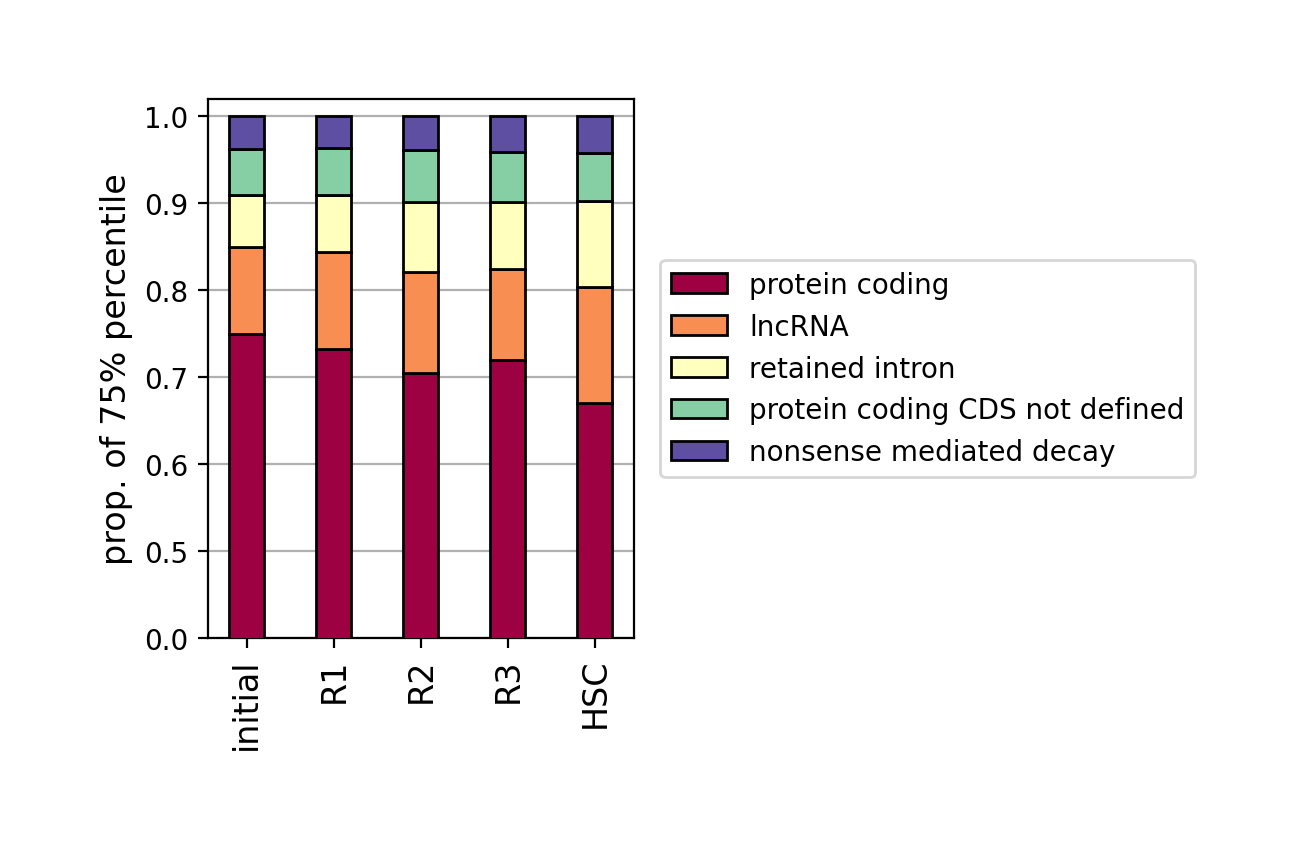

In [30]:
p = 0.75
cols = ['initial','R1', 'R2', 'R3', 'HSC']

keep = [
    'retained_intron',
    'protein_coding_CDS_not_defined',
    'lncRNA',
    'protein_coding',
    'nonsense_mediated_decay',
    # 'protein_coding_LoF',
]

proportions = {}
for col in cols:
    thresh = pdf[col].quantile(p)
    mask   = (pdf[col] > thresh) & pdf['transcript_type'].isin(keep)
    cnts   = pdf.loc[mask, 'transcript_type'].value_counts(normalize=True)
    cnts.index = cnts.index.str.replace("_", " ")
    proportions[col] = cnts

result = pd.DataFrame(proportions).fillna(0)

# pick the order you want – here, descending in “initial”
order = result['initial'].sort_values(ascending=False).index

# reindex so the stacks plot in that order
result = result.loc[order]
result = result.loc[(result != 0).any(axis=1)]

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 2.75, 3.5
result.T.plot(
    kind='bar',
    stacked=True,
    ec='k',
    zorder=10,
    cmap='Spectral',
    width=0.4,
)

plt.grid(axis='y', zorder=0)
sns.move_legend(
    plt.gca(),
    loc='center right',
    title='',
    bbox_to_anchor=(2.35, 0.5)
)
plt.ylabel(f'prop. of {int(p*100)}% percentile', fontsize=12)
plt.ylim([0.4, 1.02])

n_ticks = 7  # Set as needed
yticks = np.linspace(0.4, 1.0, n_ticks)
yticklabels = [f"{round(t, 3)}" for t in yticks]

ax = plt.gca()
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
yticklabels[0] = 0.0    # set lowest label manually
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)

# Top isoforms

In [12]:
def get_top(df, col):
    # Remove groups with any NaN
    mask = df.groupby('gene_name', observed=True)[col].transform(lambda x: x.isna().any())
    df_valid = df[~mask]

    # Get index of max value per group
    top_idx = df_valid.groupby('gene_name', observed=True)[col].idxmax()
    counts = df_valid.groupby('gene_name', observed=True)[col].apply(lambda x: (x == x.max()).sum())

    # Build mapping and drop ties
    top_map = df_valid.loc[top_idx, ['gene_name', 'transcript_name']].set_index('gene_name')['transcript_name']
    top_map[counts > 1] = np.nan

    return df['gene_name'].map(top_map)

pct_cols = ['R1_pct', 'R2_pct', 'R3_pct', 'initial_pct', 'HSC_pct']

for col in pct_cols:
    pdf[f'{col}_top'] = get_top(pdf, col)

pdf.head()

,transcript_name,HSC,R1,R2,R3,initial,progenitors,total_transcript,gene_name,gene_type,...,R1_pct,R2_pct,R3_pct,initial_pct,HSC_pct,R1_pct_top,R2_pct_top,R3_pct_top,initial_pct_top,HSC_pct_top
0,A1BG-202,0.003983,0.006532,0.007675,0.008778,0.001050,0.004470,0.032488,A1BG,protein_coding,...,0.005392,0.006924,0.010438,0.001382,0.011115,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204
1,A1BG-203,0.005307,0.023212,0.020228,0.017481,0.003446,0.005327,0.075000,A1BG,protein_coding,...,0.019161,0.018247,0.020785,0.004534,0.014810,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204
2,A1BG-204,0.349051,1.181680,1.080645,0.814764,0.755470,0.406261,4.587871,A1BG,protein_coding,...,0.975447,0.974829,0.968777,0.994084,0.974074,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204
3,A1BG-AS1-202,0.026906,0.008158,0.002676,0.006591,0.006134,0.026187,0.076654,A1BG-AS1,lncRNA,...,0.138106,0.047931,0.120628,0.158101,0.545106,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-202
4,A1BG-AS1-203,0.000000,0.002727,0.003678,0.000000,0.003296,0.000345,0.010046,A1BG-AS1,lncRNA,...,0.046161,0.065872,0.000000,0.084955,0.000000,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-202


## Pie charts

In [32]:
groups = ['initial', 'R1', 'R2', 'R3', 'HSC']

counts = []
for group in groups:
    tmp = pdf[[group, 'transcript_name', 'transcript_type']].copy()
    detected = tmp[tmp[group] > 0]
    
    total_transcripts = detected['transcript_name'].nunique()
    pc_transcripts = detected[detected['transcript_type'] == 'protein_coding']['transcript_name'].nunique()
    nonpc_transcripts = detected[detected['transcript_type'] != 'protein_coding']['transcript_name'].nunique()
    
    counts.append({
        'group': group,
        'total_transcripts': total_transcripts,
        'protein-coding': pc_transcripts,
        'other': nonpc_transcripts,
    })

counts = pd.DataFrame(counts).set_index('group')

counts['pct_pc'] = counts['protein-coding'] / counts['total_transcripts']

counts

,total_transcripts,protein-coding,other,pct_pc
group,,,,
initial,61245,32250,28995,0.526574
R1,56786,30240,26546,0.532526
R2,57711,30517,27194,0.528790
R3,51143,27612,23531,0.539898
HSC,51294,27387,23907,0.533922


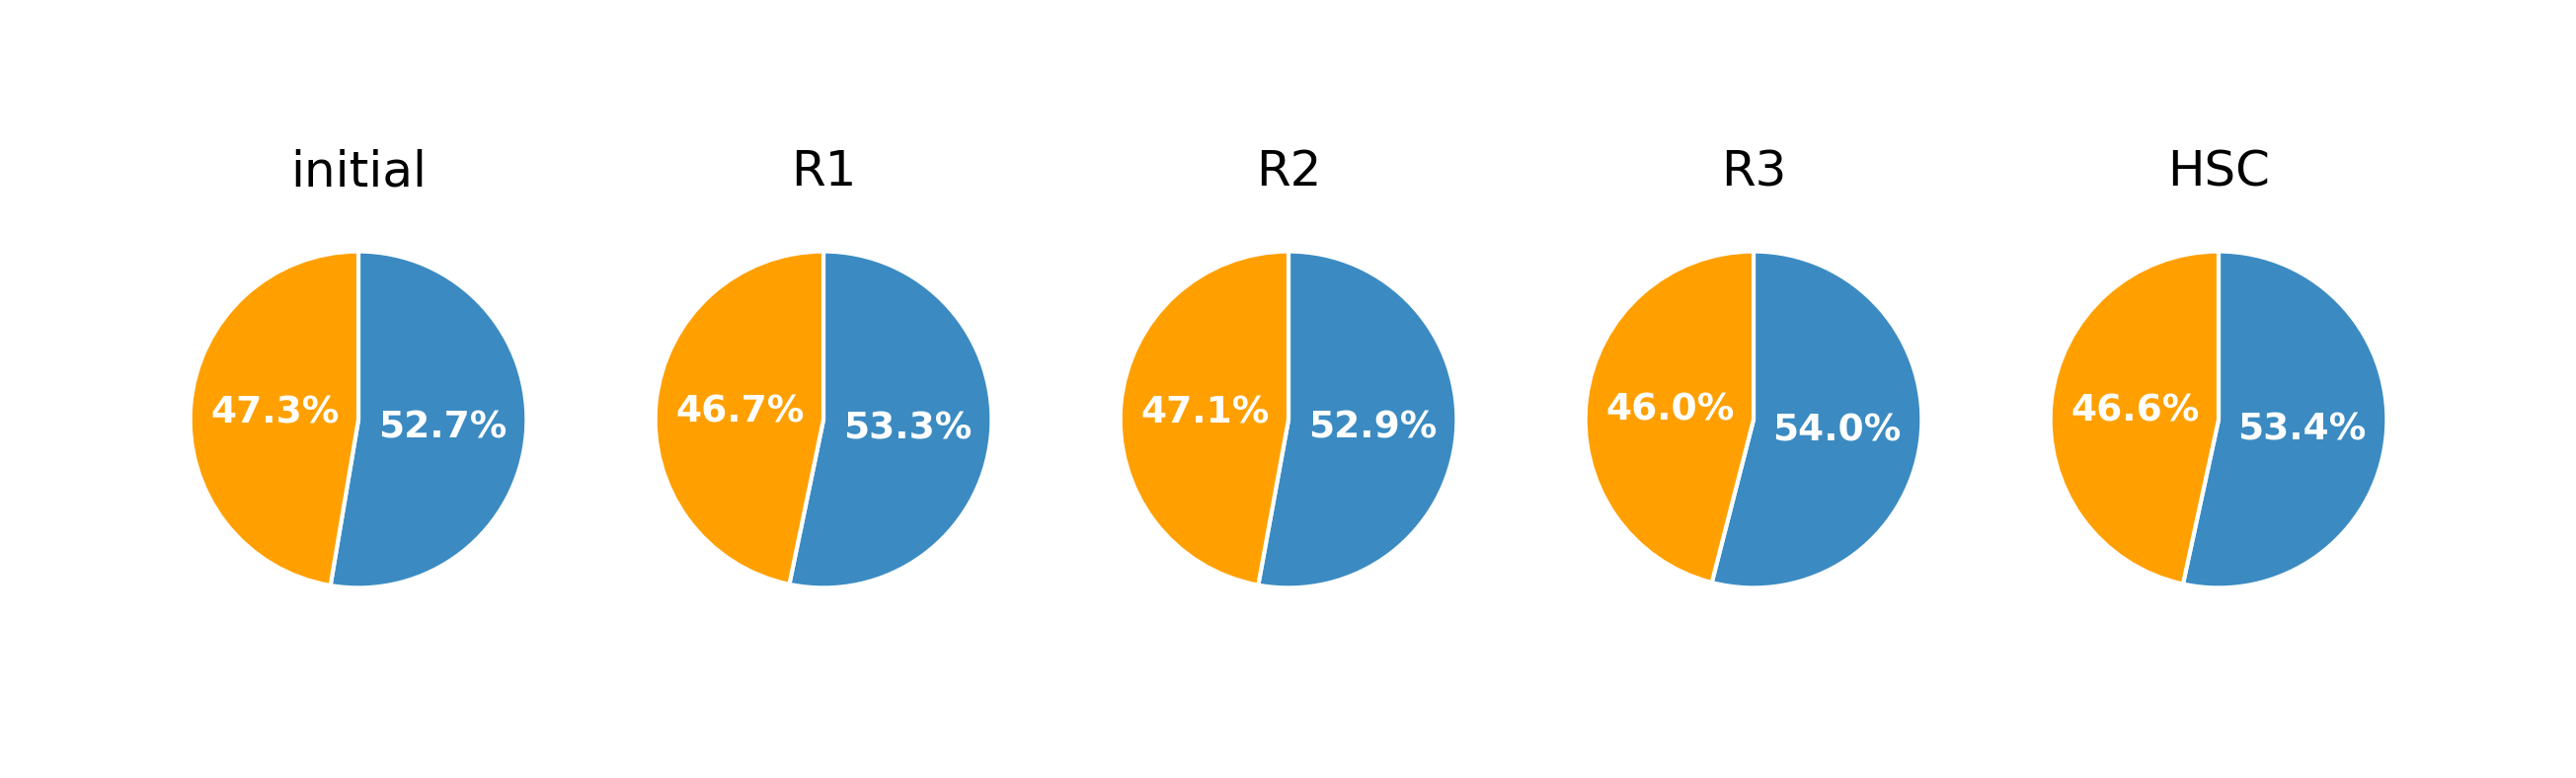

In [34]:
color_map = {
    'protein-coding': '#3b8bc2',
    'other': '#FFA000',#'#fbc02d',
}

plt.rcParams['figure.figsize'] = 8, 2
plt.rcParams['figure.dpi'] = 300
fig, axes = plt.subplots(1, 5)
axes = axes.flatten()

for i, group in enumerate(groups):
    ax = axes[i]
    data = counts.loc[group]
    data = data[['protein-coding', 'other']]
    colors = [color_map[cond] for cond in data.index]
    
    wedges, label, pcts = ax.pie(
        data,
        labels=None,
        startangle=90,
        colors=colors,
        counterclock=False,
        wedgeprops=dict(linewidth=1, edgecolor='white'),
        autopct='%1.1f%%',
        pctdistance=0.5,
    )
    
    for pct in pcts:
        pct.set_color("white")
        pct.set_fontsize(9)
        pct.set_fontweight('bold')
        
    ax.set(aspect='equal')
    ax.set_title(group, fontsize=12)
    
# fig.legend(
#     handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[cond], markersize=6) 
#              for cond in color_map],
#     labels=color_map.keys(),
#     loc='center left',
#     bbox_to_anchor=(1.01, 0.5),
#     fontsize='small',
#     frameon=False
# )

plt.tight_layout()
plt.show()

In [35]:
# of the non-coding, what are proportions
nc_transcript_types = [
    'retained_intron',
    'protein_coding_CDS_not_defined',
    'lncRNA',
    # 'protein_coding',
    'nonsense_mediated_decay',
]

groups = ['initial', 'R1', 'R2', 'R3', 'HSC']

nc_counts = []
for group in groups:
    tmp = pdf[[group, 'transcript_name', 'transcript_type']].copy()
    detected = tmp[tmp[group] > 0]
    
    # Get total non-coding transcripts
    nonpc = detected[detected['transcript_type'].isin(nc_transcript_types)]
    total_nonpc = nonpc['transcript_name'].nunique()
    
    # For each non-coding type, count unique transcript_names
    for nc_type in nc_transcript_types:
        n = nonpc[nonpc['transcript_type'] == nc_type]['transcript_name'].nunique()
        proportion = n / total_nonpc if total_nonpc > 0 else 0
        nc_counts.append({
            'group': group,
            'noncoding_type': nc_type,
            'count': n,
            'proportion': proportion
        })

nc_counts = pd.DataFrame(nc_counts)#.set_index('group')
nc_counts.head()

,group,noncoding_type,count,proportion
0,initial,retained_intron,8665,0.299651
1,initial,protein_coding_CDS_not_defined,5489,0.189819
2,initial,lncRNA,10923,0.377736
3,initial,nonsense_mediated_decay,3840,0.132794
4,R1,retained_intron,7845,0.296340


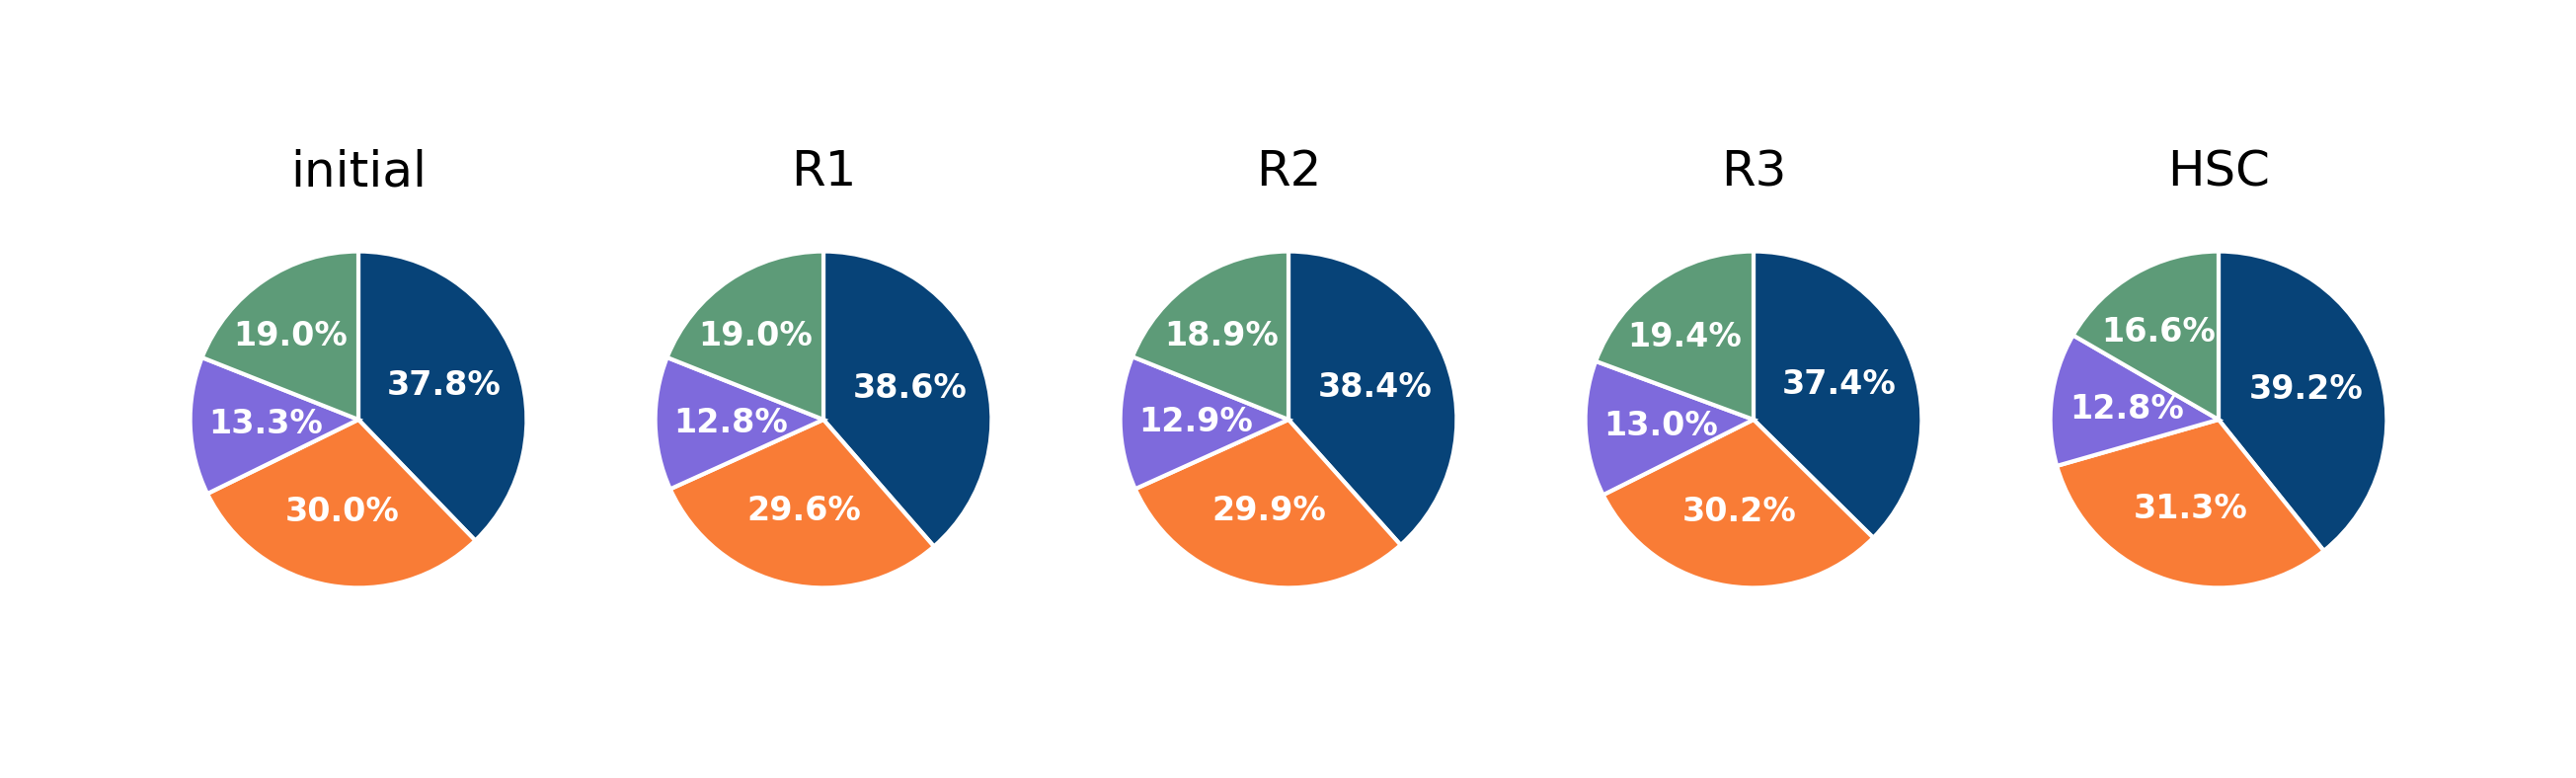

In [36]:
color_map = {
    'lncRNA': '#074378',
    'retained_intron': '#F97C36',
    'nonsense_mediated_decay': '#7E6ADC',#'#5E4FA2',
    'protein_coding_CDS_not_defined': '#5D9B78',
}

type_order = [c for c in color_map]

plt.rcParams['figure.figsize'] = 8, 2
plt.rcParams['figure.dpi'] = 300
fig, axes = plt.subplots(1, 5)
axes = axes.flatten()

for i, group in enumerate(groups):
    ax = axes[i]
    
    props = nc_counts[nc_counts['group'] == group].set_index('noncoding_type')['proportion']
    props = props.reindex(type_order, fill_value=0)
    colors = [color_map[t] for t in props.index]
    
    wedges, label, pcts = ax.pie(
        props,
        labels=None,
        startangle=90,
        colors=colors,
        counterclock=False,
        wedgeprops=dict(linewidth=1, edgecolor='white'),
        autopct='%1.1f%%',
        pctdistance=0.55,
    )
    
    for idx, pct in enumerate(pcts):
        noncoding_type = props.index[idx]
        pct.set_color("white")
        pct.set_fontsize(8)
        pct.set_fontweight('bold')
        pct.set_horizontalalignment('center')
        pct.set_verticalalignment('center')
        
        if noncoding_type == 'protein_coding_CDS_not_defined':
            pct.set_position((1.3*pct.get_position()[0], 1.1*pct.get_position()[1]))
        
    ax.set(aspect='equal')
    ax.set_title(group, fontsize=12)
    
# fig.legend(
#     handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[cond], markersize=6) 
#              for cond in color_map],
#     labels=[cond.replace("_", " ") for cond in type_order],#color_map.keys(),
#     loc='center left',
#     bbox_to_anchor=(1.01, 0.5),
#     fontsize='small',
#     frameon=False
# )

plt.tight_layout()
plt.show()

## venn

N total protein-coding genes: 14901
N genes in top 50.0%: 5495


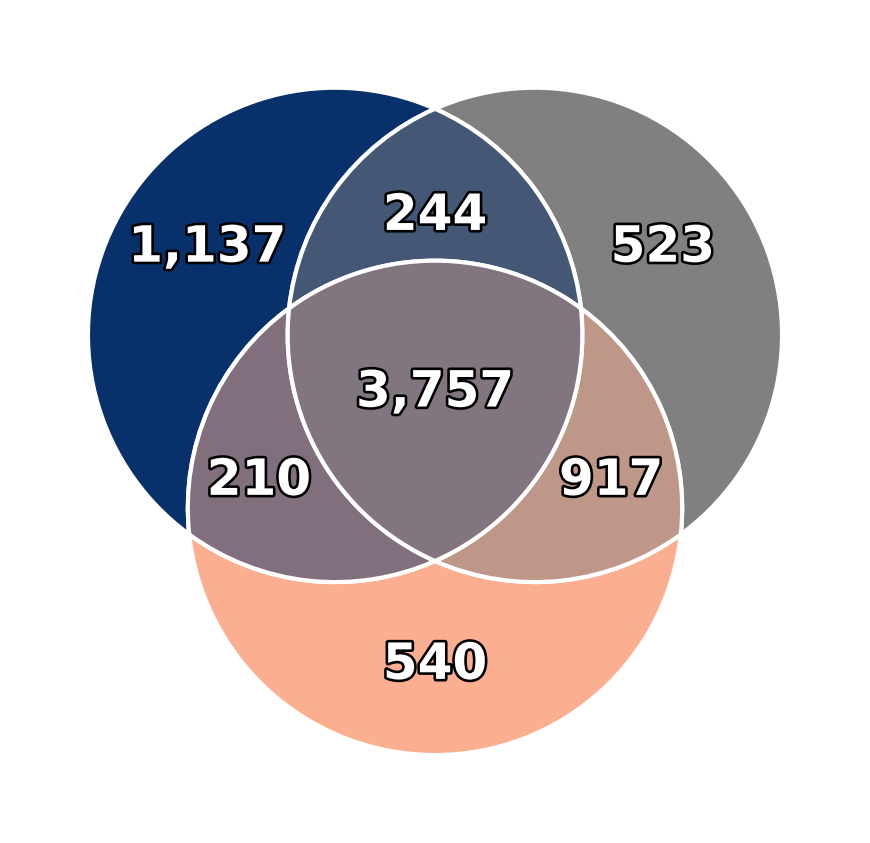

In [44]:
group = 'R1'

quant = 0.5

vdf = pdf[['transcript_name', 'gene_name', 'gene_type', 'total_transcript',
           'initial_pct_top', f'{group}_pct_top', 'HSC_pct_top']]

# filter for protein-coding
vdf = vdf[vdf['gene_type'] == 'protein_coding']
print(f"N total protein-coding genes: {vdf['gene_name'].nunique()}")

# filter for top expressed genes
vdf['total_gene'] = vdf.groupby('gene_name')['total_transcript'].transform('sum')
thresh = vdf['total_gene'].quantile(quant)
vdf = vdf[vdf['total_gene'] > thresh]
print(f"N genes in top {quant*100}%: {vdf['gene_name'].nunique()}")

# plotting clean-up
vdf = vdf.drop_duplicates(subset=['gene_name'], keep='first')
vdf_clean = vdf.dropna(subset=['initial_pct_top', f'{group}_pct_top', 'HSC_pct_top'])

set1 = set(vdf['initial_pct_top'].dropna())
set2 = set(vdf[f'{group}_pct_top'].dropna())
set3 = set(vdf['HSC_pct_top'].dropna())

group_names = ['HSC', 'initial', f'{group}']


if group == 'R1':
    group_color = '#FCAE91'
elif group == 'R2':
    group_color = '#FB6A4A'
else:
    group_color = '#CB181D'

    
colors_rgb = {
    'initial': mcolors.to_rgb('#808080'),    
    f'{group}': mcolors.to_rgb(group_color), 
    'HSC': mcolors.to_rgb('#08306B')      
}

def blend(colors):
    arr = np.array(colors)
    return tuple(arr.mean(axis=0))

venn_ids = {
    '100': ['HSC'],
    '010': ['initial'],
    '001': [f'{group}'],
    '110': ['HSC', 'initial'],
    '101': ['HSC', f'{group}'],
    '011': ['initial', f'{group}'],
    '111': ['HSC', 'initial', f'{group}']
}

plt.rcdefaults()
plt.rcParams['figure.dpi'] = 300
plt.figure(figsize=(3, 3))

venn = venn3_unweighted(
    [set3, set1, set2],
    set_labels=group_names
)

for label in venn.set_labels:
        if label:
            label.set_visible(False)
            # label.set_fontsize(11)

for subset_id, sets in venn_ids.items():
    patch = venn.get_patch_by_id(subset_id)
    if patch:
        color = blend([colors_rgb[s] for s in sets])
        patch.set_facecolor(color)
        patch.set_edgecolor('white')
        patch.set_linewidth(1)
        patch.set_alpha(1)
    label = venn.get_label_by_id(subset_id)
    if label:
        label.set_text(f"{int(label.get_text()):,}")
        label.set_fontsize(12)
        label.set_fontweight('bold')
        label.set_horizontalalignment('center')
        label.set_verticalalignment('center')
        label.set_color('white')        
        label.set_path_effects([
            path_effects.Stroke(linewidth=1.25, foreground='black'),
            path_effects.Normal()])
        
        x, y = label.get_position()
        offset = 0
        if subset_id == '101':  # nudge left
            offset = -0.04
        elif subset_id == '011': # nudge right
            offset = 0.04
        elif subset_id == '100':
            offset = 0.04
        elif subset_id == '010':
            offset = -0.04
        label.set_position((x + offset, y))
        if subset_id == '001':
            label.set_position((x, y + 0.03))

plt.tight_layout()
plt.show()

N total protein-coding genes: 14901
N genes in top 50.0%: 5495


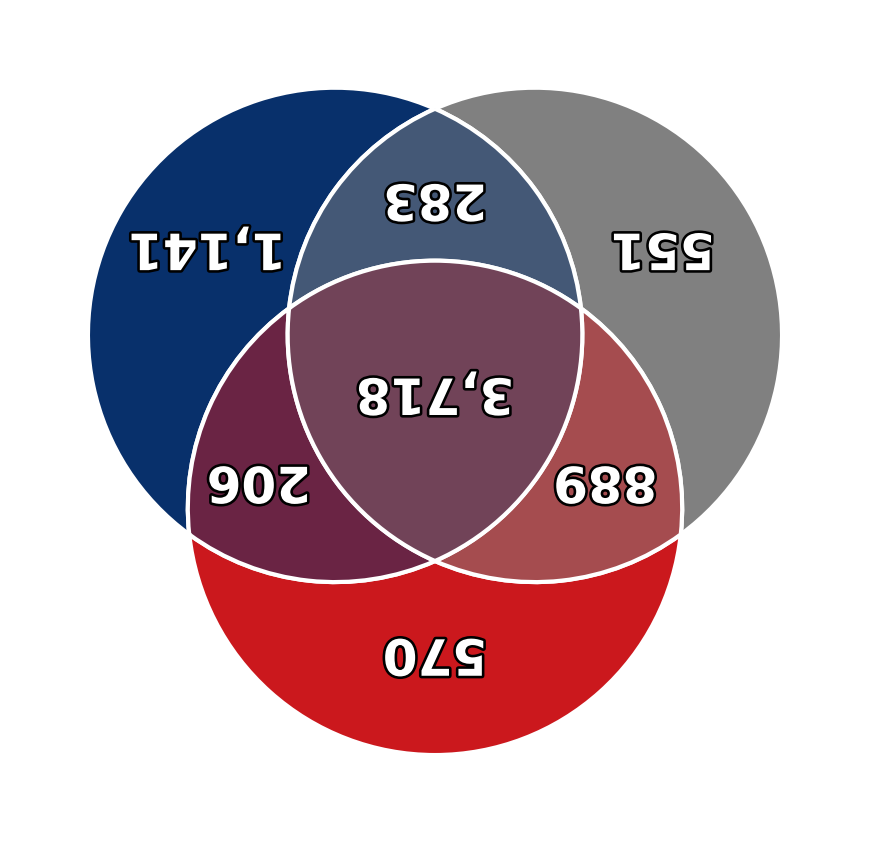

In [56]:
# upside down text labels

group = 'R3'

quant = 0.5

vdf = pdf[['transcript_name', 'gene_name', 'gene_type', 'total_transcript',
           'initial_pct_top', f'{group}_pct_top', 'HSC_pct_top']]

# filter for protein-coding
vdf = vdf[vdf['gene_type'] == 'protein_coding']
print(f"N total protein-coding genes: {vdf['gene_name'].nunique()}")

# filter for top expressed genes
vdf['total_gene'] = vdf.groupby('gene_name')['total_transcript'].transform('sum')
thresh = vdf['total_gene'].quantile(quant)
vdf = vdf[vdf['total_gene'] > thresh]
print(f"N genes in top {quant*100}%: {vdf['gene_name'].nunique()}")

# plotting clean-up
vdf = vdf.drop_duplicates(subset=['gene_name'], keep='first')
vdf_clean = vdf.dropna(subset=['initial_pct_top', f'{group}_pct_top', 'HSC_pct_top'])

set1 = set(vdf['initial_pct_top'].dropna())
set2 = set(vdf[f'{group}_pct_top'].dropna())
set3 = set(vdf['HSC_pct_top'].dropna())

group_names = ['HSC', 'initial', f'{group}']


if group == 'R1':
    group_color = '#FCAE91'
elif group == 'R2':
    group_color = '#FB6A4A'
else:
    group_color = '#CB181D'

    
colors_rgb = {
    'initial': mcolors.to_rgb('#808080'),    
    f'{group}': mcolors.to_rgb(group_color), 
    'HSC': mcolors.to_rgb('#08306B')      
}

def blend(colors):
    arr = np.array(colors)
    return tuple(arr.mean(axis=0))

venn_ids = {
    '100': ['HSC'],
    '010': ['initial'],
    '001': [f'{group}'],
    '110': ['HSC', 'initial'],
    '101': ['HSC', f'{group}'],
    '011': ['initial', f'{group}'],
    '111': ['HSC', 'initial', f'{group}']
}

plt.rcdefaults()
plt.rcParams['figure.dpi'] = 300
plt.figure(figsize=(3, 3))

venn = venn3_unweighted(
    [set3, set1, set2],
    set_labels=group_names
)

for label in venn.set_labels:
        if label:
            label.set_visible(False)
            # label.set_fontsize(11)

for subset_id, sets in venn_ids.items():
    patch = venn.get_patch_by_id(subset_id)
    if patch:
        color = blend([colors_rgb[s] for s in sets])
        patch.set_facecolor(color)
        patch.set_edgecolor('white')
        patch.set_linewidth(1)
        patch.set_alpha(1)
    label = venn.get_label_by_id(subset_id)
    if label:
        label.set_text(f"{int(label.get_text()):,}")
        label.set_fontsize(12)
        label.set_fontweight('bold')
        label.set_horizontalalignment('center')
        label.set_verticalalignment('center')
        label.set_color('white')
        
        label.set_rotation(180)
        label.set_rotation_mode('anchor')
        
        label.set_path_effects([
            path_effects.Stroke(linewidth=1.25, foreground='black'),
            path_effects.Normal()])
        
        x, y = label.get_position()
        offset = 0
        if subset_id == '101':  # nudge left
            offset = -0.04
        elif subset_id == '011': # nudge right
            offset = 0.03
        elif subset_id == '100':
            offset = 0.04
        elif subset_id == '010':
            offset = -0.04
        label.set_position((x + offset, y))
        if subset_id == '001':
            label.set_position((x, y + 0.05))
        if subset_id == '110':
            label.set_position((x, y + 0.03))

plt.tight_layout()
plt.show()

# Get DEIs

In [57]:
def get_significant_DEGs(df, alpha=0.05, logfc_thresh=0.5, pct_nz_thresh=0.0):
    
    tmp = df.copy()
    
    print(f"Filtering for significant DEGs (adjusted p-value < {alpha}, logfoldchange > {logfc_thresh})...")

    tmp['abs_lfc'] = tmp['logfoldchanges'].apply('abs')
    tmp = tmp[(tmp['abs_lfc'] > logfc_thresh) & (tmp['pvals_adj'] < alpha)]

    if pct_nz_thresh != 0.0:
        if 'pct_nz_reference' in tmp.columns:
            # make sure either group of interest OR reference has % cells expressing above threshold
            tmp = tmp[(tmp['pct_nz_group'] > pct_nz_thresh) | (tmp['pct_nz_reference'] > pct_nz_thresh)]
            print(f"Removed genes expressed in less than {pct_nz_thresh*100}% of group OR reference cells.")
        
        else:
            # Only apply pct_nz_group filter to upregulated genes
            upregulated_mask = tmp['logfoldchanges'] > 0
            keep_mask = (~upregulated_mask) | (tmp['pct_nz_group'] > pct_nz_thresh)
            tmp = tmp[keep_mask]

            tmp = tmp[tmp['pct_nz_group'] > pct_nz_thresh]
            print(f"Removed upregaulted genes expressed in less than {pct_nz_thresh*100}% of cells. Kept all downregulated genes.")
    
    # print(f"N unique significant DEGs: {tmp['names'].nunique()}\n")
    
    return tmp

In [58]:
%%time

# C2 and C3 vs initial
sc.tl.rank_genes_groups(
    adata, 
    groupby='label',
    groups=['R1', 'R2', 'R3'],
    reference='initial',
    method='wilcoxon',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='reprogram_vs_initial',
)

# C2 and C3 vs target
sc.tl.rank_genes_groups(
    adata, 
    groupby='label',
    groups=['R1', 'R2', 'R3'],
    reference='HSC',
    method='wilcoxon',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='reprogram_vs_target',
)

# # C2 vs C3
# sc.tl.rank_genes_groups(
#     adata, 
#     groupby='label',
#     groups=['C2'],
#     reference='C3',
#     method='wilcoxon',
#     use_raw=False,
#     layer='log_norm',
#     pts=True,
#     key_added='C2_vs_C3',
# )

adata

ranking genes


... storing 'subgroup' as categorical
... storing 'uniprot' as categorical


    finished (0:03:11)
ranking genes
    finished (0:00:41)
CPU times: user 2min 20s, sys: 46.9 s, total: 3min 7s
Wall time: 3min 52s


AnnData object with n_obs × n_vars = 20754 × 69341
    obs: 'dataset', 'source', 'label', 'cluster_all', 'group', 'subgroup', 'phase', 'S_score', 'G2M_score'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'uniprot', 'n_counts', 'n_cells'
    uns: 'label_colors', 'label_deg', 'scvi_expression', 'log1p', 'reprogram_vs_initial', 'reprogram_vs_target'
    obsm: 'X_umap'
    layers: 'counts', 'norm', 'log_norm'

In [102]:
# deg = sc.get.rank_genes_groups_df(
#     adata, 
#     group=None,
#     key='C2_vs_C3',
# )

# deg['gene_name'] = deg['names'].str.split('-', n=1).str[0]

# sig = get_significant_DEGs(deg, logfc_thresh=0.5, pct_nz_thresh=0.3)
# print(sig.shape)

# sig['is_tf'] = sig['gene_name'].isin(tf_list)

# print(f"N unique DEGs: {sig['gene_name'].nunique()}")
# print(f"N unique DEIs: {sig['names'].nunique()}")

# sig.head()

Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
Removed upregaulted genes expressed in less than 30.0% of cells. Kept all downregulated genes.
(275, 8)
N unique DEGs: 252
N unique DEIs: 275


,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,gene_name,abs_lfc,is_tf
0,S100A11-201,33.584625,0.511436,2.812820e-247,1.303442e-243,1.000000,S100A11,0.511436,False
2,MYL6-218,30.827131,0.569035,1.134821e-208,4.640018e-205,0.998851,MYL6,0.569035,False
4,GSTP1-202,30.072725,0.673753,1.101815e-198,4.030846e-195,0.994638,GSTP1,0.673753,False
5,MIF-201,29.669365,0.590382,1.908462e-193,6.632766e-190,0.998851,MIF,0.590382,False
12,COX6B1-204,26.055456,0.508887,1.166808e-149,3.003839e-146,0.991957,COX6B1,0.508887,False


In [61]:
deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='reprogram_vs_initial',
    # key='reprogram_vs_target',
)

deg['gene_name'] = deg['names'].str.split('-', n=1).str[0]

sig = get_significant_DEGs(deg, logfc_thresh=0.5, pct_nz_thresh=0.3)
print(sig.shape)

sig['is_tf'] = sig['gene_name'].isin(tf_list)

print(f"N unique DEGs: {sig['gene_name'].nunique()}")
print(f"N unique DEIs: {sig['names'].nunique()}")

sig.head()

Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
Removed upregaulted genes expressed in less than 30.0% of cells. Kept all downregulated genes.
(3538, 9)
N unique DEGs: 1634
N unique DEIs: 1827


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,gene_name,abs_lfc,is_tf
0,R1,S100A6-201,62.194511,1.475699,0.0,0.0,0.999496,S100A6,1.475699,False
1,R1,RPS27A-203,61.298794,3.307473,0.0,0.0,0.990932,RPS27A,3.307473,False
2,R1,COX7A2-202,60.817127,4.788902,0.0,0.0,0.983375,COX7A2,4.788902,False
3,R1,S100A6-202,59.086998,3.932034,0.0,0.0,0.925441,S100A6,3.932034,False
4,R1,TXNDC17-201,58.758808,3.702158,0.0,0.0,0.946599,TXNDC17,3.702158,False


In [62]:
gdf = adata.var[['gene_name', 'gene_type', 'transcript_type', 'uniprot']].copy()
gdf = gdf.reset_index()
gdf = gdf.rename(columns={'transcript_name': 'names'})
print(gdf.shape)
gdf.head()


sig = pd.merge(sig, gdf, how='left', on=['names', 'gene_name'])
print(sig.shape)
sig.head()

(69341, 5)
(3538, 13)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,gene_name,abs_lfc,is_tf,gene_type,transcript_type,uniprot
0,R1,S100A6-201,62.194511,1.475699,0.0,0.0,0.999496,S100A6,1.475699,False,protein_coding,protein_coding,P06703
1,R1,RPS27A-203,61.298794,3.307473,0.0,0.0,0.990932,RPS27A,3.307473,False,protein_coding,protein_coding,NaN
2,R1,COX7A2-202,60.817127,4.788902,0.0,0.0,0.983375,COX7A2,4.788902,False,protein_coding,protein_coding,NaN
3,R1,S100A6-202,59.086998,3.932034,0.0,0.0,0.925441,S100A6,3.932034,False,protein_coding,protein_coding,NaN
4,R1,TXNDC17-201,58.758808,3.702158,0.0,0.0,0.946599,TXNDC17,3.702158,False,protein_coding,protein_coding,Q9BRA2


In [63]:
print(f"DEIs:\n{sig.groupby('group')['names'].nunique()}")
print(f"\n...that encode for N genes:\n{sig.groupby('group')['gene_name'].nunique()}")

DEIs:
group
R1    1165
R2     942
R3    1431
Name: names, dtype: int64

...that encode for N genes:
group
R1    1050
R2     851
R3    1296
Name: gene_name, dtype: int64


## venn

412
375
342


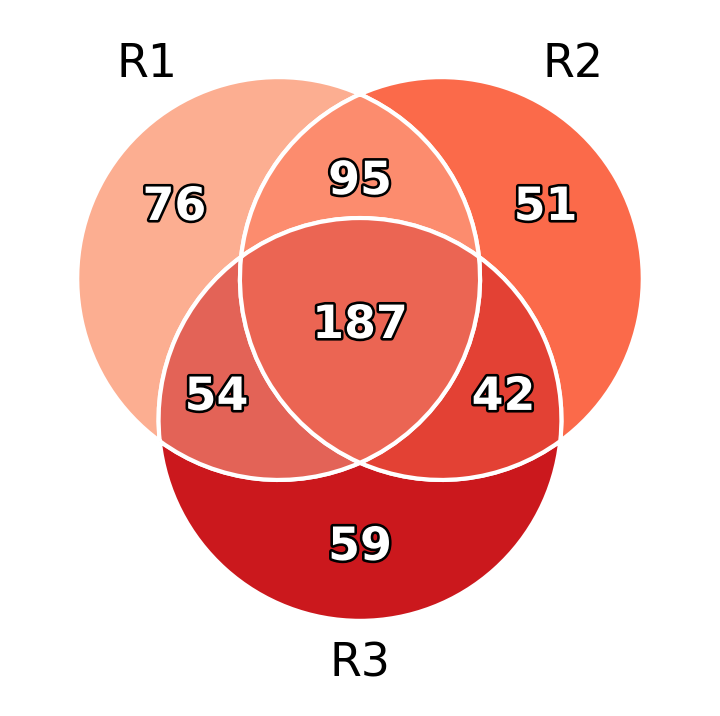

In [70]:
# DEIs vs initial -- how many are shared vs unique between R1, R2, and R3?
direction = 'down'

plot_df = sig[sig['transcript_type'] == 'protein_coding'].copy()
plot_df['direction'] = np.where(plot_df['logfoldchanges'] > 0, 'up', 'down')
plot_df = plot_df[plot_df['direction'] == direction]

r1_dei = plot_df[plot_df['group'] == 'R1']['names'].unique()
print(len(r1_dei))
r1_set = set(r1_dei)

r2_dei = plot_df[plot_df['group'] == 'R2']['names'].unique()
print(len(r2_dei))
r2_set = set(r2_dei)

r3_dei = plot_df[plot_df['group'] == 'R3']['names'].unique()
print(len(r3_dei))
r3_set = set(r3_dei)

group_names = ['R1', 'R2', 'R3']

colors_rgb = {
    'R1': mcolors.to_rgb('#FCAE91'),    
    'R2': mcolors.to_rgb('#FB6A4A'), 
    'R3': mcolors.to_rgb('#CB181D')      
}

def blend(colors):
    arr = np.array(colors)
    return tuple(arr.mean(axis=0))

venn_ids = {
    '100': ['R1'],
    '010': ['R2'],
    '001': ['R3'],
    '110': ['R1', 'R2'],
    '101': ['R1', 'R3'],
    '011': ['R2', 'R3'],
    '111': ['R1', 'R2', 'R3']
}

plt.rcdefaults()
plt.rcParams['figure.dpi'] = 300
plt.figure(figsize=(2.5, 2.5))

venn = venn3_unweighted(
    [r1_set, r2_set, r3_set],
    set_labels=group_names
)

for label in venn.set_labels:
        if label:
            label.set_fontsize(11)

for subset_id, sets in venn_ids.items():
    patch = venn.get_patch_by_id(subset_id)
    if patch:
        color = blend([colors_rgb[s] for s in sets])
        patch.set_facecolor(color)
        patch.set_edgecolor('white')
        patch.set_linewidth(1)
        patch.set_alpha(1)
    label = venn.get_label_by_id(subset_id)
    if label:
        label.set_text(f"{int(label.get_text()):,}")
        label.set_fontsize(11)
        label.set_fontweight('bold')
        label.set_horizontalalignment('center')
        label.set_verticalalignment('center')
        label.set_color('white')
        label.set_path_effects([
            path_effects.Stroke(linewidth=1.25, foreground='black'),
            path_effects.Normal()])
        
        x, y = label.get_position()
        offset = 0
        if subset_id == '101':  # nudge left
            offset = -0.04
        elif subset_id == '011': # nudge right
            offset = 0.04
        elif subset_id == '100':
            offset = 0.04
        elif subset_id == '010':
            offset = -0.04
        label.set_position((x + offset, y))
        if subset_id == '001':
            label.set_position((x, y + 0.03))

plt.tight_layout()
plt.show()

## n DEIs

filtering for protein_coding transcripts...


direction,down,up
group,,
R3,-342,962
R2,-375,474
R1,-412,650


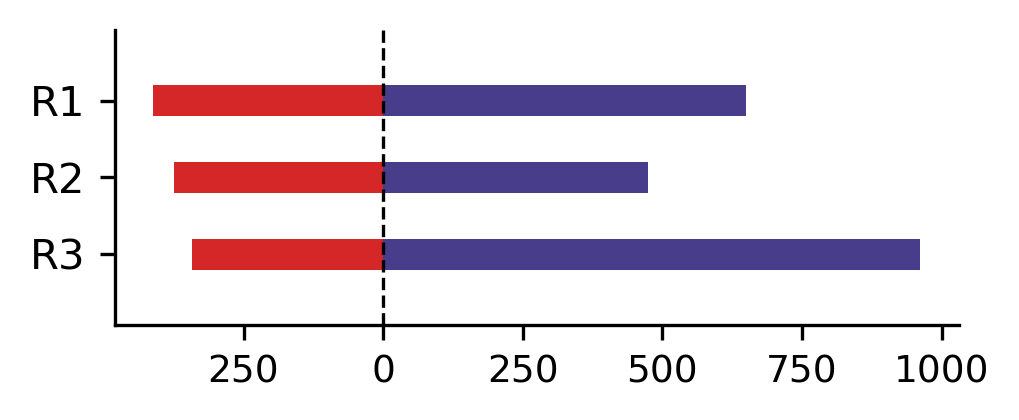

In [71]:
tmp = sig.copy()

# add regulation direction
tmp['direction'] = tmp['logfoldchanges'].apply(lambda x: 'up' if x > 0 else 'down')

# filter for transcript types of interest
transcript_type = 'protein_coding'

if transcript_type != 'all':
    tmp = tmp[tmp['transcript_type'] == transcript_type]
    print(f"filtering for {transcript_type} transcripts...")

counts = tmp.groupby(['group', 'direction'], observed=True).size().reset_index(name='count')
counts['count'] = counts.apply(lambda row: -row['count'] if row['direction'] == 'down' else row['count'], axis=1)
plot_df = counts.pivot(index='group', columns='direction', values='count').fillna(0)

plot_order = ['R3', 'R2', 'R1']
plot_df = plot_df.reindex(plot_order)
display(plot_df)

# plot
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 3.5, 1.5
fig, ax = plt.subplots()

bar_width = 0.4

ax.barh(plot_df.index, plot_df['up'], color='darkslateblue', label='Up', height=bar_width)
ax.barh(plot_df.index, plot_df['down'], color='tab:red', label='Down', height=bar_width)

ax.axvline(0, color='k', linewidth=0.8, ls='--')

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_yticks(range(len(plot_df.index)))
ax.set_yticklabels(plot_order)
ax.margins(y=0.3)

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: int(abs(x))))
ax.tick_params(axis='x', labelsize=9)

sns.despine()
plt.tight_layout()
plt.show()

# Get DEGs

In [59]:
%%time
fpath = "/scratch/indikar_root/indikar1/shared_data/hematokytos/new_processed/three_libraries_new.h5ad"

gdata = sc.read_h5ad(fpath)
gdata

CPU times: user 1.55 s, sys: 2 s, total: 3.55 s
Wall time: 16 s


AnnData object with n_obs × n_vars = 20754 × 26933
    obs: 'dataset', 'source', 'cluster_all', 'group', 'label', 'S_score', 'G2M_score', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'combined_clusters', 'subgroup'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'gene_id', 'gene_type', 'Chromosome', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_rank', 'variances', 'variances_norm', 'mito', 'filter_pass'
    uns: 'label_colors', 'label_deg', '

In [60]:
# C2 and C3 vs initial
sc.tl.rank_genes_groups(
    gdata, 
    groupby='label',
    groups=['R1', 'R2', 'R3'],
    reference='initial',
    method='wilcoxon',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='reprogram_vs_initial',
)

# C2 and C3 vs HSC
sc.tl.rank_genes_groups(
    gdata, 
    groupby='label',
    groups=['R1', 'R2', 'R3'],
    reference='HSC',
    method='wilcoxon',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='reprogram_vs_target',
)

ranking genes
    finished (0:01:15)
ranking genes
    finished (0:00:21)


In [64]:
gene_deg = sc.get.rank_genes_groups_df(
    gdata, 
    group=None,
    key='reprogram_vs_initial',
    # key='reprogram_vs_target',
)

gene_sig = get_significant_DEGs(gene_deg, logfc_thresh=0.5, pct_nz_thresh=0.3)
print(gene_sig.shape)

gene_sig['is_tf'] = gene_sig['names'].isin(tf_list)

print(f"N unique DEGs: {gene_sig['names'].nunique()}")

gene_sig.head()

Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
Removed upregaulted genes expressed in less than 30.0% of cells. Kept all downregulated genes.
(8222, 8)
N unique DEGs: 4352


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc,is_tf
0,R1,MGP,63.510269,7.321636,0.0,0.0,0.938035,7.321636,False
1,R1,S100A6,59.219219,1.383227,0.0,0.0,1.000000,1.383227,False
2,R1,KRT18,58.913879,5.125864,0.0,0.0,0.909824,5.125864,False
3,R1,CLU,57.556404,4.166980,0.0,0.0,0.924937,4.166980,False
4,R1,ELOB,55.320232,1.111048,0.0,0.0,0.990428,1.111048,False


In [65]:
gene_sig['direction'] = np.where(gene_sig['logfoldchanges'] > 0, 'up', 'down')

deg_subset = gene_sig[['group', 'names', 'logfoldchanges', 'direction']].copy()
deg_subset = deg_subset.rename(columns={'logfoldchanges': 'deg_logfc', 'direction': 'deg_direction', 'names': 'gene_name'})
print(deg_subset.shape)
deg_subset.head()

(8222, 4)


,group,gene_name,deg_logfc,deg_direction
0,R1,MGP,7.321636,up
1,R1,S100A6,1.383227,up
2,R1,KRT18,5.125864,up
3,R1,CLU,4.166980,up
4,R1,ELOB,1.111048,up


In [71]:
for g in deg_subset['group'].unique():
    tmp = deg_subset[deg_subset['group'] == g]
    print(f"N DEGs for {g}: {tmp['gene_name'].nunique()}")

N DEGs for R1: 2211
N DEGs for R2: 2495
N DEGs for R3: 3516


## Merge with DEIs

In [66]:
# merge with isoforms
idf = pd.merge(sig, deg_subset, how='left', on=['group', 'gene_name'])

idf['is_deg'] = idf['deg_logfc'].notna()

print(idf.shape)
idf.head()

(3538, 16)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,gene_name,abs_lfc,is_tf,gene_type,transcript_type,uniprot,deg_logfc,deg_direction,is_deg
0,R1,S100A6-201,62.194511,1.475699,0.0,0.0,0.999496,S100A6,1.475699,False,protein_coding,protein_coding,P06703,1.383227,up,True
1,R1,RPS27A-203,61.298794,3.307473,0.0,0.0,0.990932,RPS27A,3.307473,False,protein_coding,protein_coding,NaN,NaN,NaN,False
2,R1,COX7A2-202,60.817127,4.788902,0.0,0.0,0.983375,COX7A2,4.788902,False,protein_coding,protein_coding,NaN,NaN,NaN,False
3,R1,S100A6-202,59.086998,3.932034,0.0,0.0,0.925441,S100A6,3.932034,False,protein_coding,protein_coding,NaN,1.383227,up,True
4,R1,TXNDC17-201,58.758808,3.702158,0.0,0.0,0.946599,TXNDC17,3.702158,False,protein_coding,protein_coding,Q9BRA2,0.659813,up,True


In [67]:
# how many GENES with DEIs are DEGs
for g in idf['group'].unique():
    print(f"{g}:")
    tmp = idf[idf['group'] == g]
    tmp = tmp.drop_duplicates(subset='gene_name')
    print(tmp['is_deg'].value_counts())

R1:
is_deg
True     676
False    374
Name: count, dtype: int64
R2:
is_deg
True     582
False    269
Name: count, dtype: int64
R3:
is_deg
True     872
False    424
Name: count, dtype: int64


# Plots

## DEIs that are DEGs

In [69]:
counts = []

for group, df in idf.groupby('group'):
    # number of DEIs
    num_deis = df['names'].nunique()
    
    # number of genes the DEIs encode
    num_genes = df['gene_name'].nunique()
    
    # genes that are DE at the gene-level
    num_genes_deg = df[df['is_deg']]['gene_name'].nunique()
    
    counts.append({
        'group': group,
        'num_DEIs': num_deis,
        'num_genes': num_genes,
        'num_DE_genes': num_genes_deg
    })
    
counts = pd.DataFrame(counts)
counts['pct_DE_genes'] = counts['num_DE_genes'] / counts['num_genes']
counts

,group,num_DEIs,num_genes,num_DE_genes,pct_DE_genes
0,R1,1165,1050,676,0.643810
1,R2,942,851,582,0.683901
2,R3,1431,1296,872,0.672840


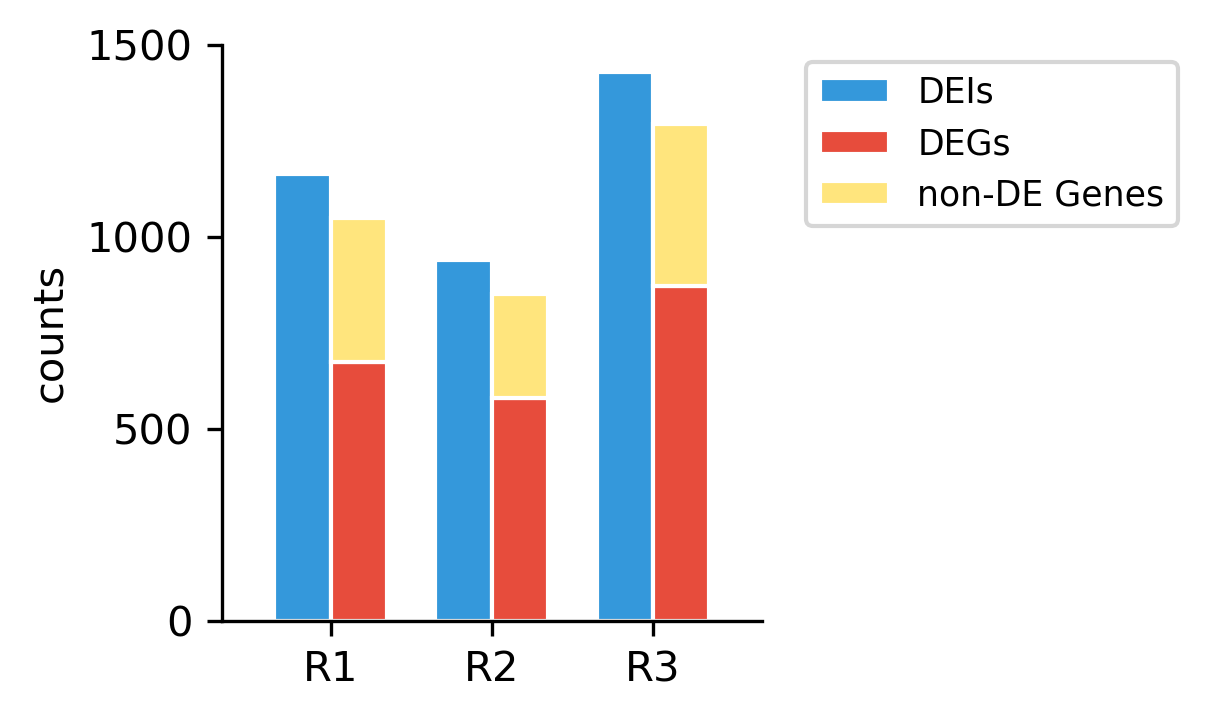

In [70]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4.2, 2.5
fig, ax = plt.subplots()

groups = counts['group']
ind = np.arange(len(groups))

width = 0.35 # bar width

# Bars
# 1. num_DE_transcripts (side by side)
bar1 = plt.bar(
    ind - width/2,
    counts['num_DEIs'],
    width,
    label='DEIs',
    color='#3498db',
    ec='white', lw=1,
)

# 2. num_DE_genes (stacked on portion of num_genes)
bar2 = plt.bar(
    ind + width/2,
    counts['num_DE_genes'],
    width,
    label='DEGs',
    color='#e74c3c',
    ec='white', lw=1,
)
bar3 = plt.bar(
    ind + width/2,
    counts['num_genes'] - counts['num_DE_genes'],
    width, 
    bottom=counts['num_DE_genes'],
    label='non-DE Genes',
    color='#FFE57D',#'#f9e79f',
    ec='white', lw=1,
)

plt.xticks(ind, groups)
plt.ylabel('counts')
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize='small')

ax = plt.gca()
ax.margins(x=0.12)

sns.despine()
plt.tight_layout()
plt.show()

,group,num_DEGs
0,R1,2211
1,R2,2495
2,R3,3516


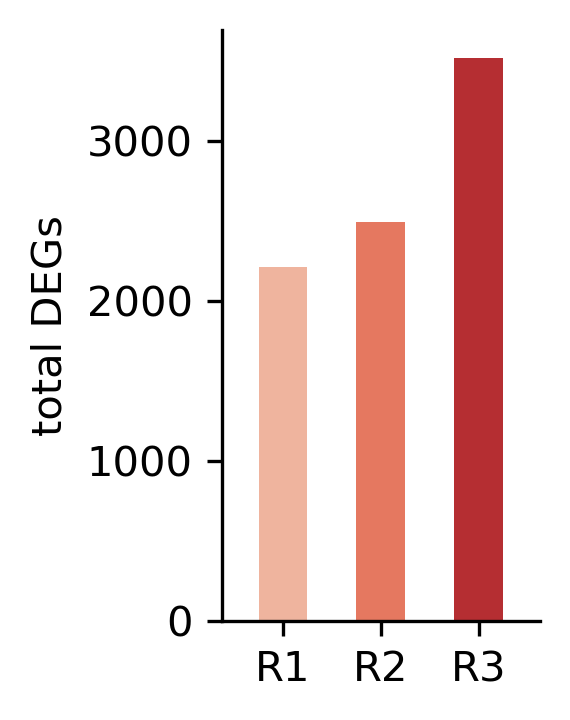

In [78]:
# get total DEGs

gene_counts = []

for group, df in deg_subset.groupby('group'):
    # number of DEIs
    num_degs = df['gene_name'].nunique()
    
    gene_counts.append({
        'group': group,
        'num_DEGs': num_degs,
    })
    
gene_counts = pd.DataFrame(gene_counts)
display(gene_counts)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 2, 2.5

sns.barplot(
    data=gene_counts,
    x='group',
    y='num_DEGs',
    hue='group',
    palette=['#FCAE91', '#FB6A4A', '#CB181D'],
    width=0.5,
)
             
plt.ylabel("total DEGs")
plt.xlabel("")

ax = plt.gca()
ax.margins(x=0.15)

sns.despine()
plt.tight_layout()
plt.show()

In [81]:
idf.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,gene_name,abs_lfc,is_tf,gene_type,transcript_type,uniprot,deg_logfc,deg_direction,is_deg
0,R1,S100A6-201,62.194511,1.475699,0.0,0.0,0.999496,S100A6,1.475699,False,protein_coding,protein_coding,P06703,1.383227,up,True
1,R1,RPS27A-203,61.298794,3.307473,0.0,0.0,0.990932,RPS27A,3.307473,False,protein_coding,protein_coding,B2RDW1,NaN,NaN,False
2,R1,COX7A2-202,60.817127,4.788902,0.0,0.0,0.983375,COX7A2,4.788902,False,protein_coding,protein_coding,H0UI06,NaN,NaN,False
3,R1,S100A6-202,59.086998,3.932034,0.0,0.0,0.925441,S100A6,3.932034,False,protein_coding,protein_coding,P06703,1.383227,up,True
4,R1,TXNDC17-201,58.758808,3.702158,0.0,0.0,0.946599,TXNDC17,3.702158,False,protein_coding,protein_coding,A0A140VJY7,0.659813,up,True


In [79]:
# filter for non-DEGs
jdf = idf[~idf['is_deg']]
# jdf = jdf[jdf['uniprot'].notna()]
jdf = jdf[~jdf['gene_name'].str.startswith(('MT-', 'RP'))]

# jdf = jdf[jdf['is_tf']]

print(jdf.shape)
jdf.head()

(1076, 16)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,gene_name,abs_lfc,is_tf,gene_type,transcript_type,uniprot,deg_logfc,deg_direction,is_deg
2,R1,COX7A2-202,60.817127,4.788902,0.0,0.0,0.983375,COX7A2,4.788902,False,protein_coding,protein_coding,NaN,NaN,NaN,False
13,R1,MIR4435-2HG-225,56.549683,4.196143,0.0,0.0,0.905793,MIR4435,4.196143,False,NaN,NaN,NaN,NaN,NaN,False
14,R1,ATP5MF-203,56.514111,4.004274,0.0,0.0,0.929471,ATP5MF,4.004274,False,protein_coding,protein_coding,NaN,NaN,NaN,False
17,R1,RACK1-210,54.864330,3.821899,0.0,0.0,0.953652,RACK1,3.821899,False,protein_coding,nonsense_mediated_decay,D6R909,NaN,NaN,False
19,R1,CD63-201,54.586315,4.734170,0.0,0.0,0.980353,CD63,4.734170,False,protein_coding,protein_coding,P08962,NaN,NaN,False


In [80]:
jdf['n_iso'] = jdf.groupby('gene_name')['names'].transform('nunique')
jdf.head()


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,gene_name,abs_lfc,is_tf,gene_type,transcript_type,uniprot,deg_logfc,deg_direction,is_deg,n_iso
2,R1,COX7A2-202,60.817127,4.788902,0.0,0.0,0.983375,COX7A2,4.788902,False,protein_coding,protein_coding,NaN,NaN,NaN,False,1
13,R1,MIR4435-2HG-225,56.549683,4.196143,0.0,0.0,0.905793,MIR4435,4.196143,False,NaN,NaN,NaN,NaN,NaN,False,2
14,R1,ATP5MF-203,56.514111,4.004274,0.0,0.0,0.929471,ATP5MF,4.004274,False,protein_coding,protein_coding,NaN,NaN,NaN,False,2
17,R1,RACK1-210,54.864330,3.821899,0.0,0.0,0.953652,RACK1,3.821899,False,protein_coding,nonsense_mediated_decay,D6R909,NaN,NaN,False,2
19,R1,CD63-201,54.586315,4.734170,0.0,0.0,0.980353,CD63,4.734170,False,protein_coding,protein_coding,P08962,NaN,NaN,False,2


In [81]:
jdf.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,gene_name,abs_lfc,is_tf,gene_type,transcript_type,uniprot,deg_logfc,deg_direction,is_deg,n_iso
2,R1,COX7A2-202,60.817127,4.788902,0.0,0.0,0.983375,COX7A2,4.788902,False,protein_coding,protein_coding,NaN,NaN,NaN,False,1
13,R1,MIR4435-2HG-225,56.549683,4.196143,0.0,0.0,0.905793,MIR4435,4.196143,False,NaN,NaN,NaN,NaN,NaN,False,2
14,R1,ATP5MF-203,56.514111,4.004274,0.0,0.0,0.929471,ATP5MF,4.004274,False,protein_coding,protein_coding,NaN,NaN,NaN,False,2
17,R1,RACK1-210,54.864330,3.821899,0.0,0.0,0.953652,RACK1,3.821899,False,protein_coding,nonsense_mediated_decay,D6R909,NaN,NaN,False,2
19,R1,CD63-201,54.586315,4.734170,0.0,0.0,0.980353,CD63,4.734170,False,protein_coding,protein_coding,P08962,NaN,NaN,False,2


In [82]:
jdf.groupby('group')['gene_name'].nunique()

group
R1    341
R2    239
R3    396
Name: gene_name, dtype: int64

In [83]:
# jdf = jdf.sort_values(by=['logfoldchanges', 'group'], ascending=[False, True])
jdf = jdf.sort_values(by=['n_iso', 'logfoldchanges'], ascending=[False, False])

jdf['gene_name'].unique().tolist()[:50]

['MT',
 'H1',
 'IGFL2',
 'PFDN5',
 'HP1BP3',
 'SEC61G',
 'ZFAS1',
 'SNHG29',
 'SSBP1',
 'ANAPC11',
 'HLA',
 'CD63',
 'MIR4435',
 'SNRPG',
 'LIMA1',
 'ATP5MF',
 'RACK1',
 'TPM3',
 'EZR',
 'TXNDC17',
 'EMP3',
 'LMNA',
 'ALDOA',
 'PAFAH1B1',
 'DDX17',
 'CALM2',
 'COX4I1',
 'UCHL1',
 'JUND',
 'TEAD1',
 'FAM177A1',
 'OTUD6B',
 'MORF4L1',
 'TPT1',
 'EIF1',
 'UXT',
 'SNHG6',
 'GLS',
 'DRAP1',
 'ENST00000654602',
 'COX7A2',
 'CYTOR',
 'TMPO',
 'ENST00000702574',
 'HSPD1',
 'TRIM25',
 'ENST00000603981',
 'EEF1B2',
 'ELOC',
 'CAST']

In [84]:
fpath = "../resources/clean_marker_genes.csv"
mdf = pd.read_csv(fpath)
mdf.head()

,gene_name,cell_type,is_tf,source,category
0,TSPAN8,endothelial_cells,False,panglao,endothelial
1,KLK1,endothelial_cells,False,panglao,endothelial
2,RNASE1,endothelial_cells,False,panglao,endothelial
3,LUM,endothelial_cells,False,panglao,endothelial
4,LOX,endothelial_cells,False,panglao,endothelial


In [88]:
tfs = jdf[jdf['is_tf']]['gene_name'].unique()
print(len(tfs))
print(f"{', '.join(tfs)}")

44
HP1BP3, EZR, JUND, TEAD1, DRAP1, RBM3, PPP5C, RNASEH2C, CHURC1, CNOT4, HNRNPA1, HMGB3, SMC3, HMGA2, PURA, CDK2AP1, RB1, CYCS, FOS, ZNF232, ZMAT2, TSNAX, NFIX, ANXA1, TMEM33, UQCRB, TBX3, YWHAE, RAB7A, SP2, NAP1L1, HMGB1, GTF2A2, SF3B1, PARP1, CSNK2B, CREB3L2, YY1, ILF2, TWIST1, RBMS1, LRRFIP1, SMARCC1, KLF6


In [86]:
gene_lists = {
    "R1": list(jdf[jdf['group'] == 'R1']['gene_name'].unique()),
    "R2": list(jdf[jdf['group'] == 'R2']['gene_name'].unique()),
    "R3": list(jdf[jdf['group'] == 'R3']['gene_name'].unique()),
}

categories = ["fibroblast", "endothelial", "hematopoietic"]

for list_name, gene_list in gene_lists.items():
    print(f"\n{list_name}:")
    
    # subset matching genes
    subset = mdf[mdf["gene_name"].isin(gene_list)]
    
    # group by category and list sorted gene names
    for cat in categories:
        genes = sorted(subset.loc[subset["category"] == cat, "gene_name"].unique())
        if genes:
            print(f"{cat.capitalize()}: {', '.join(genes)}")


R1:
Fibroblast: ANXA1, CD63, COL1A1, CTSL, DDR2, DDX17, DDX5, EEF1A1, EIF1, FOS, HSP90AB1, HSPA1A, HSPA1B, IL1R1, IL6ST, JUND, LGALS1, LIMA1, LMNA, MFGE8, MT2A, MYL6, NID1, PLIN2, RACK1, SOD2, TIMP1, TPT1
Endothelial: CD63, COL1A1, CTSL, DDX17, DDX5, DSTN, EEF1A1, EEF1B2, EIF1, FLNA, FOS, GPX1, HSP90AB1, HSPA1A, HSPA1B, IL6ST, ITGA5, ITGB1, JUND, LDHA, MT2A, MYL12A, MYL6, RACK1, SOD2, SRP14, TIMP1, TPT1
Hematopoietic: ANPEP, CDH2, EEF1A1, EEF1B2, EIF1, FOS, GPX1, H4C3, HNRNPA1, HSP90AB1, JUND, RACK1, TPT1

R2:
Fibroblast: ANXA1, CD63, CD81, DDR2, DDX17, DDX5, FKBP10, FOS, GAPDH, HSP90AB1, HSPA1B, HTRA1, JUND, LIMA1, MT2A, PLIN2, RACK1, SERF2, TIMP1, TPT1
Endothelial: ATP5F1E, CD63, CD81, DDX17, DDX5, DSTN, EEF1B2, EHD2, FAM114A1, FOS, GAPDH, HSP90AB1, HSPA1B, HTRA1, ITGA5, ITGB1, JUND, MT2A, RACK1, SERF2, TIMP1, TPT1
Hematopoietic: ANPEP, ATP5F1E, EEF1B2, FOS, GAPDH, HNRNPA1, HSP90AB1, JUND, RACK1, TPT1

R3:
Fibroblast: ANXA1, ANXA5, CD63, COL1A1, DDR2, DDX17, DDX5, EIF1, HSP90AA1, HS

In [104]:
query = 'CALD1'
jdf[jdf['gene_name'] == query]

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,gene_name,abs_lfc,is_tf,gene_type,transcript_type,uniprot,deg_logfc,deg_direction,is_deg,n_iso


In [87]:
gene_deg[gene_deg['names'] == query]

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group
26012,R1,TEAD1,-15.647255,-0.582426,3.468643e-55,5.977028e-54,0.674559
52444,R2,TEAD1,-16.692644,-0.508732,1.482581e-62,1.431709e-61,0.674994
61758,R3,TEAD1,1.428392,0.063590,1.531790e-01,3.967405e-01,0.843511


In [ ]:
# check if this is the case for many of these genes. If not, can just go grab CD24 counts

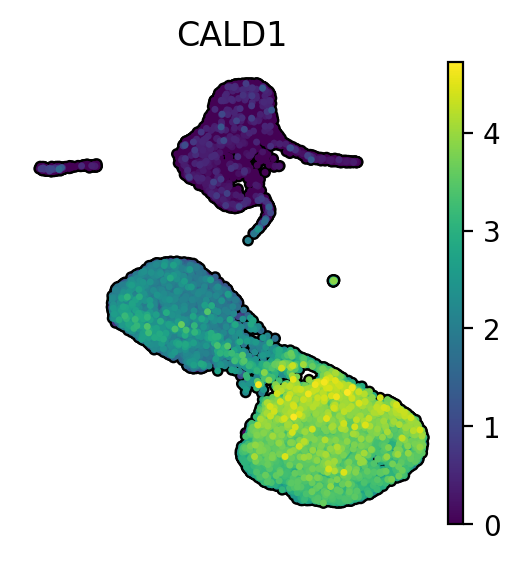

In [105]:
# query = ['CD63']

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

sc.pl.umap(
    gdata,
    color=query,
    size=25,
    ncols=4,
    alpha=1,
    use_raw=False,
    layer='log_norm',
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
)

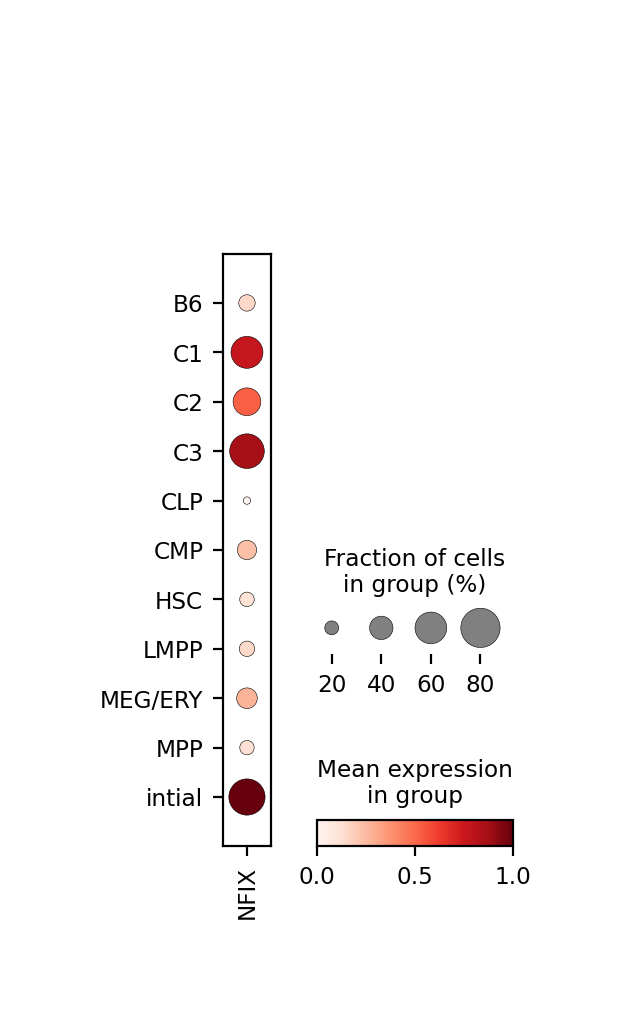

In [185]:
sc.pl.dotplot(
    gdata,
    var_names=query,
    groupby='label',
    standard_scale='var',
)

In [89]:
def get_transcripts(query, adata=adata):

    df = adata.var[adata.var['gene_name'] == query].copy()

    columns = [
        'gene_name',
        'gene_type',
        'transcript_name',
        'transcript_type',
        'uniprot',
    ]

    df = df[columns]

    return df

gene_name      gene_type transcript_name                transcript_type    uniprot
    CALD1 protein_coding       CALD1-201                 protein_coding     Q05682
    CALD1 protein_coding       CALD1-202                 protein_coding A0A140VKA0
    CALD1 protein_coding       CALD1-203                 protein_coding     Q05682
    CALD1 protein_coding       CALD1-205                 protein_coding     Q05682
    CALD1 protein_coding       CALD1-206                 protein_coding     Q05682
    CALD1 protein_coding       CALD1-207        nonsense_mediated_decay     F8WE61
    CALD1 protein_coding       CALD1-208                 protein_coding     C9JE79
    CALD1 protein_coding       CALD1-210        nonsense_mediated_decay     E9PGZ1
    CALD1 protein_coding       CALD1-214                 protein_coding A0A6Q8PGI1
    CALD1 protein_coding       CALD1-215                retained_intron        NaN
    CALD1 protein_coding       CALD1-217                retained_intron        NaN
    

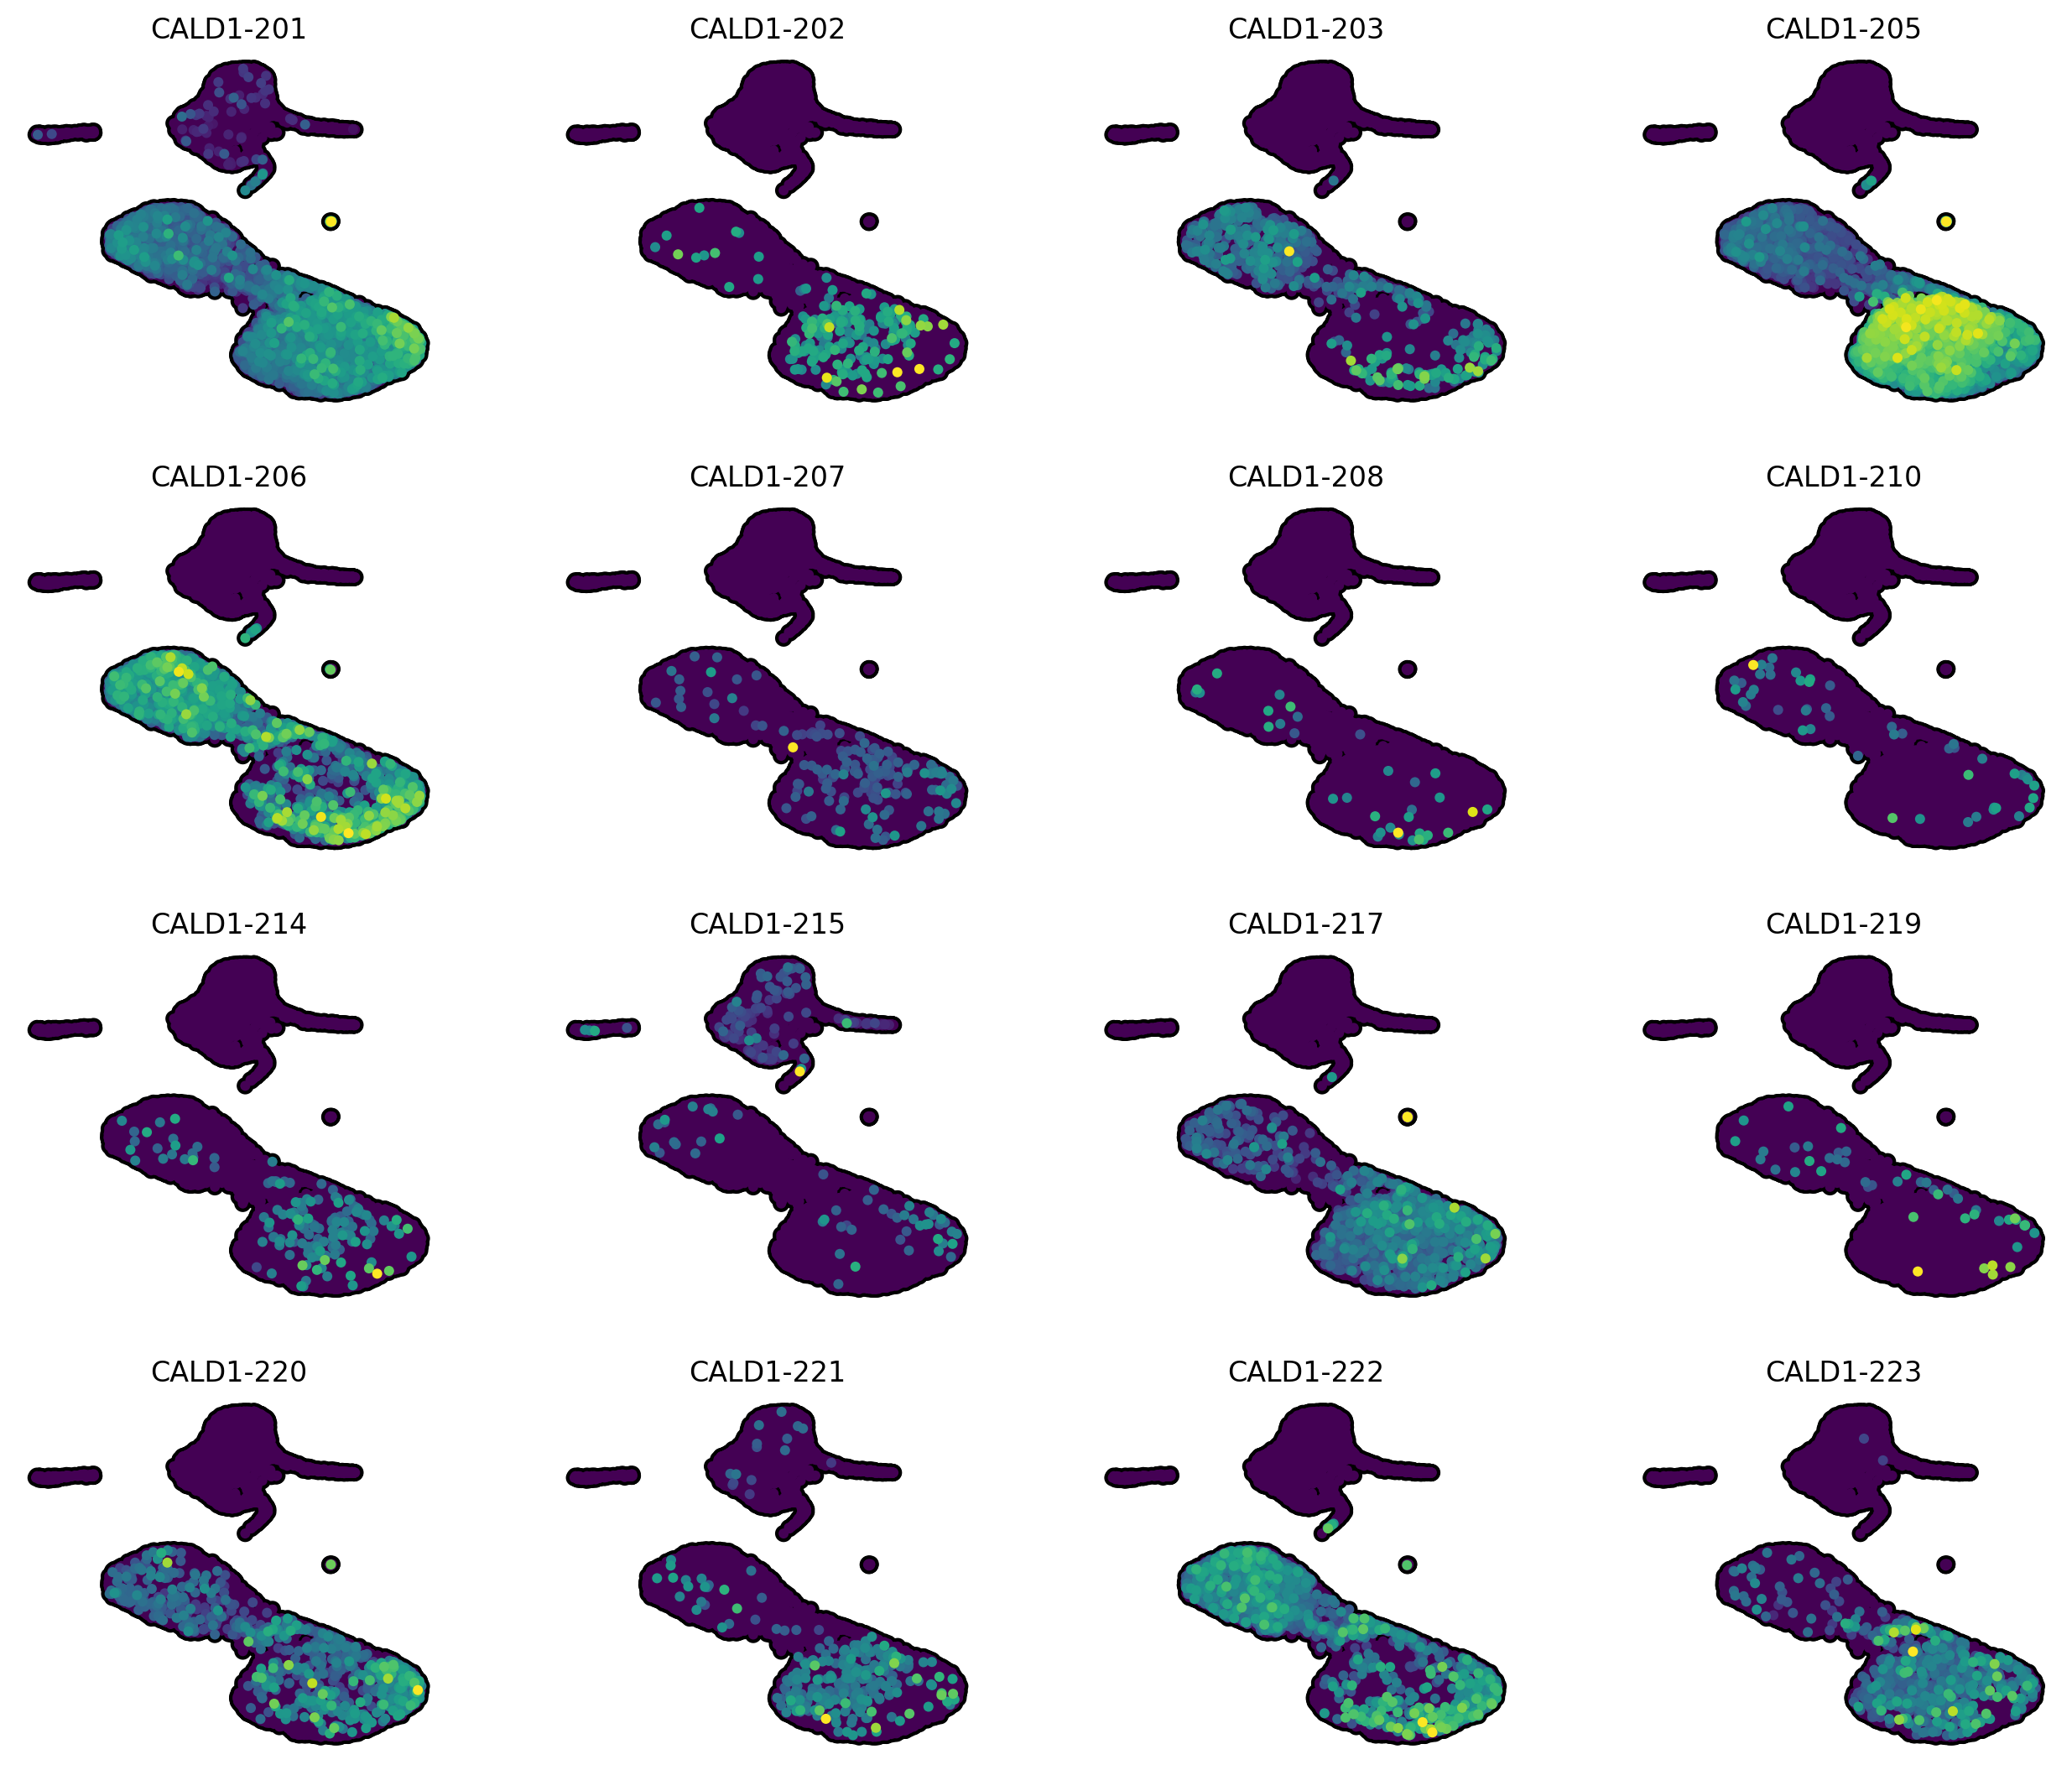

In [106]:
query = 'CALD1'
label_df = get_transcripts(query)
print(label_df.to_string(index=False))

color = label_df.index.to_list()

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

sc.pl.umap(
    adata,
    ncols=4,
    sort_order=True,
    color=color,
    size=75,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    cmap='viridis',
    colorbar_loc=None,
    frameon=False,
    layer='log_norm',
)

In [91]:
adata.obs['subgroup'].value_counts()

subgroup
initial        8464
R2             4323
progenitors    3952
R1             1985
HSC            1506
R3              524
Name: count, dtype: int64

In [107]:
adata.X = adata.layers["counts"].copy()

rsc.get.anndata_to_GPU(adata)
print(f"{type(adata.X)=}")

bdata = rsc.get.aggregate(
    adata, 
    by='subgroup',
    func='sum',
    axis=0,
)

rsc.get.anndata_to_CPU(bdata, convert_all=True,)

print(bdata.shape)

bdata.X = bdata.layers['sum'].copy()

sc.pp.normalize_total(bdata, target_sum=1e4)
sc.pp.log1p(bdata)

bdata.layers['log_norm'] = bdata.X.copy()


cond_order = ['initial', 'R1', 'R2', 'R3', 'HSC']
    
bdata = bdata[cond_order, color].copy()
print(bdata.shape)

df = bdata.to_df()

# compute gene-wise z-score
df_z = df.apply(zscore, axis=0)

df_z.head()

type(adata.X)=<class 'cupyx.scipy.sparse._csr.csr_matrix'>
(6, 69341)
normalizing counts per cell
    finished (0:00:00)
(5, 16)


transcript_name,CALD1-201,CALD1-202,CALD1-203,CALD1-205,CALD1-206,CALD1-207,CALD1-208,CALD1-210,CALD1-214,CALD1-215,CALD1-217,CALD1-219,CALD1-220,CALD1-221,CALD1-222,CALD1-223
initial,1.525682,1.969674,-0.892960,1.969274,-0.873152,1.598654,0.851641,-0.638899,1.833673,-0.075873,1.904884,-0.219267,0.265130,1.974284,-0.925990,1.314528
R1,0.434505,-0.215383,1.058052,-0.295877,0.877930,0.710170,1.230930,1.301612,0.135080,-1.169798,0.040103,1.890048,1.683044,-0.297665,0.897174,1.121487
R2,-0.141143,-0.457992,0.643562,-0.399617,0.898402,-0.493798,-0.578230,0.098057,-0.401409,-0.311618,-0.427324,-0.169745,-0.373542,-0.410017,0.956585,-0.742829
R3,-0.273472,-0.538506,0.677805,-0.458751,0.609506,-0.751037,0.052083,0.759486,-0.444566,-0.297491,-0.625504,-0.415650,-0.188233,-0.780513,0.534161,-0.726076
HSC,-1.545572,-0.757792,-1.486458,-0.815029,-1.512686,-1.063989,-1.556424,-1.520257,-1.122778,1.854780,-0.892158,-1.085386,-1.386400,-0.486089,-1.461929,-0.967110


In [46]:
df.head()

transcript_name,CD63-201,CD63-202,CD63-204,CD63-205,CD63-206,CD63-208,CD63-210,CD63-213,CD63-214,CD63-216
intial,1.485144,0.017773,0.026679,0.009342,0.003077,0.116379,0.001400,0.010452,3.122165,0.000000
C2,3.204146,0.178380,0.199067,0.014175,0.021188,0.220970,0.026664,0.000510,0.504218,0.000000
C3,3.016291,0.120900,0.154767,0.017230,0.016330,0.164902,0.021715,0.000000,0.357284,0.000000
HSC,1.232505,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001993


In [57]:
df.quantile(0.5)

transcript_name
CD63-201    2.250718
CD63-202    0.069337
CD63-204    0.090723
CD63-205    0.011759
CD63-206    0.009704
CD63-208    0.140640
CD63-210    0.011557
CD63-213    0.000255
CD63-214    0.430751
CD63-216    0.000000
Name: 0.5, dtype: float64

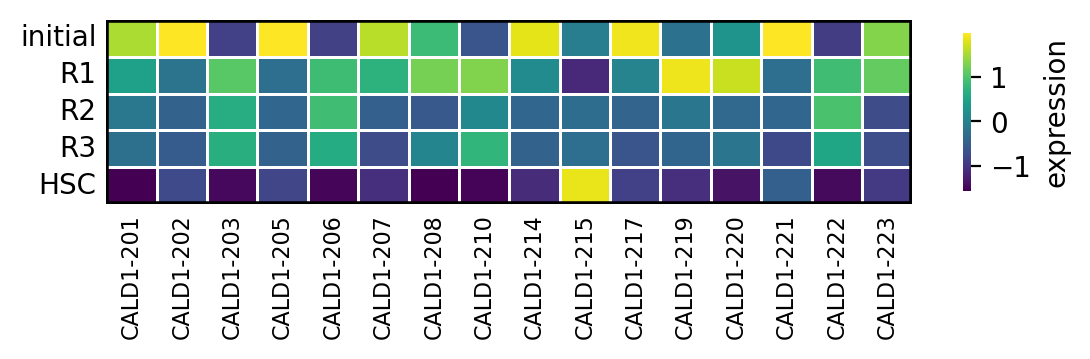

In [109]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6.5, 1.2

fig, ax = plt.subplots()

sns.heatmap(
    df_z,
    # df,
    cmap='viridis',
    # center=0,
    # vmin=-1,
    # vmax=1,
    lw=0.5,
    linecolor='white',
    cbar_kws={'label':'expression', 'shrink': 0.85, 'pad': 0.05},
    ax=ax,
)

plt.xlabel("")
ax.tick_params(axis='both', bottom=False, left=False, pad=0.05)

n_rows, n_cols = df_z.shape
ax.set_xticks(np.arange(n_cols) + 0.5)
ax.set_xticklabels(df_z.columns, rotation=90, fontsize=8)


# Add black box around matrix
n_rows, n_cols = df_z.shape
rect = patches.Rectangle(
    (0, 0), n_cols, n_rows,
    linewidth=2, edgecolor='black', facecolor='none', zorder=10
)
ax.add_patch(rect)

plt.show()

In [71]:
df.head()

transcript_name,CD63-201,CD63-202,CD63-204,CD63-205,CD63-206,CD63-208,CD63-210,CD63-213,CD63-214,CD63-216
intial,1.485144,0.017773,0.026679,0.009342,0.003077,0.116379,0.001400,0.010452,3.122165,0.000000
C2,3.204146,0.178380,0.199067,0.014175,0.021188,0.220970,0.026664,0.000510,0.504218,0.000000
C3,3.016291,0.120900,0.154767,0.017230,0.016330,0.164902,0.021715,0.000000,0.357284,0.000000
HSC,1.232505,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001993


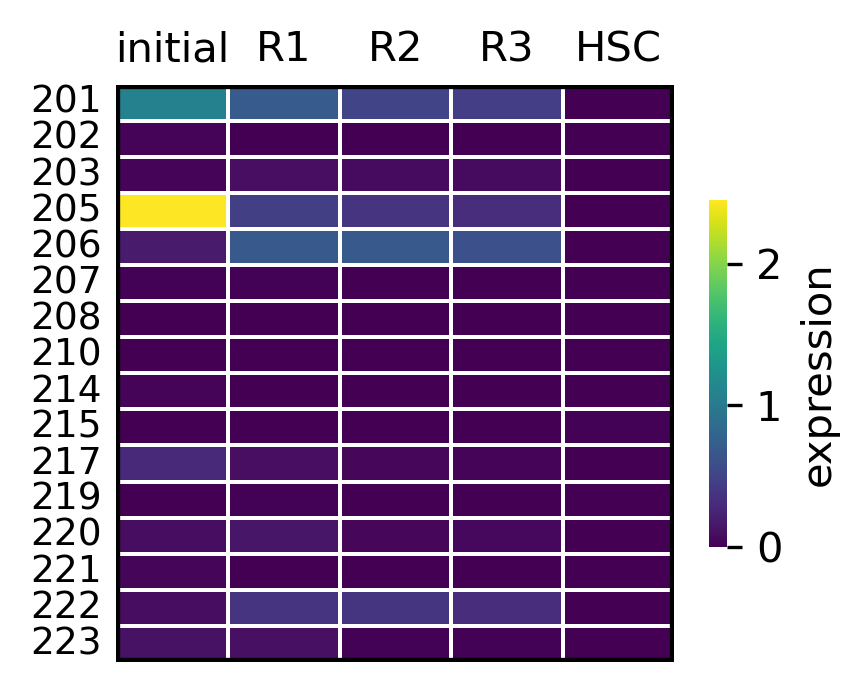

In [110]:
# label_map = {
#     'intial': 'initial',
#     'C2': 'C2',
#     'C3': 'C3',
#     'HSC': 'HSC',
# }

df.columns = df.columns.str.split('-').str[-1]

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 3, 2.5

fig, ax = plt.subplots()

sns.heatmap(
    df.T,
    cmap='viridis',
    lw=0.5,
    linecolor='white',
    cbar_kws={'label':'expression', 'shrink': 0.6, 'pad': 0.05},
    ax=ax,
)

plt.ylabel("")

n_rows, n_cols = df.shape
ax.set_yticks(np.arange(n_cols) + 0.5)
ax.set_yticklabels(df.columns, rotation=0, fontsize=9)

ax.set_xticks(np.arange(len(cond_order)) + 0.5)
ax.set_xticklabels(cond_order)
# ax.set_xticklabels([label_map.get(g, g) for g in cond_order])

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

ax.tick_params(axis='both', bottom=False, left=False, top=False, pad=0.05)

# Add black box around matrix
n_rows, n_cols = df.T.shape
rect = patches.Rectangle(
    (0, 0), n_cols, n_rows,
    linewidth=2, edgecolor='black', facecolor='none', zorder=10
)
ax.add_patch(rect)

plt.show()

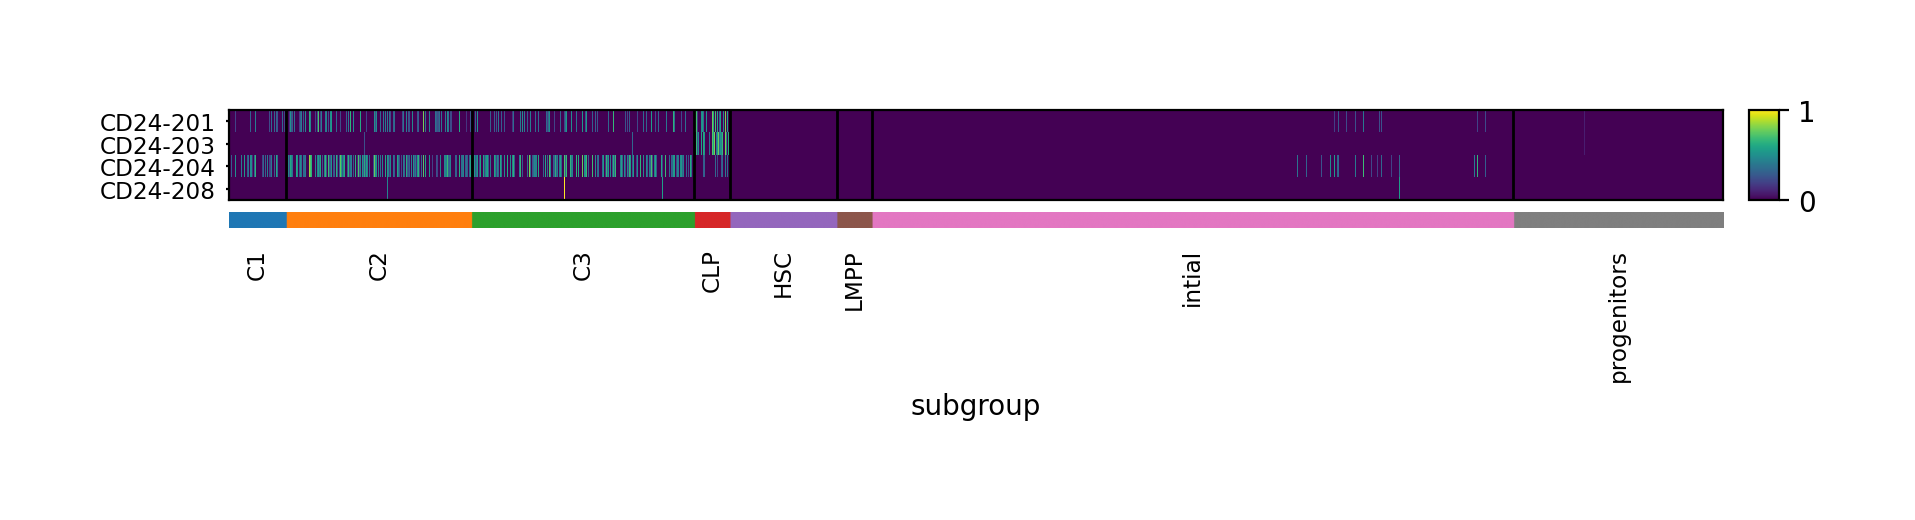

In [35]:
sc.pl.heatmap(
    adata,
    var_names=color,
    groupby='subgroup',
    standard_scale='var',
    layer='log_norm',
    swap_axes=True,
)

## DEI types

[Text(0, 0.85, '0.0'),
 Text(0, 0.9, '0.9'),
 Text(0, 0.95, '0.95'),
 Text(0, 1.0, '1.0')]

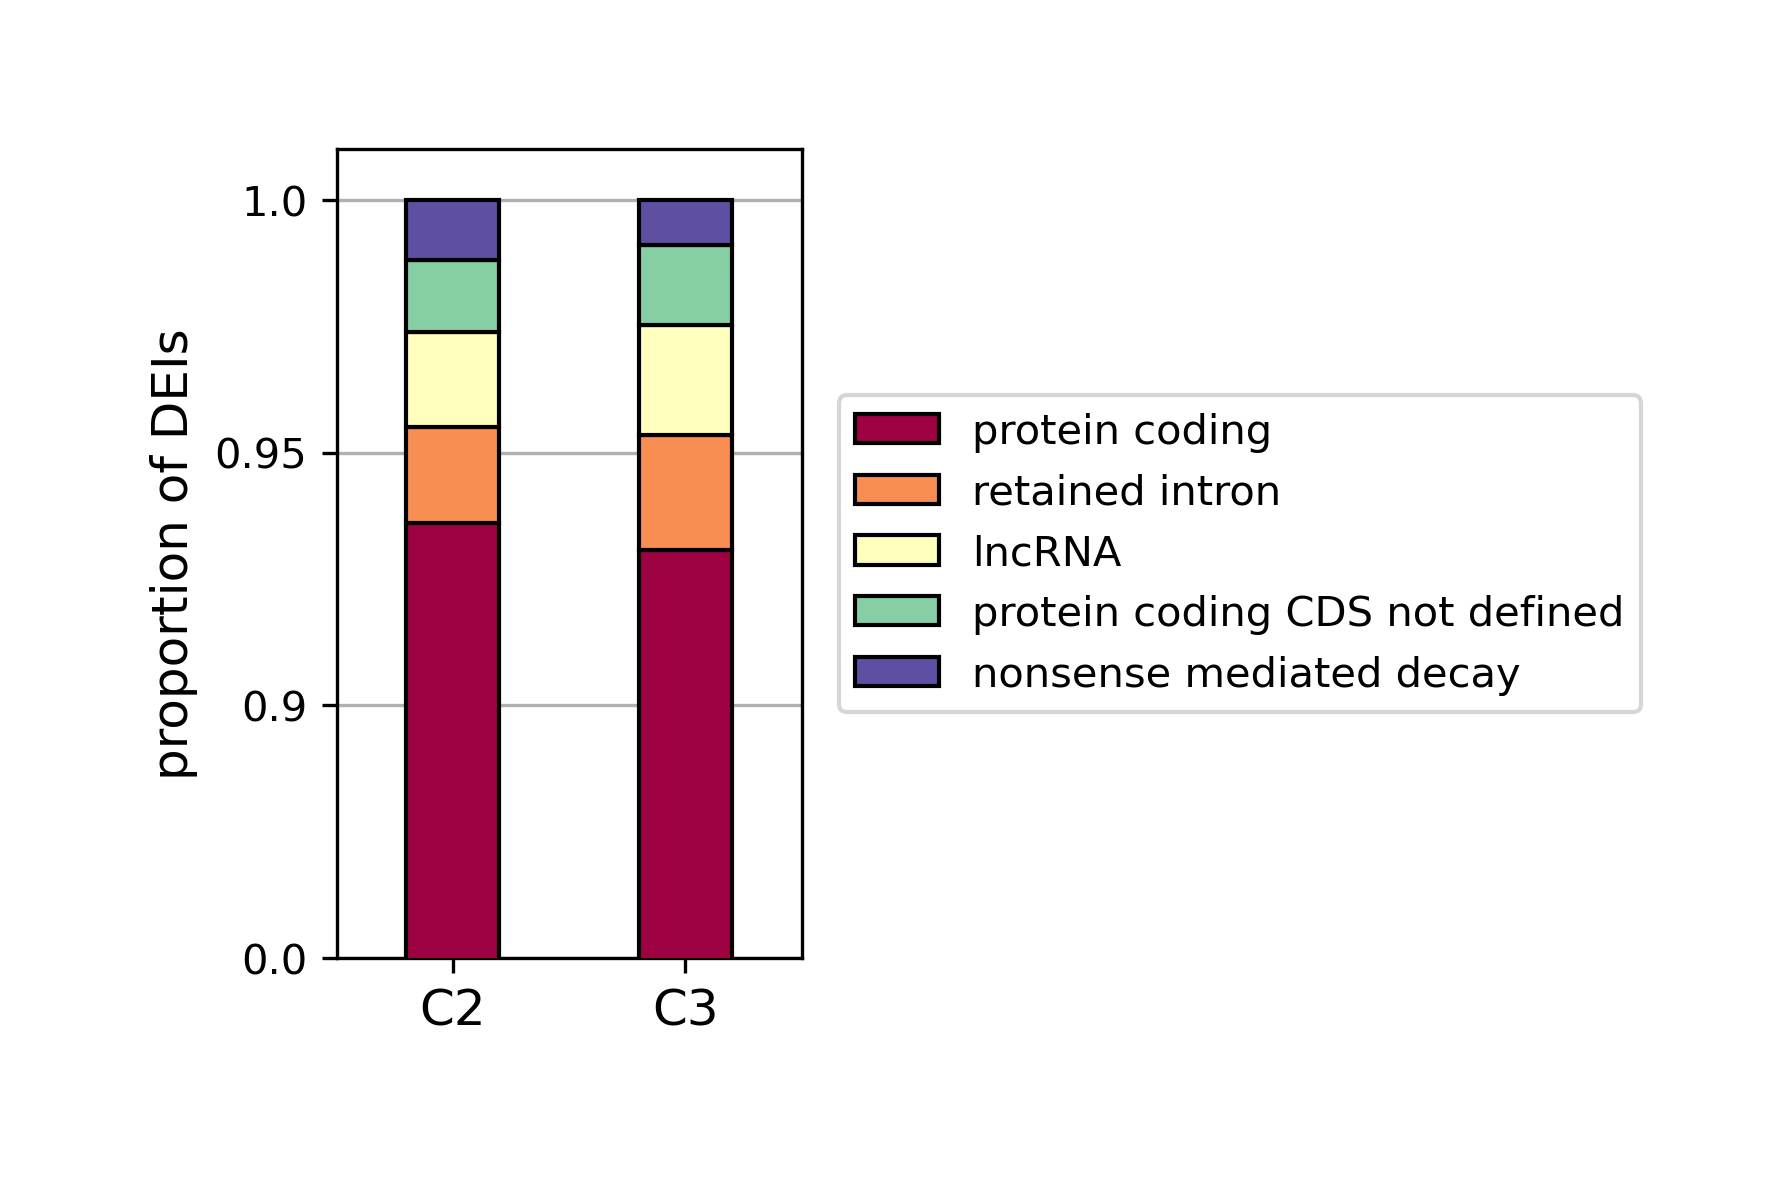

In [126]:
keep = [
    'retained_intron',
    'protein_coding_CDS_not_defined',
    'lncRNA',
    'protein_coding',
    'nonsense_mediated_decay',
]

proportions = {}

for group in idf['group'].unique():
    tmp = idf[idf['group'] == group].copy()
    mask = tmp['transcript_type'].isin(keep)
    cnts = tmp.loc[mask, 'transcript_type'].value_counts(normalize=True)
    cnts.index = cnts.index.str.replace("_", " ")
    proportions[group] = cnts
    
result = pd.DataFrame(proportions).fillna(0)
result = result.loc[(result != 0).any(axis=1)]
result

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 2, 3.5
result.T.plot(
    kind='bar',
    stacked=True,
    ec='k',
    zorder=10,
    cmap='Spectral',
    width=0.4,
)

plt.grid(axis='y', zorder=0)
sns.move_legend(
    plt.gca(),
    loc='center right',
    title='',
    bbox_to_anchor=(2.85, 0.5)
)
plt.ylabel(f'proportion of DEIs', fontsize=12)

lower_lim = 0.85
plt.ylim([lower_lim, 1.01])
n_ticks = 4  # Set as needed
yticks = np.linspace(lower_lim, 1.0, n_ticks)
yticklabels = [f"{round(t, 3)}" for t in yticks]

ax = plt.gca()
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, rotation=0)
plt.xlim(-0.5, len(result.columns)-0.5)
yticklabels[0] = 0.0    # set lowest label manually
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)

In [127]:
result

,C2,C3
transcript_type,,
protein coding,0.936019,0.930762
retained intron,0.018957,0.022750
lncRNA,0.018957,0.021761
protein coding CDS not defined,0.014218,0.015826
nonsense mediated decay,0.011848,0.008902


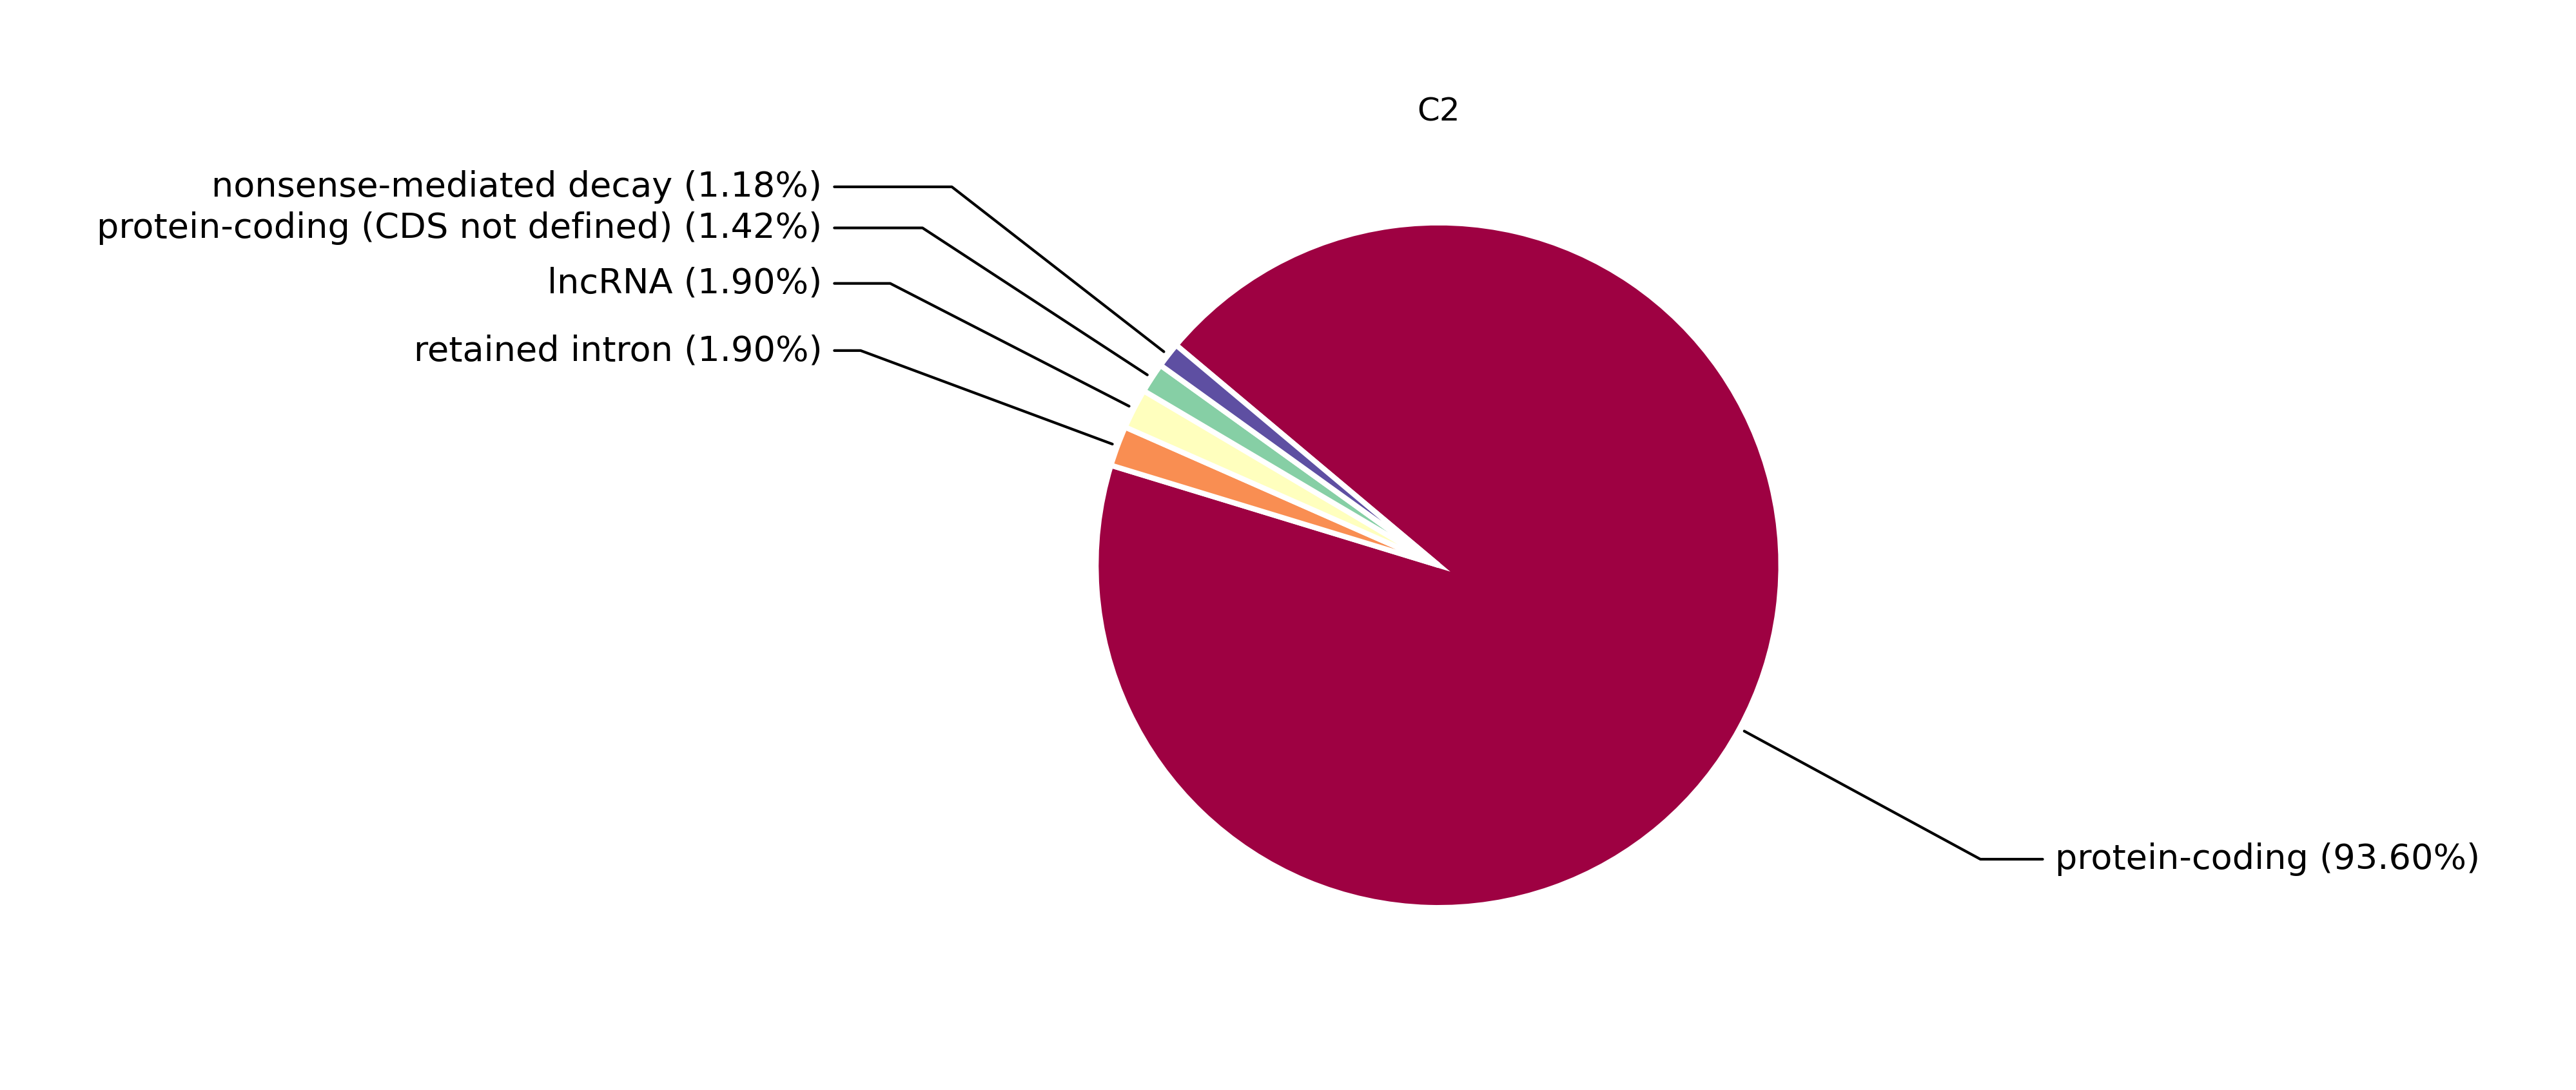

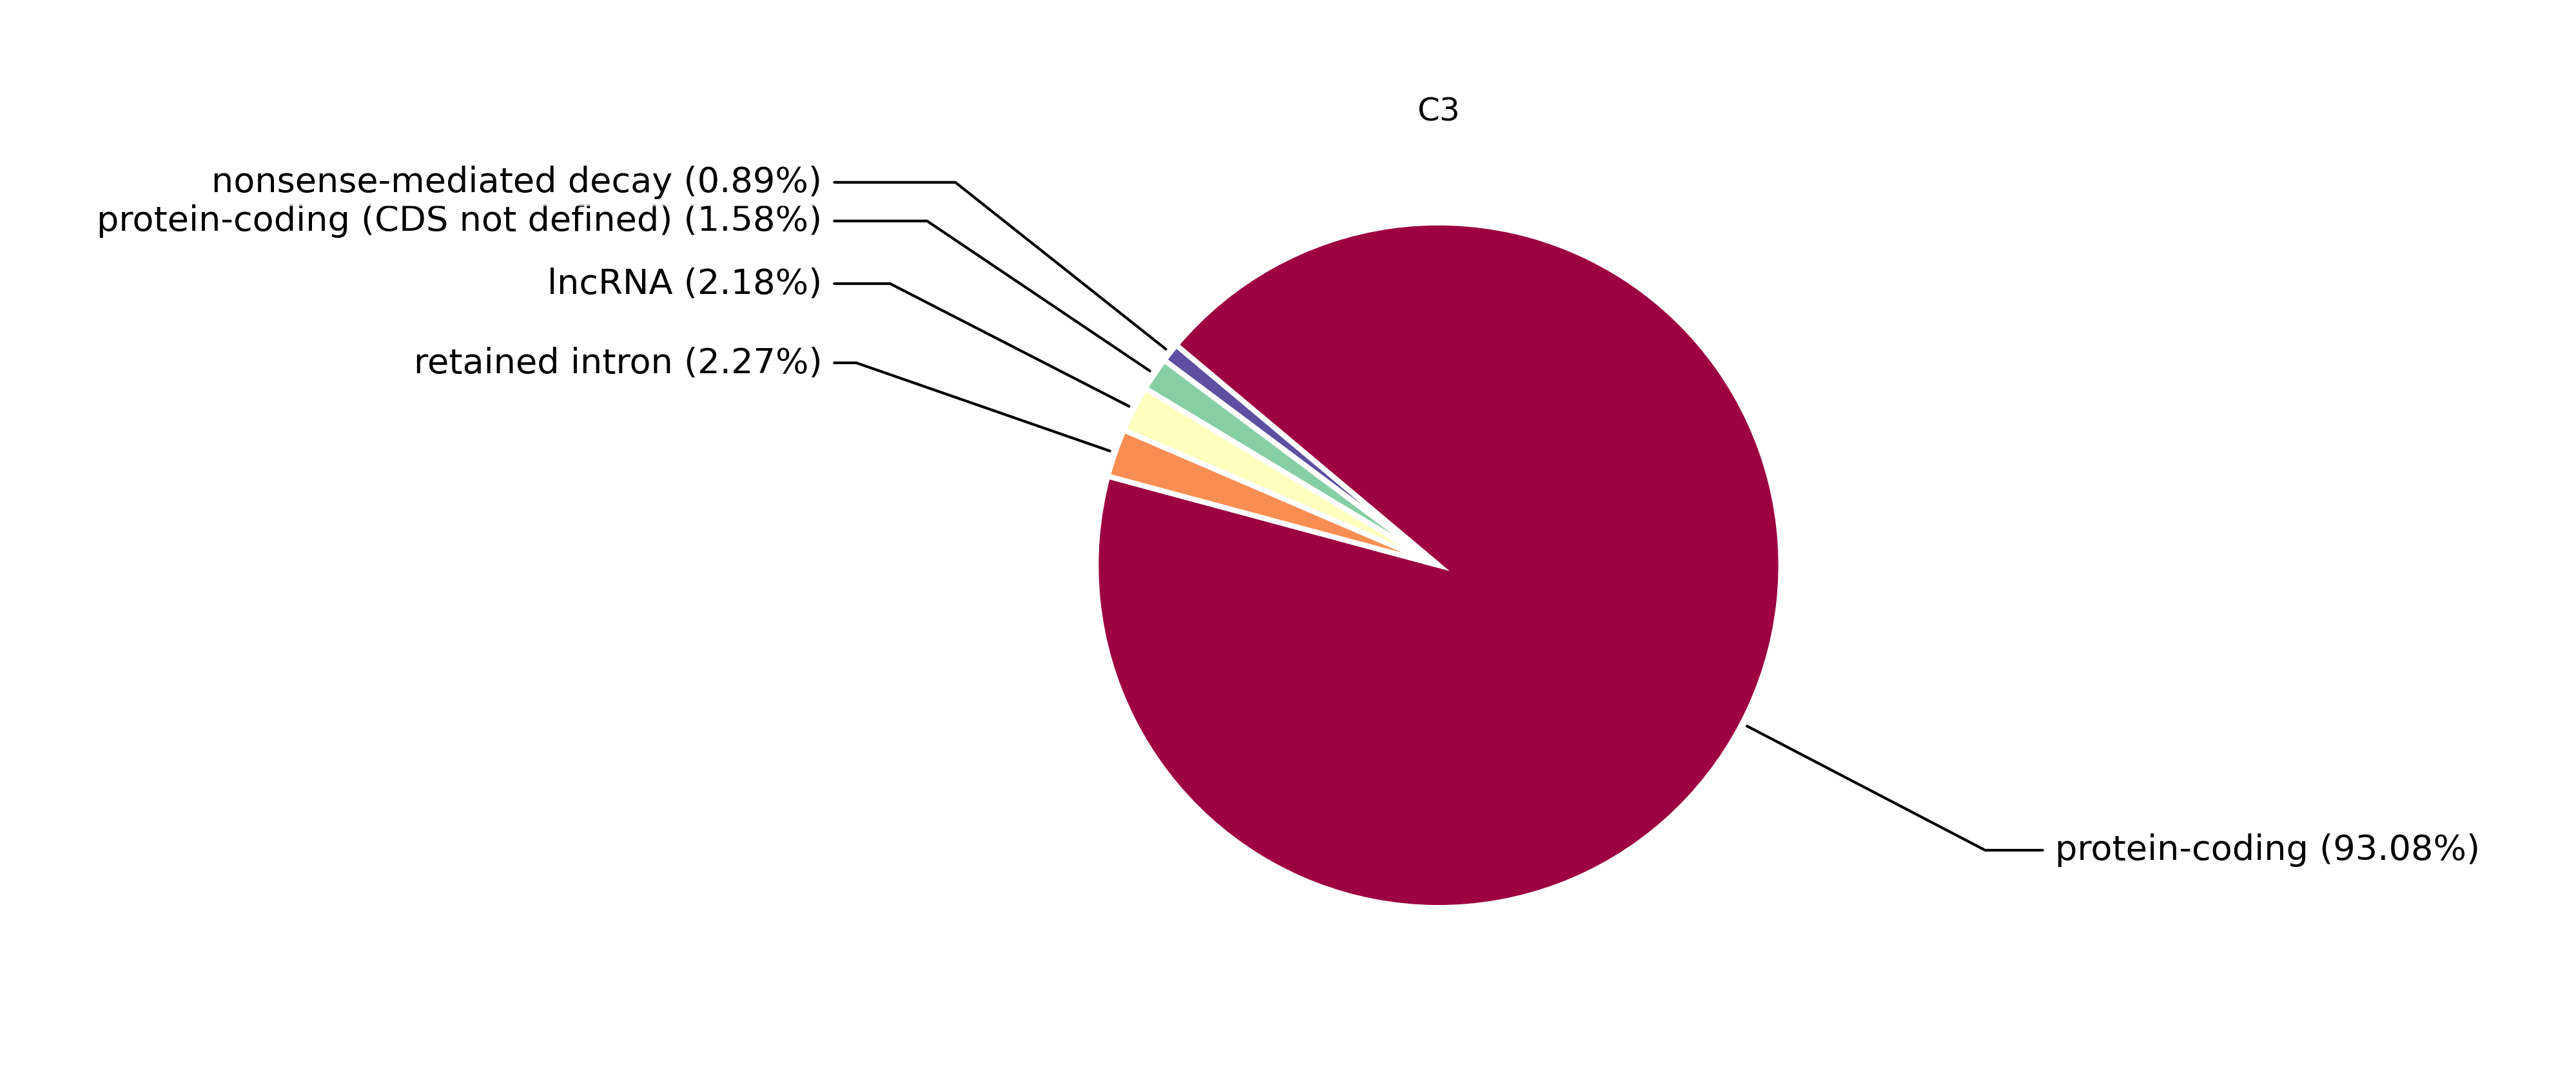

In [146]:
groups = result.columns

label_map = {
    'protein coding': 'protein-coding',
    'retained intron': 'retained intron',
    'lncRNA': 'lncRNA',
    'protein coding CDS not defined': 'protein-coding (CDS not defined)',
    'nonsense mediated decay': 'nonsense-mediated decay',
}

size = 5.75
text_offset = 1.8
colors = plt.cm.Spectral(np.linspace(0, 1, len(result)))  # For style, or use your own color list

for group in groups:
    value_counts_grouped = result[group]
    total = value_counts_grouped.sum()
    
    fig, ax = plt.subplots(figsize=(size, size), dpi=300)
    
    wedges, texts = ax.pie(
        value_counts_grouped,
        startangle=140,
        counterclock=False,
        wedgeprops=dict(linewidth=2, edgecolor='white'),
        colors=colors,
        labels=None
    )
    
    # Annotate each wedge
    for i, p in enumerate(wedges):
        ang = (p.theta2 - p.theta1)/2. + p.theta1
        x = np.cos(np.deg2rad(ang))
        y = np.sin(np.deg2rad(ang))
        horizontal_alignment = 'left' if x >= 0 else 'right'
        connectionstyle = f"angle,angleA=0,angleB={ang}"
        
        # Get cell type label
        key = value_counts_grouped.index[i]
        group_label = label_map.get(key, key).replace("_", " ")
        
        ax.annotate(
            f"{group_label} ({value_counts_grouped.iloc[i] / total * 100:.2f}%)",
            xy=(x, y),
            xytext=(text_offset*np.sign(x), text_offset*y),
            horizontalalignment=horizontal_alignment,
            verticalalignment='center',
            arrowprops=dict(arrowstyle='-', connectionstyle=connectionstyle, color='k'),
            fontsize=13,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
        )
    
    ax.set_ylabel('')
    plt.title(group)
    plt.tight_layout()
    plt.show()

## DE direction mismatches

In [95]:
print(idf.shape)
idf['iso_direction'] = np.where(idf['logfoldchanges'] > 0, 'up', 'down')
idf.head()

(3538, 16)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,gene_name,abs_lfc,is_tf,gene_type,transcript_type,uniprot,deg_logfc,deg_direction,is_deg,iso_direction
0,R1,S100A6-201,62.194511,1.475699,0.0,0.0,0.999496,S100A6,1.475699,False,protein_coding,protein_coding,P06703,1.383227,up,True,up
1,R1,RPS27A-203,61.298794,3.307473,0.0,0.0,0.990932,RPS27A,3.307473,False,protein_coding,protein_coding,B2RDW1,NaN,NaN,False,up
2,R1,COX7A2-202,60.817127,4.788902,0.0,0.0,0.983375,COX7A2,4.788902,False,protein_coding,protein_coding,H0UI06,NaN,NaN,False,up
3,R1,S100A6-202,59.086998,3.932034,0.0,0.0,0.925441,S100A6,3.932034,False,protein_coding,protein_coding,P06703,1.383227,up,True,up
4,R1,TXNDC17-201,58.758808,3.702158,0.0,0.0,0.946599,TXNDC17,3.702158,False,protein_coding,protein_coding,A0A140VJY7,0.659813,up,True,up


In [97]:
def mismatched_direction(subdf):
    deg_dir = subdf['deg_direction'].iloc[0]  # gene-level direction, assumed same within gene/group
    # Get all iso_directions for this gene in this group
    iso_dirs = set(subdf['iso_direction'])
    # If any iso_direction doesn't match deg_direction, return True
    mismatch = any(iso_dir != deg_dir for iso_dir in iso_dirs)
    return pd.Series({
        'deg_direction': deg_dir,
        'iso_directions': list(iso_dirs),
        'iso_deg_mismatch': mismatch
    })

results = (
    idf.groupby(['group', 'gene_name'])
       .apply(mismatched_direction)
       .reset_index()
)

# Filter for mismatches
mismatched = results[results['iso_deg_mismatch']]

mismatched = mismatched.dropna(subset='deg_direction')

print(mismatched.shape)
mismatched.head()

(194, 5)


/tmp/ipykernel_3418126/3749849230.py:15: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,group,gene_name,deg_direction,iso_directions,iso_deg_mismatch
23,R1,ALDOA,up,"[down, up]",True
27,R1,ANKRD11,down,[up],True
35,R1,ANXA5,up,"[down, up]",True
50,R1,ARPC5,down,[up],True
70,R1,AXL,down,[up],True


In [98]:
mismatched[mismatched['deg_direction'] == 'up']

,group,gene_name,deg_direction,iso_directions,iso_deg_mismatch
23,R1,ALDOA,up,"[down, up]",True
35,R1,ANXA5,up,"[down, up]",True
105,R1,CAPNS1,up,[down],True
181,R1,COMMD6,up,[down],True
204,R1,CRTAP,up,[down],True
221,R1,CYTOR,up,"[down, up]",True
479,R1,LTBP2,up,[down],True
531,R1,MRPL34,up,"[down, up]",True
579,R1,NFIC,up,"[down, up]",True
835,R1,SLC25A3,up,[down],True


In [103]:
query = 'CALD1'
display(mismatched[mismatched['gene_name'] == query])
display(idf[idf['gene_name'] == query])

,group,gene_name,deg_direction,iso_directions,iso_deg_mismatch
99,R1,CALD1,down,"[down, up]",True
1130,R2,CALD1,down,[up],True
2023,R3,CALD1,down,"[down, up]",True


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,gene_name,abs_lfc,is_tf,gene_type,transcript_type,uniprot,deg_logfc,deg_direction,is_deg,iso_direction
229,R1,CALD1-206,25.951658,2.156625,1.741587e-148,2.248852e-146,0.492695,CALD1,2.156625,False,protein_coding,protein_coding,Q05682,-1.886711,down,True,up
456,R1,CALD1-222,16.520622,2.043616,2.606968e-61,1.594090e-59,0.300252,CALD1,2.043616,False,protein_coding,protein_coding,E7EX44,-1.886711,down,True,up
932,R1,CALD1-201,-20.163576,-1.124529,2.045503e-90,1.725513e-88,0.415113,CALD1,1.124529,False,protein_coding,protein_coding,Q05682,-1.886711,down,True,down
1153,R1,CALD1-205,-57.860485,-4.144006,0.000000e+00,0.000000e+00,0.316877,CALD1,4.144006,False,protein_coding,protein_coding,Q05682,-1.886711,down,True,down
1416,R2,CALD1-206,30.346415,2.130187,2.801679e-202,2.795269e-200,0.438816,CALD1,2.130187,False,protein_coding,protein_coding,Q05682,-2.733072,down,True,up
2487,R3,CALD1-206,13.196088,1.970194,9.241084e-40,8.826253e-38,0.463740,CALD1,1.970194,False,protein_coding,protein_coding,Q05682,-2.715281,down,True,up
3398,R3,CALD1-201,-16.045204,-1.877611,6.175546e-58,8.234972e-56,0.328244,CALD1,1.877611,False,protein_coding,protein_coding,Q05682,-2.715281,down,True,down


In [151]:
idf[idf['gene_name'] == 'FLNC']

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,gene_name,abs_lfc,is_tf,gene_type,transcript_type,uniprot,deg_logfc,deg_direction,is_deg,iso_direction
189,C2,NFIC-211,28.750593,2.261718,8.904341e-182,1.237864e-179,0.494830,NFIC,2.261718,True,protein_coding,protein_coding,A0A286YEX4,0.774110,up,True,up
592,C2,NFIC-206,-13.902238,-0.804136,6.139111e-44,2.831609e-42,0.321333,NFIC,0.804136,True,protein_coding,protein_coding,P08651,0.774110,up,True,down
972,C3,NFIC-211,45.667175,3.064225,0.000000e+00,0.000000e+00,0.660191,NFIC,3.064225,True,protein_coding,protein_coding,A0A286YEX4,1.414936,up,True,up


In [100]:
mismatched.groupby('group')['iso_deg_mismatch'].value_counts()

group  iso_deg_mismatch
R1     True                77
R2     True                55
R3     True                62
Name: count, dtype: int64

In [101]:
R1_mismatch = mismatched[mismatched['group'] == 'R1']['gene_name'].unique()
R2_mismatch = mismatched[mismatched['group'] == 'R2']['gene_name'].unique()
R3_mismatch = mismatched[mismatched['group'] == 'R3']['gene_name'].unique()

unique_to_R1 = list(set(R1_mismatch) - set(R2_mismatch) - set(R3_mismatch))
unique_to_R2 = list(set(R2_mismatch) - set(R3_mismatch) - set(R1_mismatch))
unique_to_R3 = list(set(R3_mismatch) - set(R2_mismatch) - set(R1_mismatch))
shared = list(set(R2_mismatch) & set(R3_mismatch) & set(R1_mismatch))

print("Mismatches unique to R1:\n" + ", ".join(sorted(unique_to_R1)))
print("\nMismatches unique to R2:\n" + ", ".join(sorted(unique_to_R2)))
print("\nMismatches unique to R3:\n" + ", ".join(sorted(unique_to_R3)))
print("\nShared mismatches:\n" + ", ".join(sorted(shared)))

Mismatches unique to R1:
ALDOA, ANKRD11, ANXA5, CKAP5, CYTOR, DNAJB11, ENG, EZR, FYTTD1, HSPA8, MMP14, MRPL34, NCL, NFIC, NFIX, RPS29, SCAF11, SERBP1, SLC25A3, SPCS2, TAGLN, TUBA1B, UACA, XPC

Mismatches unique to R2:
DDX21, MORF4L2, PEA15, S100A13, SNRPG, TRNP1

Mismatches unique to R3:
ATP2B4, CMSS1, DYNC1I2, GPNMB, GRINA, KHDRBS1, MAP1LC3B, PDIA6, RACK1, RBM17, RPL17, RPL23, RPL37A, TRIM25, USP14, ZFAS1

Shared mismatches:
ARPC5, AXL, CALD1, CD164, CDC37, CDC5L, COL3A1, COL6A1, CRTAP, FTH1, GAS5, HIF1A, HNRNPDL, HSP90B1, HSPB1, IK, NPTN, NQO1, RPL31, RPS20, SELENOS, SERPINE2, SNHG5, SON, SUDS3, TPM1, TPM4, YWHAZ


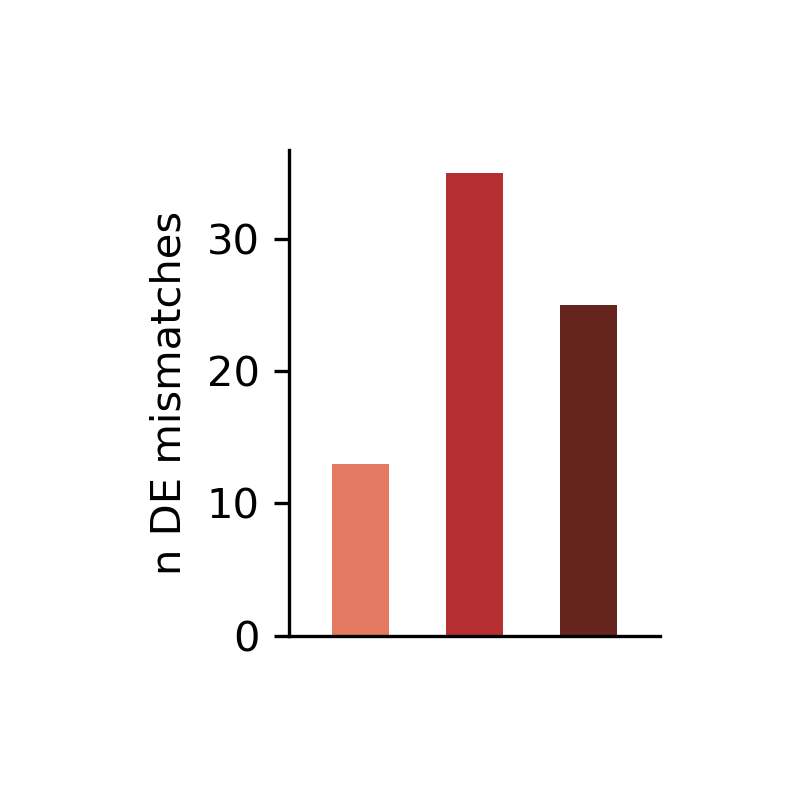

In [99]:
# mismatch_counts = pd.DataFrame({
#     'count': [len(unique_to_R1), len(unique_to_R2), len(unique_to_R3), len(shared)]
# }, index=['unique_r1', 'unique_r2', 'unique_r3', 'r1r2r3'])

# mismatch_counts = mismatch_counts.reset_index(names='grouping')
# mismatch_counts

# plt.rcParams['figure.dpi'] = 300
# plt.rcParams['figure.figsize'] = 2, 2
# fig, ax = plt.subplots()

# palette = ['#FB6A4A', '#CB181D', '#721A12']

# sns.barplot(
#     data=mismatch_counts,
#     y='count',
#     x='grouping',
#     hue='grouping',
#     palette=palette,
#     width=0.5,
# )

# plt.xlabel("")
# plt.ylabel("n DE mismatches")

# plt.gca().tick_params(axis='x', labelbottom=False, bottom=False)
# plt.gca().margins(x=0.15)

# sns.despine()
# plt.tight_layout()
# plt.show()

# Isoform switches

In [237]:
def identify_isoform_switch(df, group1, group2):
    results = []
    top_col1 = f"{group1}_pct_top"
    top_col2 = f"{group2}_pct_top"

    for gene, group_df in df.groupby('gene_name'):
        # Check for valid pct_top transcript names in both groups
        top1_names = group_df[top_col1].dropna()
        top2_names = group_df[top_col2].dropna()

        # Skip gene if either group lacks a pct_top transcript
        if top1_names.empty or top2_names.empty:
            continue
        
        top1_name = top1_names.iloc[0]
        top2_name = top2_names.iloc[0]
        
        # Skip gene if pct_top value is empty string in either group
        if top1_name == '' or top2_name == '':
            continue

        # Find the rows for the top transcripts
        top1_row = group_df[group_df['transcript_name'] == top1_name]
        top2_row = group_df[group_df['transcript_name'] == top2_name]

        # Skip gene if transcript not found for either top isoform
        if top1_row.empty or top2_row.empty:
            continue
        
        top1_row = top1_row.squeeze()
        top2_row = top2_row.squeeze()

        # Check isoform switch and uniprot conditions
        if (
            top1_name != top2_name and
            top1_row['uniprot'] != top2_row['uniprot'] and
            (pd.notna(top1_row['uniprot']) and top1_row['uniprot'] != '' or
             pd.notna(top2_row['uniprot']) and top2_row['uniprot'] != '')
        ):
            results.append({
                'gene_name': gene,
                'is_tf': top1_row['is_tf'], # or top2_row['is_tf']
                f'{group1}_sum': top1_row[f'{group1}_sum'],
                f'{group1}_pct': top1_row[f'{group1}_pct'],
                f'{group1}_pct_top': top1_row[f'{group1}_pct_top'],
                f'{group1}_uniprot': top1_row['uniprot'],
                f'{group2}_sum': top2_row[f'{group2}_sum'],
                f'{group2}_pct': top2_row[f'{group2}_pct'],
                f'{group2}_pct_top': top2_row[f'{group2}_pct_top'],
                f'{group2}_uniprot': top2_row['uniprot'],
            })

    return pd.DataFrame(results)



def filter_isoform_switches(df, group, filt_high_expr=True, q_low=0.25, filter_pct=True, pct_low=0.5, remove_na=True):
    
    tmp = df.copy()
    print(f"Initial shape: {tmp.shape}")
    
    if filt_high_expr:
        # filter for highly expressed genes
        t_group = tmp[f'{group}_sum'].quantile(q_low)
        t_initial = tmp[f'intial_sum'].quantile(q_low)
        tmp = tmp[(tmp[f'{group}_sum'] >= t_group) & (tmp[f'intial_sum'] >= t_initial)]
        
    if filter_pct:
        # filter for top isoforms that are more than 50% of total in group of interest
        tmp = tmp[tmp[f'{group}_pct'] >= pct_low]
        
    if remove_na:
        # filter for IS with non-NA uniprot in group of interest
        tmp = tmp[tmp[f'{group}_uniprot'].notna()]
        
    print(f"Final shape: {tmp.shape}")
    print(tmp['is_tf'].value_counts())
    
    return tmp

In [239]:
columns_to_keep = [
    'transcript_name', 'gene_name', 'gene_type', 'transcript_type', 'is_tf', 'uniprot',
    'C2', 'C3', 'intial', 'HSC', 
    'C2_sum', 'C3_sum', 'intial_sum', 'HSC_sum',
    'C2_pct', 'C3_pct', 'intial_pct', 'HSC_pct',
    'C2_pct_top', 'C3_pct_top', 'intial_pct_top', 'HSC_pct_top'
]

wdf = pdf[columns_to_keep].copy()

# remove mito and ribo
wdf = wdf[~wdf['gene_name'].str.startswith("MT")]
wdf = wdf[~wdf['gene_name'].str.startswith("RP")]

print(wdf.shape)
wdf.head()

(68380, 22)


,transcript_name,gene_name,gene_type,transcript_type,is_tf,uniprot,C2,C3,intial,HSC,...,intial_sum,HSC_sum,C2_pct,C3_pct,intial_pct,HSC_pct,C2_pct_top,C3_pct_top,intial_pct_top,HSC_pct_top
0,A1BG-202,A1BG,protein_coding,retained_intron,False,NaN,8.278723,17.210114,9.975428,3.719573,...,5451.025429,383.251311,0.003370,0.006738,0.001830,0.009705,A1BG-204,A1BG-204,A1BG-204,A1BG-204
1,A1BG-203,A1BG,protein_coding,protein_coding_CDS_not_defined,False,NaN,23.051968,46.525475,31.341120,5.352656,...,5451.025429,383.251311,0.009383,0.018214,0.005750,0.013966,A1BG-204,A1BG-204,A1BG-204,A1BG-204
2,A1BG-204,A1BG,protein_coding,retained_intron,False,NaN,2425.483162,2490.614953,5409.708881,374.179082,...,5451.025429,383.251311,0.987247,0.975048,0.992420,0.976328,A1BG-204,A1BG-204,A1BG-204,A1BG-204
3,A1BG-AS1-202,A1BG-AS1,lncRNA,lncRNA,False,NaN,6.322936,4.790589,34.912318,28.318385,...,227.352582,51.420354,0.068863,0.052791,0.153560,0.550723,A1BG-AS1-204,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-202
4,A1BG-AS1-203,A1BG-AS1,lncRNA,lncRNA,False,NaN,5.708071,4.224966,18.486763,0.000000,...,227.352582,51.420354,0.062166,0.046558,0.081313,0.000000,A1BG-AS1-204,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-202


In [240]:
group2 = 'intial'

result_C2 = identify_isoform_switch(wdf, 'C2', group2)
result_C3 = identify_isoform_switch(wdf, 'C3', group2)

In [245]:
# filter
res_C2 = filter_isoform_switches(result_C2, 'C2')
res_C3 = filter_isoform_switches(result_C3, 'C3')

Initial shape: (1259, 10)
Final shape: (271, 10)
is_tf
False    227
True      44
Name: count, dtype: int64
Initial shape: (1432, 10)
Final shape: (253, 10)
is_tf
False    211
True      42
Name: count, dtype: int64


In [246]:
# identify IS genes that are DEGs
deg_subset = gene_sig[gene_sig['group'] == 'C2'].copy()
deg_subset = deg_subset[['names', 'logfoldchanges', 'direction']]
deg_subset = deg_subset.rename(columns={'logfoldchanges': 'deg_logfc', 'direction': 'deg_direction', 'names': 'gene_name'})
print(deg_subset.shape)

res_C2 = pd.merge(res_C2, deg_subset, how='left', on='gene_name')
res_C2['is_deg'] = res_C2['deg_logfc'].notna()

print(res_C2.shape)
print(res_C2['is_deg'].value_counts())
res_C2.head()

(1540, 3)
(271, 13)
is_deg
False    227
True      44
Name: count, dtype: int64


,gene_name,is_tf,C2_sum,C2_pct,C2_pct_top,C2_uniprot,intial_sum,intial_pct,intial_pct_top,intial_uniprot,deg_logfc,deg_direction,is_deg
0,AAAS,False,87.703378,0.539581,AAAS-208,F8VUB6,368.494727,0.437929,AAAS-201,Q9NRG9,NaN,NaN,False
1,ABCB7,False,57.998345,0.603619,ABCB7-203,O75027,548.132568,0.793660,ABCB7-201,A0A0S2Z2Z3,NaN,NaN,False
2,ACAD9,False,187.238869,0.547483,ACAD9-201,Q9H845,552.487637,0.409000,ACAD9-205,H0Y8Z9,NaN,NaN,False
3,ACIN1,False,171.623771,0.538167,ACIN1-214,A0A087WYN3,658.804207,0.421352,ACIN1-204,Q9UKV3,NaN,NaN,False
4,ADGRD1,False,333.813683,0.604743,ADGRD1-202,H0Y2U9,868.072717,0.475005,ADGRD1-201,Q6QNK2,NaN,NaN,False


In [247]:
# identify IS genes that are DEGs
deg_subset = gene_sig[gene_sig['group'] == 'C3'].copy()
deg_subset = deg_subset[['names', 'logfoldchanges', 'direction']]
deg_subset = deg_subset.rename(columns={'logfoldchanges': 'deg_logfc', 'direction': 'deg_direction', 'names': 'gene_name'})
print(deg_subset.shape)

res_C3 = pd.merge(res_C3, deg_subset, how='left', on='gene_name')
res_C3['is_deg'] = res_C3['deg_logfc'].notna()

print(res_C3.shape)
print(res_C3['is_deg'].value_counts())
res_C3.head()

(3011, 3)
(253, 13)
is_deg
False    184
True      69
Name: count, dtype: int64


,gene_name,is_tf,C3_sum,C3_pct,C3_pct_top,C3_uniprot,intial_sum,intial_pct,intial_pct_top,intial_uniprot,deg_logfc,deg_direction,is_deg
0,AAAS,False,155.020840,0.519729,AAAS-208,F8VUB6,368.494727,0.437929,AAAS-201,Q9NRG9,NaN,NaN,False
1,ABCB7,False,147.180103,0.660654,ABCB7-203,O75027,548.132568,0.793660,ABCB7-201,A0A0S2Z2Z3,NaN,NaN,False
2,ACIN1,False,343.467914,0.636289,ACIN1-214,A0A087WYN3,658.804207,0.421352,ACIN1-204,Q9UKV3,NaN,NaN,False
3,ADGRD1,False,407.412428,0.572749,ADGRD1-202,H0Y2U9,868.072717,0.475005,ADGRD1-201,Q6QNK2,NaN,NaN,False
4,AGPAT4,False,108.140205,0.549103,AGPAT4-201,Q9NRZ5,207.530700,0.455859,AGPAT4-202,Q5TEE8,NaN,NaN,False


In [248]:
C3_IS_genes = res_C3['gene_name'].unique()
C2_IS_genes = res_C2['gene_name'].unique()

unique_C3 = list(set(C3_IS_genes) - set(C2_IS_genes))
unique_C2 = list(set(C2_IS_genes) - set(C3_IS_genes))
shared = list(set(C3_IS_genes) & set(C2_IS_genes))

print(len(unique_C3))
print(len(unique_C2))
print(len(shared))

print("IS genes unique to C2:\n" + ", ".join(sorted(unique_C2)))
print("\nIS genes unique to C3:\n" + ", ".join(sorted(unique_C3)))
print("\nIS genes in C2 and C3:\n" + ", ".join(sorted(shared)))

62
80
191
IS genes unique to C2:
ACAD9, ADGRL2, AFF1, ARHGEF37, ARMCX3, ATP11C, BRPF3, CBR4, CCZ1, CDKN2A, CFAP20DC, CLDND2, CLPB, CMTR2, CYB5A, DCAF17, DLG5, DUSP18, EVL, FRS2, GGA1, GLYR1, GPSM1, HNRNPLL, IP6K1, IRF1, KCTD1, KCTD2, KHDRBS3, LMBR1L, MAP2K7, MCOLN1, MFN2, MFSD13A, MIOS, MLF1, MRPS25, NAGLU, NOD1, NUDCD1, NXN, PACS2, PIGL, PIH1D2, PNKP, PRORP, PYGL, RSRC2, RWDD2B, SAT1, SCYL1, SEPSECS, SEPTIN6, SHC1, SHPRH, SIRT6, SLC11A2, SLC44A2, SNAPC4, TEP1, TLN2, TMEM237, TMEM63B, TNC, TOR1B, TRAPPC9, TTC19, TTC28, TUBGCP6, TYK2, UNC13B, VTI1A, WASHC4, WDPCP, WDR37, ZKSCAN1, ZNF16, ZNF384, ZNF496, ZNF586

IS genes unique to C3:
ALG2, C6orf52, CD276, CDAN1, CDCA3, CHD1, CHKA, CNBP, CRLS1, CYB5R2, DCP1A, DDX56, DYNC1I2, DYNC2I1, GRAMD1A, GRAMD1B, GRIA3, HAPSTR1, HELQ, HNRNPM, IARS1, IKBKE, KCTD13, LONRF1, LPCAT3, LRRC27, MRPL34, MX1, NAALADL1, NDST2, NOTCH1, NUF2, PAQR3, PDIA4, POLG2, POLM, PRXL2C, RAD51AP1, RFX1, SCML1, SEC23IP, SERBP1, SLC25A51, SNX12, SPINDOC, SSBP2, ST3GAL4, STRA

#

# Identify interesting isoform switches

In [69]:
# # get DEGs
# deg_subset = gene_sig[gene_sig['group'] == 'C2'].copy()
# deg_subset['direction'] = np.where(deg_subset['logfoldchanges'] > 0, 'up', 'down')
# deg_subset = deg_subset[['names', 'logfoldchanges', 'direction']]
# deg_subset = deg_subset.rename(columns={'names': 'gene_name'})
# print(deg_subset.shape)
# deg_subset.head()

# # add identifiers for DEGs
# res_C2['is_deg'] = res_C2['gene_name'].isin(deg_subset['gene_name'].unique())
# print(res_C2['is_deg'].value_counts())

# res_C2 = pd.merge(res_C2, deg_subset, how='left', on='gene_name')
# print(res_C2.shape)

# res_C2.head()

(1540, 3)
is_deg
False    227
True      44
Name: count, dtype: int64
(271, 13)


,gene_name,is_tf,C2_sum,C2_pct,C2_pct_top,C2_uniprot,intial_sum,intial_pct,intial_pct_top,intial_uniprot,is_deg,logfoldchanges,direction
0,AAAS,False,87.703378,0.539581,AAAS-208,F8VUB6,368.494727,0.437929,AAAS-201,Q9NRG9,False,NaN,NaN
1,ABCB7,False,57.998345,0.603619,ABCB7-203,O75027,548.132568,0.793660,ABCB7-201,A0A0S2Z2Z3,False,NaN,NaN
2,ACAD9,False,187.238869,0.547483,ACAD9-201,Q9H845,552.487637,0.409000,ACAD9-205,H0Y8Z9,False,NaN,NaN
3,ACIN1,False,171.623771,0.538167,ACIN1-214,A0A087WYN3,658.804207,0.421352,ACIN1-204,Q9UKV3,False,NaN,NaN
4,ADGRD1,False,333.813683,0.604743,ADGRD1-202,H0Y2U9,868.072717,0.475005,ADGRD1-201,Q6QNK2,False,NaN,NaN


In [70]:
# # get DEGs
# deg_subset = gene_sig[gene_sig['group'] == 'C3'].copy()
# deg_subset['direction'] = np.where(deg_subset['logfoldchanges'] > 0, 'up', 'down')
# deg_subset = deg_subset[['names', 'logfoldchanges', 'direction']]
# deg_subset = deg_subset.rename(columns={'names': 'gene_name'})
# print(deg_subset.shape)
# deg_subset.head()

# # add identifiers for DEGs
# res_C3['is_deg'] = res_C3['gene_name'].isin(deg_subset['gene_name'].unique())
# print(res_C3['is_deg'].value_counts())

# res_C3 = pd.merge(res_C3, deg_subset, how='left', on='gene_name')
# print(res_C3.shape)

# res_C3.head()

(3011, 3)
is_deg
False    184
True      69
Name: count, dtype: int64
(253, 13)


,gene_name,is_tf,C3_sum,C3_pct,C3_pct_top,C3_uniprot,intial_sum,intial_pct,intial_pct_top,intial_uniprot,is_deg,logfoldchanges,direction
0,AAAS,False,155.020840,0.519729,AAAS-208,F8VUB6,368.494727,0.437929,AAAS-201,Q9NRG9,False,NaN,NaN
1,ABCB7,False,147.180103,0.660654,ABCB7-203,O75027,548.132568,0.793660,ABCB7-201,A0A0S2Z2Z3,False,NaN,NaN
2,ACIN1,False,343.467914,0.636289,ACIN1-214,A0A087WYN3,658.804207,0.421352,ACIN1-204,Q9UKV3,False,NaN,NaN
3,ADGRD1,False,407.412428,0.572749,ADGRD1-202,H0Y2U9,868.072717,0.475005,ADGRD1-201,Q6QNK2,False,NaN,NaN
4,AGPAT4,False,108.140205,0.549103,AGPAT4-201,Q9NRZ5,207.530700,0.455859,AGPAT4-202,Q5TEE8,False,NaN,NaN


In [109]:
# C3_IS_genes = res_C3['gene_name'].unique()
# C2_IS_genes = res_C2['gene_name'].unique()

# unique_C3 = list(set(C3_IS_genes) - set(C2_IS_genes))
# unique_C2 = list(set(C2_IS_genes) - set(C3_IS_genes))
# shared = list(set(C3_IS_genes) & set(C2_IS_genes))

# print(len(unique_C3))
# print(len(unique_C2))
# print(len(shared))

62
80
191


In [110]:
# print(", ".join(sorted(unique_C3)))

ALG2, C6orf52, CD276, CDAN1, CDCA3, CHD1, CHKA, CNBP, CRLS1, CYB5R2, DCP1A, DDX56, DYNC1I2, DYNC2I1, GRAMD1A, GRAMD1B, GRIA3, HAPSTR1, HELQ, HNRNPM, IARS1, IKBKE, KCTD13, LONRF1, LPCAT3, LRRC27, MRPL34, MX1, NAALADL1, NDST2, NOTCH1, NUF2, PAQR3, PDIA4, POLG2, POLM, PRXL2C, RAD51AP1, RFX1, SCML1, SEC23IP, SERBP1, SLC25A51, SNX12, SPINDOC, SSBP2, ST3GAL4, STRADB, SYT1, TAF8, TEAD1, TSEN54, TTC21A, TUBGCP3, TVP23C, URI1, ZBTB25, ZNF219, ZNF552, ZNF594, ZNF605, ZRSR2


In [111]:
# print(", ".join(sorted(unique_C2)))

ACAD9, ADGRL2, AFF1, ARHGEF37, ARMCX3, ATP11C, BRPF3, CBR4, CCZ1, CDKN2A, CFAP20DC, CLDND2, CLPB, CMTR2, CYB5A, DCAF17, DLG5, DUSP18, EVL, FRS2, GGA1, GLYR1, GPSM1, HNRNPLL, IP6K1, IRF1, KCTD1, KCTD2, KHDRBS3, LMBR1L, MAP2K7, MCOLN1, MFN2, MFSD13A, MIOS, MLF1, MRPS25, NAGLU, NOD1, NUDCD1, NXN, PACS2, PIGL, PIH1D2, PNKP, PRORP, PYGL, RSRC2, RWDD2B, SAT1, SCYL1, SEPSECS, SEPTIN6, SHC1, SHPRH, SIRT6, SLC11A2, SLC44A2, SNAPC4, TEP1, TLN2, TMEM237, TMEM63B, TNC, TOR1B, TRAPPC9, TTC19, TTC28, TUBGCP6, TYK2, UNC13B, VTI1A, WASHC4, WDPCP, WDR37, ZKSCAN1, ZNF16, ZNF384, ZNF496, ZNF586


In [155]:
# deg = sc.get.rank_genes_groups_df(
#     adata, 
#     group=None,
#     key='reprogram_vs_initial',
# )

# deg['gene_name'] = deg['names'].str.split('-', n=1).str[0]

# sig = get_significant_DEGs(deg, logfc_thresh=0.5, pct_nz_thresh=0.3)
# print(sig.shape)

# sig['is_tf'] = sig['gene_name'].isin(tf_list)

# print(f"N unique DEGs: {sig['gene_name'].nunique()}")
# print(f"N unique DEIs: {sig['names'].nunique()}")

# sig.head()

Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
Removed upregaulted genes expressed in less than 30.0% of cells. Kept all downregulated genes.
(1929, 9)
N unique DEGs: 1131
N unique DEIs: 1270


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,gene_name,abs_lfc,is_tf
0,C2,S100A10-202,72.327988,2.649388,0.0,0.0,0.998085,S100A10,2.649388,False
1,C2,KRT18-201,70.407776,5.439939,0.0,0.0,0.940636,KRT18,5.439939,False
2,C2,S100A6-201,68.143044,1.710796,0.0,0.0,1.000000,S100A6,1.710796,False
3,C2,S100A4-204,67.673615,2.318630,0.0,0.0,0.994638,S100A4,2.318630,False
4,C2,PRDX5-201,66.054512,1.889716,0.0,0.0,0.978935,PRDX5,1.889716,True


In [157]:
# sig.groupby('group')['names'].nunique()

group
C2     880
C3    1049
Name: names, dtype: int64

In [160]:
# get genes with DEIs
C2_DEIs = sig[sig['group'] == 'C2']['gene_name'].unique()
C3_DEIs = sig[sig['group'] == 'C3']['gene_name'].unique()

print(len(C2_DEIs))
print(len(C3_DEIs))

# get DEGs
C2_DEGs = gene_sig[gene_sig['group'] == 'C2']['names'].unique()
C3_DEGs = gene_sig[gene_sig['group'] == 'C3']['names'].unique()

# which DEI genes are DE at gene-level?
C2_overlap = list(set(C2_DEIs) & set(C2_DEGs))
C3_overlap = list(set(C3_DEIs) & set(C3_DEGs))

print(len(C2_overlap))
print(len(C3_overlap))

787
942
508
661


In [118]:
C3_IS_genes = res_C3['C3_pct_top'].unique()
C2_IS_genes = res_C2['C2_pct_top'].unique()

print(len(C3_IS_genes))
print(len(C2_IS_genes))

is_dei_C3 = [g for g in C3_IS_genes if g in sig[sig['group'] == 'C3']['names'].unique()]
is_dei_C2 = [g for g in C2_IS_genes if g in sig[sig['group'] == 'C2']['names'].unique()]

print(len(is_dei_C3))
print(len(is_dei_C2))

print("\nC3:")
print(", ".join(sorted(is_dei_C3)))

print("\nC2:")
print(", ".join(sorted(is_dei_C2)))

253
271
32
19

C3:
CENPT-202, CNBP-201, COL5A1-201, COX7A2-202, DDX17-202, DIP2C-201, EID1-201, FILIP1L-208, FLNA-202, GFPT1-202, GNAI2-202, GPNMB-201, HNRNPK-204, HSPB1-206, HSPD1-202, LIMA1-214, MRPL34-203, NFIC-211, NQO1-201, PBX3-203, PFDN5-214, PPP3CA-202, PXN-203, RACK1-210, RBM3-203, RNASEH2C-201, SERBP1-203, SGK1-201, TEAD1-203, TMBIM4-202, TPM1-207, UBC-201

C2:
COX7A2-202, DDX17-202, EID1-201, GNAI2-202, GPNMB-201, HNRNPK-204, HSPB1-206, HSPD1-202, LIMA1-214, NDUFA3-214, NFIC-211, PFDN5-214, RACK1-210, RBM3-203, RNASEH2C-201, SGK1-201, TMBIM4-202, TPM1-207, UBC-201


In [146]:
# C2 vs C3
deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='C2_vs_C3',
)

deg['gene_name'] = deg['names'].str.split('-', n=1).str[0]

sig = get_significant_DEGs(deg, logfc_thresh=0.5, pct_nz_thresh=0.3)
print(sig.shape)

sig['is_tf'] = sig['gene_name'].isin(tf_list)

print(f"N unique DEGs: {sig['gene_name'].nunique()}")
print(f"N unique DEIs: {sig['names'].nunique()}")

sig = sig.sort_values(by='logfoldchanges', ascending=False)

sig.head()

Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
Removed upregaulted genes expressed in less than 30.0% of cells. Kept all downregulated genes.
(275, 8)
N unique DEGs: 252
N unique DEIs: 275


,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,gene_name,abs_lfc,is_tf
197,ISG15-203,12.752450,0.934313,3.020984e-37,6.930217e-35,0.672156,ISG15,0.934313,False
78,MYL6-207,18.643724,0.923020,1.419993e-77,8.892100e-75,0.809268,MYL6,0.923020,False
176,ALDOA-219,13.394188,0.897114,6.538728e-41,1.689593e-38,0.528533,ALDOA,0.897114,False
420,CRYAB-217,7.348515,0.887456,2.004217e-13,1.570588e-11,0.315971,CRYAB,0.887456,False
134,MYL9-201,15.194202,0.883282,3.863370e-52,1.377123e-49,0.666411,MYL9,0.883282,False


In [147]:
sig['gene_name'].nunique()

252

In [108]:
sig[sig['gene_name'] == 'MYL9']

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,gene_name,abs_lfc,is_tf
134,MYL9-201,15.194202,0.883282,3.863370e-52,1.377123e-49,0.666411,MYL9,0.883282,False


In [ ]:
# print(", ".join(sorted(res['gene_name'].unique())))

In [ ]:
# # Write out
# outpath = f"/home/jrcwycy/HSC/TERMIS/isoforms/IS_tables/{group1}_vs_{group2}_IS.csv"

# res.to_csv(outpath)
# res.head()

## enrichr IS genes

In [149]:
# filter
res_C2 = filter_isoform_switches(result_C2, 'C2', filt_high_expr=False)
res_C3 = filter_isoform_switches(result_C3, 'C3', filt_high_expr=False)

Initial shape: (1259, 10)
Final shape: (482, 10)
is_tf
False    413
True      69
Name: count, dtype: int64
Initial shape: (1432, 10)
Final shape: (461, 10)
is_tf
False    397
True      64
Name: count, dtype: int64


In [154]:
# pd.set_option('display.max_colwidth', None)

database = "GO_Biological_Process_2025"
# database='CellMarker_2024'
# database='Tabula_Sapiens'
# database='PanglaoDB_Augmented_2021'
database="Reactome_Pathways_2024"
database="KEGG_2021_Human"
database='MSigDB_Hallmark_2020' 
database = 'WikiPathways_2024_Human'
# database = 'GO_Cellular_Component_2025'
# database = 'GO_Molecular_Function_2025'

print("C2:")
gene_list = res_C2['gene_name'].unique()
print(f'N genes: {len(gene_list)}')

enr = gget.enrichr(gene_list, database, save=False)
display(enr[['path_name', 'overlapping_genes', 'adj_p_val']].head(15))
print("=" * 100 + "\n")


print("C3:")
gene_list = res_C3['gene_name'].unique()
print(f'N genes: {len(gene_list)}')

enr = gget.enrichr(gene_list, database, save=False)
display(enr[['path_name', 'overlapping_genes', 'adj_p_val']].head(15))

17:51:31 - INFO - Performing Enrichr analysis using database WikiPathways_2024_Human.
2025-11-30 17:51:31 | [INFO] Performing Enrichr analysis using database WikiPathways_2024_Human.


C2:
N genes: 482


,path_name,overlapping_genes,adj_p_val
0,GPR143 In Melanocytes And Retinal Pigment Epithelium Cells WP4941,"[GPR143, ADCY4, ARRB2, PRKACA, PLCB1, VEGFA]",0.033444
1,NOTCH1 Regulation Of Endothelial Cell Calcification WP3413,"[SOX6, SAT1, DLL1, VEGFA]",0.149816
2,7Q11 23 Distal Copy Number Variation WP5401,"[POR, G3BP1, HSPB1, SSC4D]",0.215795
3,Gastrin Signaling WP4659,"[TJP1, PRKCH, SHC1, CDKN2A, PXN, PTPN11, ARRB2, PRKACA, VEGFA]",0.215795
4,Oncostatin M Signaling WP2374,"[PRKCH, SHC1, PXN, PTPN11, TYK2, VEGFA]",0.215795
5,Macrophage Stimulating Protein MSP Signaling WP5353,"[PDGFRB, TJP1, FLT1, SHC1, HSPB1, SMAD6, TP53, VEGFA]",0.293382
6,Ferroptosis WP4313,"[POR, GCLC, SLC11A2, HSPB1, SAT1, TP53]",0.293382
7,Aryl Hydrocarbon Receptor Pathway WP2586,"[RET, NQO1, GCLC, CD36, VEGFA]",0.293382
8,SARS CoV 2 Altering Angiogenesis Via NRP1 WP5065,"[FURIN, VEGFA]",0.297627
9,miR 509 3P Alteration Of YAP1 ECM Axis WP3967,"[TEAD4, COL5A1, PBX3]",0.330799


17:51:31 - INFO - Performing Enrichr analysis using database WikiPathways_2024_Human.
2025-11-30 17:51:31 | [INFO] Performing Enrichr analysis using database WikiPathways_2024_Human.



C3:
N genes: 461


,path_name,overlapping_genes,adj_p_val
0,miR 509 3P Alteration Of YAP1 ECM Axis WP3967,"[TEAD4, COL5A1, PBX3, TEAD1]",0.262766
1,7Q11 23 Distal Copy Number Variation WP5401,"[POR, G3BP1, HSPB1, SSC4D]",0.307134
2,Intraflagellar Transport Proteins Binding To Dynein WP4532,"[DYNC2H1, DYNC2I1, DYNC1I2, IFT140]",0.403409
3,Genes Controlling Nephrogenesis WP4823,"[RET, PDGFRB, CD36, ETV4, VEGFA]",0.403409
4,Aryl Hydrocarbon Receptor Pathway WP2586,"[RET, NQO1, GCLC, CD36, VEGFA]",0.403409
5,SARS CoV 2 Altering Angiogenesis Via NRP1 WP5065,"[FURIN, VEGFA]",0.422450
6,NOTCH1 Regulation Of Endothelial Cell Calcification WP3413,"[NOTCH1, DLL1, VEGFA]",0.422450
7,Apoptosis Related Network Due To Altered Notch3 Ovarian Cancer WP2864,"[NQO1, GCLC, SERBP1, HSPB1, HSPD1]",0.422450
8,Hippo Signaling Regulation WP4540,"[PDGFRB, TEAD4, PRKCH, FLT1, PRKACA, TEAD1, GNAI2]",0.422450
9,Imatinib And Chronic Myeloid Leukemia WP3640,"[PDGFRB, LYL1, FLT1]",0.439132


14908


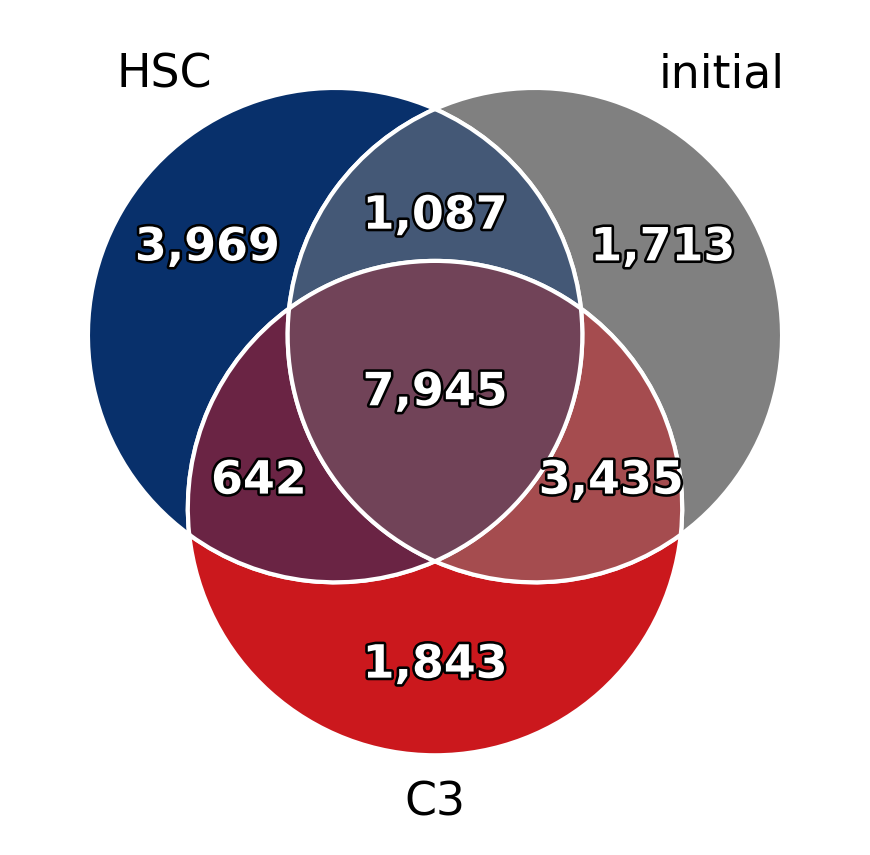

In [91]:
group = 'C3'

vdf = pdf[['transcript_name', 'gene_name', 'gene_type', 'intial_pct_top', f'{group}_pct_top', 'HSC_pct_top']]

vdf = vdf[vdf['gene_type'] == 'protein_coding']
print(vdf['gene_name'].nunique())
vdf = vdf.drop_duplicates(subset=['gene_name'], keep='first')

vdf_clean = vdf.dropna(subset=['intial_pct_top', f'{group}_pct_top', 'HSC_pct_top'])

set1 = set(vdf['intial_pct_top'].dropna())
set2 = set(vdf[f'{group}_pct_top'].dropna())
set3 = set(vdf['HSC_pct_top'].dropna())

group_names = ['HSC', 'initial', f'{group}']

colors_rgb = {
    'initial': mcolors.to_rgb('#808080'),    
    # f'{group}': mcolors.to_rgb('#FB6A4A'), # C2
    f'{group}': mcolors.to_rgb('#CB181D'), # C3
    'HSC': mcolors.to_rgb('#08306B')      
}


def blend(colors):
    arr = np.array(colors)
    return tuple(arr.mean(axis=0))


venn_ids = {
    '100': ['HSC'],
    '010': ['initial'],
    '001': [f'{group}'],
    '110': ['HSC', 'initial'],
    '101': ['HSC', f'{group}'],
    '011': ['initial', f'{group}'],
    '111': ['HSC', 'initial', f'{group}']
}

plt.rcdefaults()
plt.rcParams['figure.dpi'] = 300
plt.figure(figsize=(3, 3))

venn = venn3_unweighted(
    [set3, set1, set2],
    set_labels=group_names
)

for label in venn.set_labels:
        if label:
            label.set_fontsize(11)

for subset_id, sets in venn_ids.items():
    patch = venn.get_patch_by_id(subset_id)
    if patch:
        color = blend([colors_rgb[s] for s in sets])
        patch.set_facecolor(color)
        patch.set_edgecolor('white')
        patch.set_linewidth(1)
        patch.set_alpha(1)
    label = venn.get_label_by_id(subset_id)
    if label:
        label.set_text(f"{int(label.get_text()):,}")
        label.set_fontsize(11)
        label.set_fontweight('bold')
        label.set_horizontalalignment('center')
        label.set_verticalalignment('center')
        label.set_color('white')
        label.set_path_effects([
            path_effects.Stroke(linewidth=1.25, foreground='black'),
            path_effects.Normal()])
        
        x, y = label.get_position()
        offset = 0
        if subset_id == '101':  # nudge left
            offset = -0.04
        elif subset_id == '011': # nudge right
            offset = 0.04
        elif subset_id == '100':
            offset = 0.04
        elif subset_id == '010':
            offset = -0.04
        label.set_position((x + offset, y))
        if subset_id == '001':
            label.set_position((x, y + 0.03))

plt.tight_layout()
plt.show()

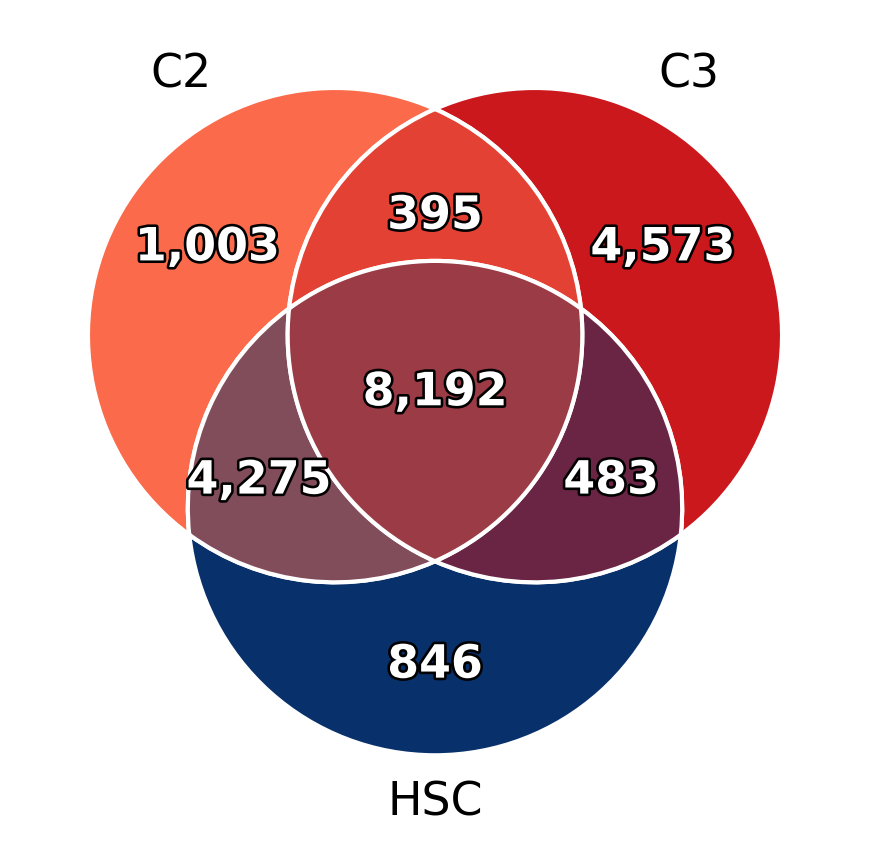

In [89]:
# C2, C3 and initial or target
group = 'HSC'

vdf = pdf[['transcript_name', 'gene_name', 'gene_type', 'C2_pct_top', f'C3_pct_top', f'{group}_pct_top']]

vdf = vdf[vdf['gene_type'] == 'protein_coding']
vdf = vdf.drop_duplicates(subset=['gene_name'], keep='first')

vdf_clean = vdf.dropna(subset=['C2_pct_top', f'C3_pct_top', f'{group}_pct_top'])

set1 = set(vdf[f'{group}_pct_top'].dropna())
set2 = set(vdf['C2_pct_top'].dropna())
set3 = set(vdf['C3_pct_top'].dropna())

group_names = ['C2', 'C3', f'{group}']
# group_names = ['C2', 'C3', 'initial']

colors_rgb = {
    'C2': mcolors.to_rgb('#FB6A4A'), # C2
    'C3': mcolors.to_rgb('#CB181D'), # C3
    f'{group}': mcolors.to_rgb('#08306B'), # HSC     
    # f'{group}': mcolors.to_rgb('#808080'), # initial
}


def blend(colors):
    arr = np.array(colors)
    return tuple(arr.mean(axis=0))


venn_ids = {
    '100': ['C2'],
    '010': ['C3'],
    '001': [f'{group}'],
    '110': ['C2', 'C3'],
    '101': ['C2', f'{group}'],
    '011': ['C3', f'{group}'],
    '111': ['C2', 'C3', f'{group}']
}

plt.rcdefaults()
plt.rcParams['figure.dpi'] = 300
plt.figure(figsize=(3, 3))

venn = venn3_unweighted(
    [set3, set1, set2],
    set_labels=group_names
)

for label in venn.set_labels:
        if label:
            label.set_fontsize(11)

for subset_id, sets in venn_ids.items():
    patch = venn.get_patch_by_id(subset_id)
    if patch:
        color = blend([colors_rgb[s] for s in sets])
        patch.set_facecolor(color)
        patch.set_edgecolor('white')
        patch.set_linewidth(1)
        patch.set_alpha(1)
    label = venn.get_label_by_id(subset_id)
    if label:
        label.set_text(f"{int(label.get_text()):,}")
        label.set_fontsize(11)
        label.set_fontweight('bold')
        label.set_horizontalalignment('center')
        label.set_verticalalignment('center')
        label.set_color('white')
        label.set_path_effects([
            path_effects.Stroke(linewidth=1.25, foreground='black'),
            path_effects.Normal()])
        
        x, y = label.get_position()
        offset = 0
        if subset_id == '101':  # nudge left
            offset = -0.04
        elif subset_id == '011': # nudge right
            offset = 0.04
        elif subset_id == '100':
            offset = 0.04
        elif subset_id == '010':
            offset = -0.04
        label.set_position((x + offset, y))
        if subset_id == '001':
            label.set_position((x, y + 0.03))

plt.tight_layout()
plt.show()

In [21]:
plot_df = pdf.copy()
print(plot_df.columns)
print()

plot_df = plot_df[~plot_df['gene_name'].str.startswith("MT")]
plot_df = plot_df[~plot_df['gene_name'].str.startswith("RP")]

# Drop rows where all _top values are the same (excluding NaN-only rows)
top_cols = ['C1_pct_top', 'C2_pct_top', 'C3_pct_top', 'intial_pct_top', 'HSC_pct_top']

results = []

for column in top_cols:
    label = column.replace("_pct_top", "")
    other_columns = top_cols.copy()
    other_columns.remove(column)
    
    mask = (
        plot_df['transcript_name'] == plot_df[column]) &\
        (plot_df[other_columns].ne(plot_df[column], axis=0).all(axis=1)) &\
        (plot_df['transcript_type'] == 'protein_coding') &\
        (plot_df['uniprot'].notna() #&\
        #(plot_df['is_tf'])
        )
    
    dominant_iso = plot_df[mask].copy()
    tmp = pd.DataFrame(dominant_iso['gene_name'].unique(), columns=['gene_name'])
    tmp['group'] = label
    results.append(tmp)

results = pd.concat(results)
print(results['group'].value_counts())


results

Index(['transcript_name', 'B6', 'C1', 'C2', 'C3', 'CLP', 'CMP', 'HSC', 'LMPP',
       'MEG/ERY', 'MPP', 'intial', 'total_transcript', 'gene_name',
       'gene_type', 'transcript_type', 'is_tf', 'uniprot', 'n_isoforms',
       'n_protiens', 'C1_sum', 'C2_sum', 'C3_sum', 'intial_sum', 'HSC_sum',
       'total_gene', 'C1_pct', 'C2_pct', 'C3_pct', 'intial_pct', 'HSC_pct',
       'C1_pct_top', 'C2_pct_top', 'C3_pct_top', 'intial_pct_top',
       'HSC_pct_top'],
      dtype='object')

group
HSC       2125
intial     747
C3         168
C1         167
C2         160
Name: count, dtype: int64


,gene_name,group
0,ABCB9,C1
1,ACMSD,C1
2,ADD1,C1
3,AKT1,C1
4,ANKHD1,C1
...,...,...
2120,ZSCAN20,HSC
2121,ZSCAN26,HSC
2122,ZSCAN30,HSC
2123,ZSCAN31,HSC


In [22]:
group_of_interest = 'C2'

tmp = results[results['group'] == group_of_interest].copy()

print(tmp.shape)
tmp.head()

(160, 2)


,gene_name,group
0,ABCA5,C2
1,ABHD18,C2
2,AKIP1,C2
3,ALG11,C2
4,ALS2,C2


# Get DEGs

In [23]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/three_libraries.h5ad"

gdata = sc.read_h5ad(fpath)
gdata

CPU times: user 2.61 s, sys: 3.39 s, total: 6 s
Wall time: 15.5 s


AnnData object with n_obs × n_vars = 21062 × 25739
    obs: 'dataset', 'source', 'cluster', 'group', 'label', 'S_score', 'G2M_score', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'filter_pass', 'bm_clusters', 'subgroup'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mito', 'filter_pass'
    uns: 'deg', 'rank_genes_groups', 'scvi_expression', 'subgroup_colors'
    obsm: 'X_paga', 'X_pca', 'X_pca_harmony', 'X_scvi

In [24]:
# C2 and C3 vs initial
sc.tl.rank_genes_groups(
    gdata, 
    groupby='label',
    groups=['C2', 'C3'],
    reference='intial',
    method='wilcoxon',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='reprogram_vs_initial',
)

ranking genes
    finished (0:01:14)


In [25]:
gene_deg = sc.get.rank_genes_groups_df(
    gdata, 
    group=None,
    key='reprogram_vs_initial',
)

gene_deg['gene_name'] = gene_deg['names'].str.split('-', n=1).str[0]

gene_sig = get_significant_DEGs(gene_deg, logfc_thresh=0.5, pct_nz_thresh=0.3)
print(gene_sig.shape)

gene_sig['is_tf'] = gene_sig['gene_name'].isin(tf_list)

print(f"N unique DEGs: {gene_sig['gene_name'].nunique()}")
print(f"N unique DEIs: {gene_sig['names'].nunique()}")

gene_sig.head()

Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
Removed upregaulted genes expressed in less than 30.0% of cells. Kept all downregulated genes.
(4551, 9)
N unique DEGs: 3419
N unique DEIs: 3448


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,gene_name,abs_lfc,is_tf
0,C2,S100A10,72.934486,2.792023,0.0,0.0,0.998085,S100A10,2.792023,False
1,C2,KRT18,70.655441,5.373436,0.0,0.0,0.942551,KRT18,5.373436,False
2,C2,S100A6,68.750633,1.713251,0.0,0.0,1.000000,S100A6,1.713251,False
3,C2,MGP,68.691757,6.548712,0.0,0.0,0.929146,MGP,6.548712,False
4,C2,S100A4,67.969475,2.188516,0.0,0.0,0.997702,S100A4,2.188516,False


In [26]:
C2_degs = gene_sig[gene_sig['group'] == 'C2']['names'].unique()
print(len(C2_degs))

C3_degs = gene_sig[gene_sig['group'] == 'C3']['names'].unique()
print(len(C3_degs))

1540
3011


In [27]:
group_of_interest = 'C2'

tmp = results[results['group'] == group_of_interest].copy()

print(tmp.shape)
tmp.head()

(160, 2)


,gene_name,group
0,ABCA5,C2
1,ABHD18,C2
2,AKIP1,C2
3,ALG11,C2
4,ALS2,C2


In [28]:
non_de_IS = tmp[~tmp['gene_name'].isin(C2_degs)].copy()
print(len(non_de_IS))

149


In [30]:
print(", ".join(sorted(non_de_IS['gene_name'].unique())))

ABCA5, ABHD18, AKIP1, ALG11, ALS2, AP2A2, ARHGAP11B, ATG10, ATG16L1, ATP9B, BTBD6, C18orf54, C6orf132, CACNA2D1, CBLB, CCDC50, CCDC65, CCDC82, CCZ1, CDC25B, CDK5RAP2, CDKN2AIP, CEP43, CFAP299, CFAP70, CLASRP, CLK1, CLN5, COQ8B, CPED1, CPSF4, DENND2A, DGKZ, DMKN, DMWD, DONSON, EDDM13, ENTR1, FBXW4, FHOD3, FIG4, FMN2, FRMD8, GAS2L3, GK, GPR143, HAMP, HAVCR2, HDAC11, HGF, HMGCS1, HOOK2, HYCC1, IQCD, IRF3, KCNG1, KCNQ5, KCTD1, KIF11, KIRREL3, KLHL2, LDAH, LEKR1, LHX9, LIMCH1, LIPT1, LRP8, LYPD6B, MAD1L1, MAP2K5, MASP1, MIOS, MIPOL1, MKKS, MMS22L, MSANTD4, MUC20, MYC, NALCN, NDRG2, NEMP1, NFKBIB, NHLRC3, NIBAN2, NINJ2, NIPA2, NPR3, OARD1, ODAD2, OSBPL1A, PACRGL, PARP6, PCBP2, PDZRN3, PGAP2, PIEZO2, PLEKHG2, PPFIBP2, PPIL6, PRIM2, PTOV1, RAD17, RANBP3, RASA4, RNF212, RSAD2, RUNX1T1, SANBR, SAPCD1, SEPSECS, SERHL2, SERPINE3, SGCD, SGIP1, SLC16A14, SLC2A6, SLC35C2, SPOCK3, SUPT20H, SYNPO2L, SYT15, TBPL1, TCERG1, TIMELESS, TLE6, TM6SF1, TMEM91, TMUB2, TPSAB1, TRAPPC12, TTC23, USP36, VEPH1, VPS5

In [31]:
group_of_interest = 'C3'

tmp = results[results['group'] == group_of_interest].copy()

print(tmp.shape)
tmp.head()

non_de_IS = tmp[~tmp['gene_name'].isin(C3_degs)].copy()
print(len(non_de_IS))

print(", ".join(sorted(non_de_IS['gene_name'].unique())))

(168, 2)
128
AKAP7, ANK2, ANKRD24, ANKRD9, APOBEC3D, ARHGAP27, ARL13B, ARMC6, ARNT2, ASRGL1, AUTS2, BAG6, BCL2L2, BEND7, BMAL1, BRF1, C11orf91, CACNB1, CANT1, CCHCR1, CFI, CYB5B, DACT3, DCUN1D2, DOCK7, DUSP28, DYNC2LI1, ECI1, ETV4, ETV7, FBXL12, FBXO46, FHL2, FRMD5, GALM, GLYCTK, GRAMD2B, GRK4, GTF2H2, GTF2IRD2, HMMR, HNRNPC, HOPX, HPS4, HSPA9, IL13RA2, IL15, IL15RA, IL33, INPP4B, IRF9, KIAA1217, LHX9, LIMCH1, LPXN, LRRC66, MAD1L1, MAP4K1, MAT2B, MECOM, MEF2C, MX2, MYLK3, NAV3, NCKAP5, NDST2, NECAB1, NEK3, NOD1, NOL12, NOTCH1, NR3C1, NRM, NRP1, OAS3, PDCD6IP, PIGQ, PINLYP, PLCB3, PRDM1, PRXL2A, PTOV1, RABL2B, RGN, RGS7, RNF182, RNF32, SCG5, SENP6, SEPTIN4, SLC14A1, SLC7A6OS, SPATA7, SPHK1, SPINDOC, SPOP, SRGAP3, SSBP4, STAG2, STK36, SVEP1, TBC1D7, TCF19, TCTN1, TEAD1, THRB, TMEM171, TMLHE, TRNT1, TRPC3, VLDLR, WDR25, XRCC3, ZBTB1, ZNF202, ZNF257, ZNF334, ZNF383, ZNF419, ZNF589, ZNF695, ZNF821, ZNF84, ZNG1C, ZSCAN31, ZSCAN5A, ZSWIM7, ZSWIM8


### Interesting IS genes that are not DE at gene-level (vs initial)

C2: MYC, NFKBIB, RUNX1T1, SERPINE3

C3: BRF1, ETV4, HNRNPC, HOPX, IL13RA2, MAP4K1, MECOM, MEF2C, NOTCH1, TEAD1, 

In [122]:
pdf[pdf['gene_name'] == 'EID1'].head()

,transcript_name,B6,C1,C2,C3,CLP,CMP,HSC,LMPP,MEG/ERY,...,C1_pct,C2_pct,C3_pct,intial_pct,HSC_pct,C1_pct_top,C2_pct_top,C3_pct_top,intial_pct_top,HSC_pct_top
15560,EID1-201,0.000000,1124.779567,2802.836987,3702.244904,9.071650,2.145531,17.260572,6.878376,5.290299,...,0.969527,0.946019,0.977798,0.41586,0.034178,EID1-201,EID1-201,EID1-201,EID1-202,EID1-202
15561,EID1-202,4.515459,35.352807,159.932601,84.064090,120.824716,67.481523,487.758078,63.997472,131.398790,...,0.030473,0.053981,0.022202,0.58414,0.965822,EID1-201,EID1-201,EID1-201,EID1-202,EID1-202


# Proportion plot

Text(0.5, 1.0, 'TEAD4')

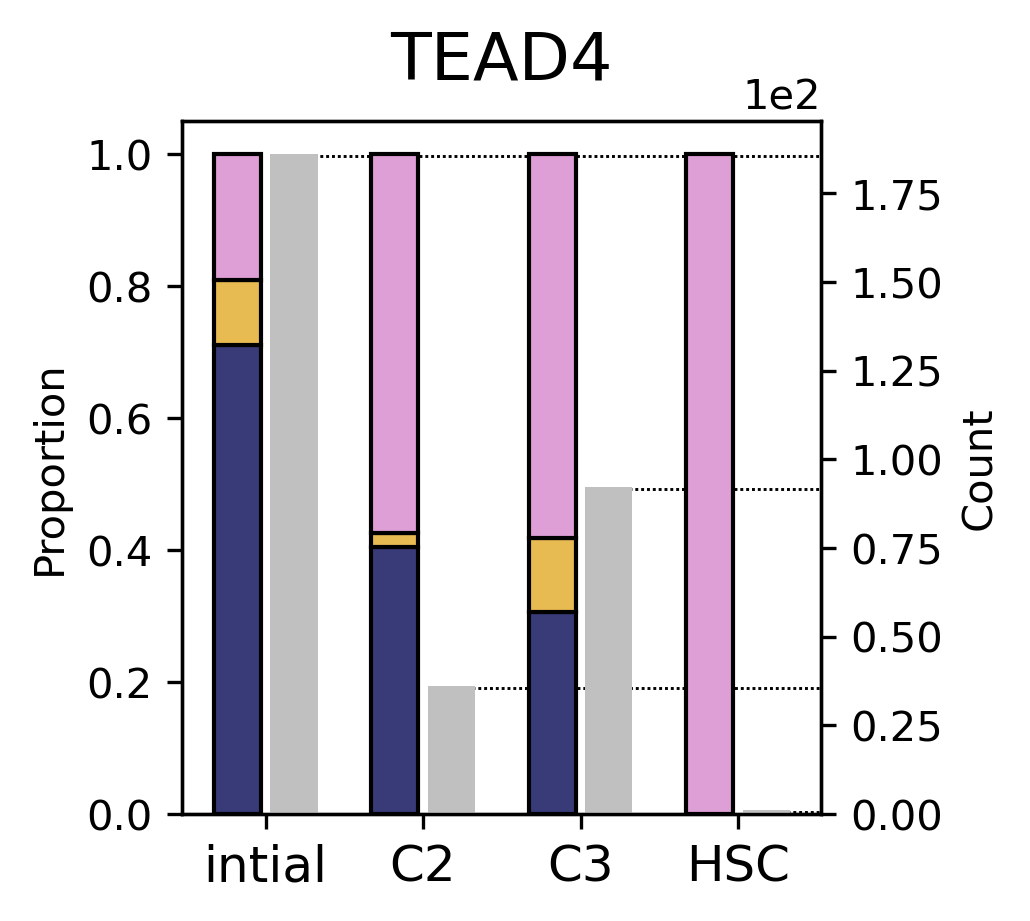

In [145]:
query = 'TEAD4'
width = 0.3
nudge = 0.03
color = 'silver'


"""
DATA SET UP
"""
plot_df = pdf.copy()
plot_df = plot_df[plot_df['gene_name'] == query]

plot_df = plot_df.sort_values(by='transcript_name')

# Add uniprot 
plot_df['annotation'] = (
    plot_df['transcript_name']
    + np.where(
        plot_df['uniprot'].notna(),
        ' (' + plot_df['uniprot'] + ')',
            ''
        )
    )


plot_df = plot_df.set_index('annotation')

# get total counts for the gene
counts = plot_df[['intial', 'C2', 'C3', 'HSC']].sum(axis=0)

# get transcript percentages
plot_df = plot_df[['intial_pct', 'C2_pct', 'C3_pct', 'HSC_pct']]
plot_df = plot_df[plot_df.sum(axis=1) != 0] # drop zero-sum transcripts !

plot_df.columns = plot_df.columns.map(lambda x: x.split("_")[0])
plot_df = plot_df.T
plot_df

"""
PLOT
"""
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 2.75, 3 # 2.75
fig, ax1 = plt.subplots()

# Create a second axis for the count bar plot
ax2 = ax1.twinx()

ax2.bar(
    counts.index, 
    counts.values, 
    color=color, 
    # ec='k',
    alpha=1,
    width=width,
    # linewidth=1,
    zorder=4,
    align='edge',
)

ax2.set_ylabel("Count", color='k')
ax2.tick_params(axis='y', color='k', labelcolor='k', )

# line_nudge = 0.1
line_nudge = 0.0025 * ax2.get_ylim()[1]

# Add reference lines
for i, count in enumerate(counts.values):
    ax2.plot(
        # [i + 0.2, 5], 
        [i + width + 0.01, 5],
        [count - line_nudge, count - line_nudge], 
        color='k',
        linestyle='--',
        dashes=(1, 1),
        lw=0.7,
        zorder=2,
)

# plot_df.columns = [x.split("-")[1] for x in plot_df.columns]
    
plot_df.plot(
    kind='bar',
    stacked=True,
    ec='k',
    cmap='tab20b',
    linewidth=1,
    width=-width,
    ax=ax1,
    zorder=5,
    align='edge',
    legend=False,
)

ax1.set_zorder(ax2.get_zorder()+1)
ax1.patch.set_visible(False)
# ax1.set_xlim([-.5 - nudge, 2.5 + nudge])
ax1.set_xlim([-.5 - nudge, len(plot_df.index) - 0.5 + nudge])

ax1.tick_params(axis='x', rotation=0, labelsize=12)
ax1.set_ylabel(f"Proportion")
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

# get legend info
handles, labels = ax1.get_legend_handles_labels()

# Shift bars to the left
bar_positions = [bar.get_x() for bar in ax1.patches]
new_positions = [pos - nudge for pos in bar_positions] 
for bar, new_pos in zip(ax1.patches, new_positions):
    bar.set_x(new_pos)
    
# Shift bars to the right
bar_positions = [bar.get_x() for bar in ax2.patches]
new_positions = [pos + nudge for pos in bar_positions] 
for bar, new_pos in zip(ax2.patches, new_positions):
    bar.set_x(new_pos)
        
# sns.move_legend(
#     ax1,
#     loc='lower center',
#     title="",
#     frameon=False,
#     bbox_to_anchor=(0.5, -0.74),
#     fontsize='small',
#     ncol=2,
# )

plt.title(query, fontsize=16, pad=10)

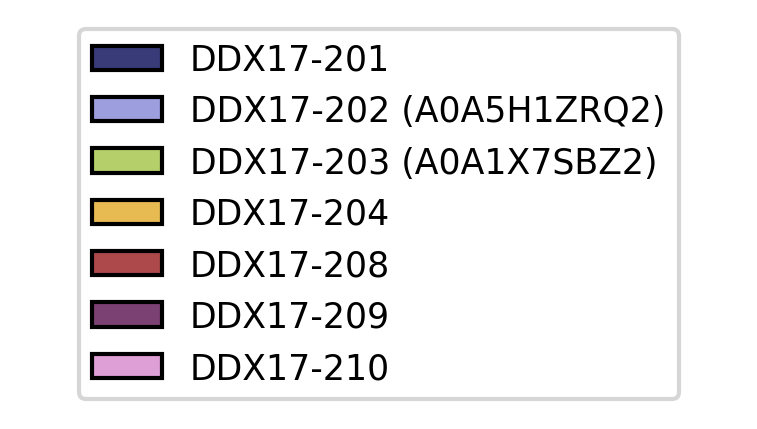

In [143]:
fig_leg, ax_leg = plt.subplots(figsize=(3,0.5))  # Adjust width/height as needed
ax_leg.legend(
    handles,
    labels,
    loc='center',
    ncol=1,
    # frameon=False,
    fontsize='small',
)
ax_leg.axis('off')

plt.tight_layout()
plt.show()

In [123]:
counts

intial    6502.377947
C2        2962.769589
C3        3786.308994
HSC        505.018650
dtype: float64

In [126]:
plot_df

annotation,EID1-201 (Q9Y6B2),EID1-202 (H0YN68)
intial,0.415860,0.584140
C2,0.946019,0.053981
C3,0.977798,0.022202
HSC,0.034178,0.965822


# Quick check

In [50]:
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/hsc_epi2me_full/anndata/gene_adata.h5ad"

tdata = sc.read_h5ad(fpath)
tdata

AnnData object with n_obs × n_vars = 11403 × 25311
    obs: 'hac_v3', 'fast_v4.2', 'fast_v3', 'minion_384', 'hac_v4.3', 'hac_v4.2'
    var: 'hac_v3', 'fast_v4.2', 'fast_v3', 'minion_384', 'hac_v4.3', 'hac_v4.2'

In [52]:
tdata.obs.head()

,hac_v3,fast_v4.2,fast_v3,minion_384,hac_v4.3,hac_v4.2
AAACCCAAGGTTACCT-1,2888.0,33.0,39.0,829.0,1050.0,6396.0
AAACCCAAGTCGTCGT-1,0.0,0.0,1.0,0.0,0.0,0.0
AAACCCAAGTTGAAGT-1,2591.0,48.0,27.0,790.0,1015.0,6163.0
AAACCCAAGTTGTCGT-1,1703.0,29.0,12.0,519.0,610.0,3870.0
AAACCCACAGAAGCGT-1,1404.0,23.0,9.0,421.0,507.0,3066.0


In [50]:
tmp = tdata.var.copy()
tmp = tmp.reset_index(names='gene_name')

tmp.head()

,gene_name,hac_v3,fast_v4.2,fast_v3,minion_384,hac_v4.3,hac_v4.2
0,A1BG,4134.0,55.0,59.0,1246.0,1476.0,9504.0
1,A1BG-AS1,246.0,5.0,2.0,88.0,63.0,383.0
2,A1CF,0.0,0.0,0.0,0.0,0.0,2.0
3,A2M,85.0,0.0,0.0,35.0,21.0,186.0
4,A2M-AS1,16.0,0.0,0.0,0.0,0.0,24.0


In [51]:
tmp[tmp['gene_name'] == 'CD24']

,gene_name,hac_v3,fast_v4.2,fast_v3,minion_384,hac_v4.3,hac_v4.2
2402,CD24,4903.0,90.0,72.0,1463.0,1661.0,9655.0


In [ ]:
# so CD24 is in the raw gene data. I do not see it in the processed gene data for 3 libraries or just the 2 libraries.
# It's not in the fib data, and we merge only keeping overlapping genes

In [4]:
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/cc_fibroblast_full/scfib/scfib.gene_raw_feature_bc_matrix/"

fib_adata = sc.read_10x_mtx(fpath)
fib_adata.obs['batch'] = 'fib'

print(f"Batch: Fibroblast")
print(f"\tTotal UMIs: {int(np.sum(fib_adata.X))}")
print(f"\tCells: {fib_adata.shape[0]}")
print(f"\tGenes: {fib_adata.shape[1]}")

Batch: Fibroblast
	Total UMIs: 106198200
	Cells: 8963
	Genes: 23635


In [6]:
tmp = fib_adata.var.copy()
tmp = tmp.reset_index(names='gene_name')
tmp[tmp['gene_name'] == 'CD24']

,gene_name,gene_ids,feature_types
